# Experiments 25-28
### Hyperparameters: _Freezing (Init, 8 lys, 12 lys, Full)_

### Dataset:
- **Dataset:** 3.5m | 90º
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:** 5472 `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~1000
- **Batch:** 64

### Experiments:
1. No pre-train
1. Full Fine-Tuning
1. Freezing Backbone *(8 layers)*
1. Freezing Backbone *(12 layers)*
- **Reference:** Freezing Backbone *(10 layers)*

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 3
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/3 Hyperparams/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [5]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/3 Hyperparams/3 set/runs/detect


In [6]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [7]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [8]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [9]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [10]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 25
### *Random initialization | ~1000 epochs*

In [11]:
folder = "train/"

In [12]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
1186,1187,10759.8,0.68070,0.40913,0.91816,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000030,0.000030,0.000030
1187,1188,10773.3,0.68233,0.41238,0.91977,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000027,0.000027,0.000027
1188,1189,10781.7,0.69149,0.41472,0.92163,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000025,0.000025,0.000025
1189,1190,10795.6,0.63713,0.38635,0.89615,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000023,0.000023,0.000023
1190,1191,10805.8,0.61439,0.37418,0.89136,0.56591,0.46824,0.44883,0.14883,2.67244,1.39438,1.98676,0.000020,0.000020,0.000020


El entrenamiento se realizó en 2 etapas, interrumipéndose la primera en la epoch 638 con una duración de 8388.09 min.

***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [13]:
last_row = df.iloc[-1]
time = (last_row['time'] + 8388.09)/60 # Se agrega el tiempo de entrenamiento de la 1º etapa
print(f"Training time: {time:.3f} min")

Training time: 319.898 min


#### Best epoch

In [14]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1190,1191,10805.8,0.61439,0.37418,0.89136,0.56591,0.46824,0.44883,0.14883,2.67244,1.39438,1.98676,0.00002,0.00002,0.00002,319.898167


In [15]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1191 con mAP50 de 0.449


In [16]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [173]:
TP = 1302
FP = 874
FN = 1107
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3283


In [174]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.39658848614072495, 0.26621992080414253, 0.3371915930551325)

### Graphs

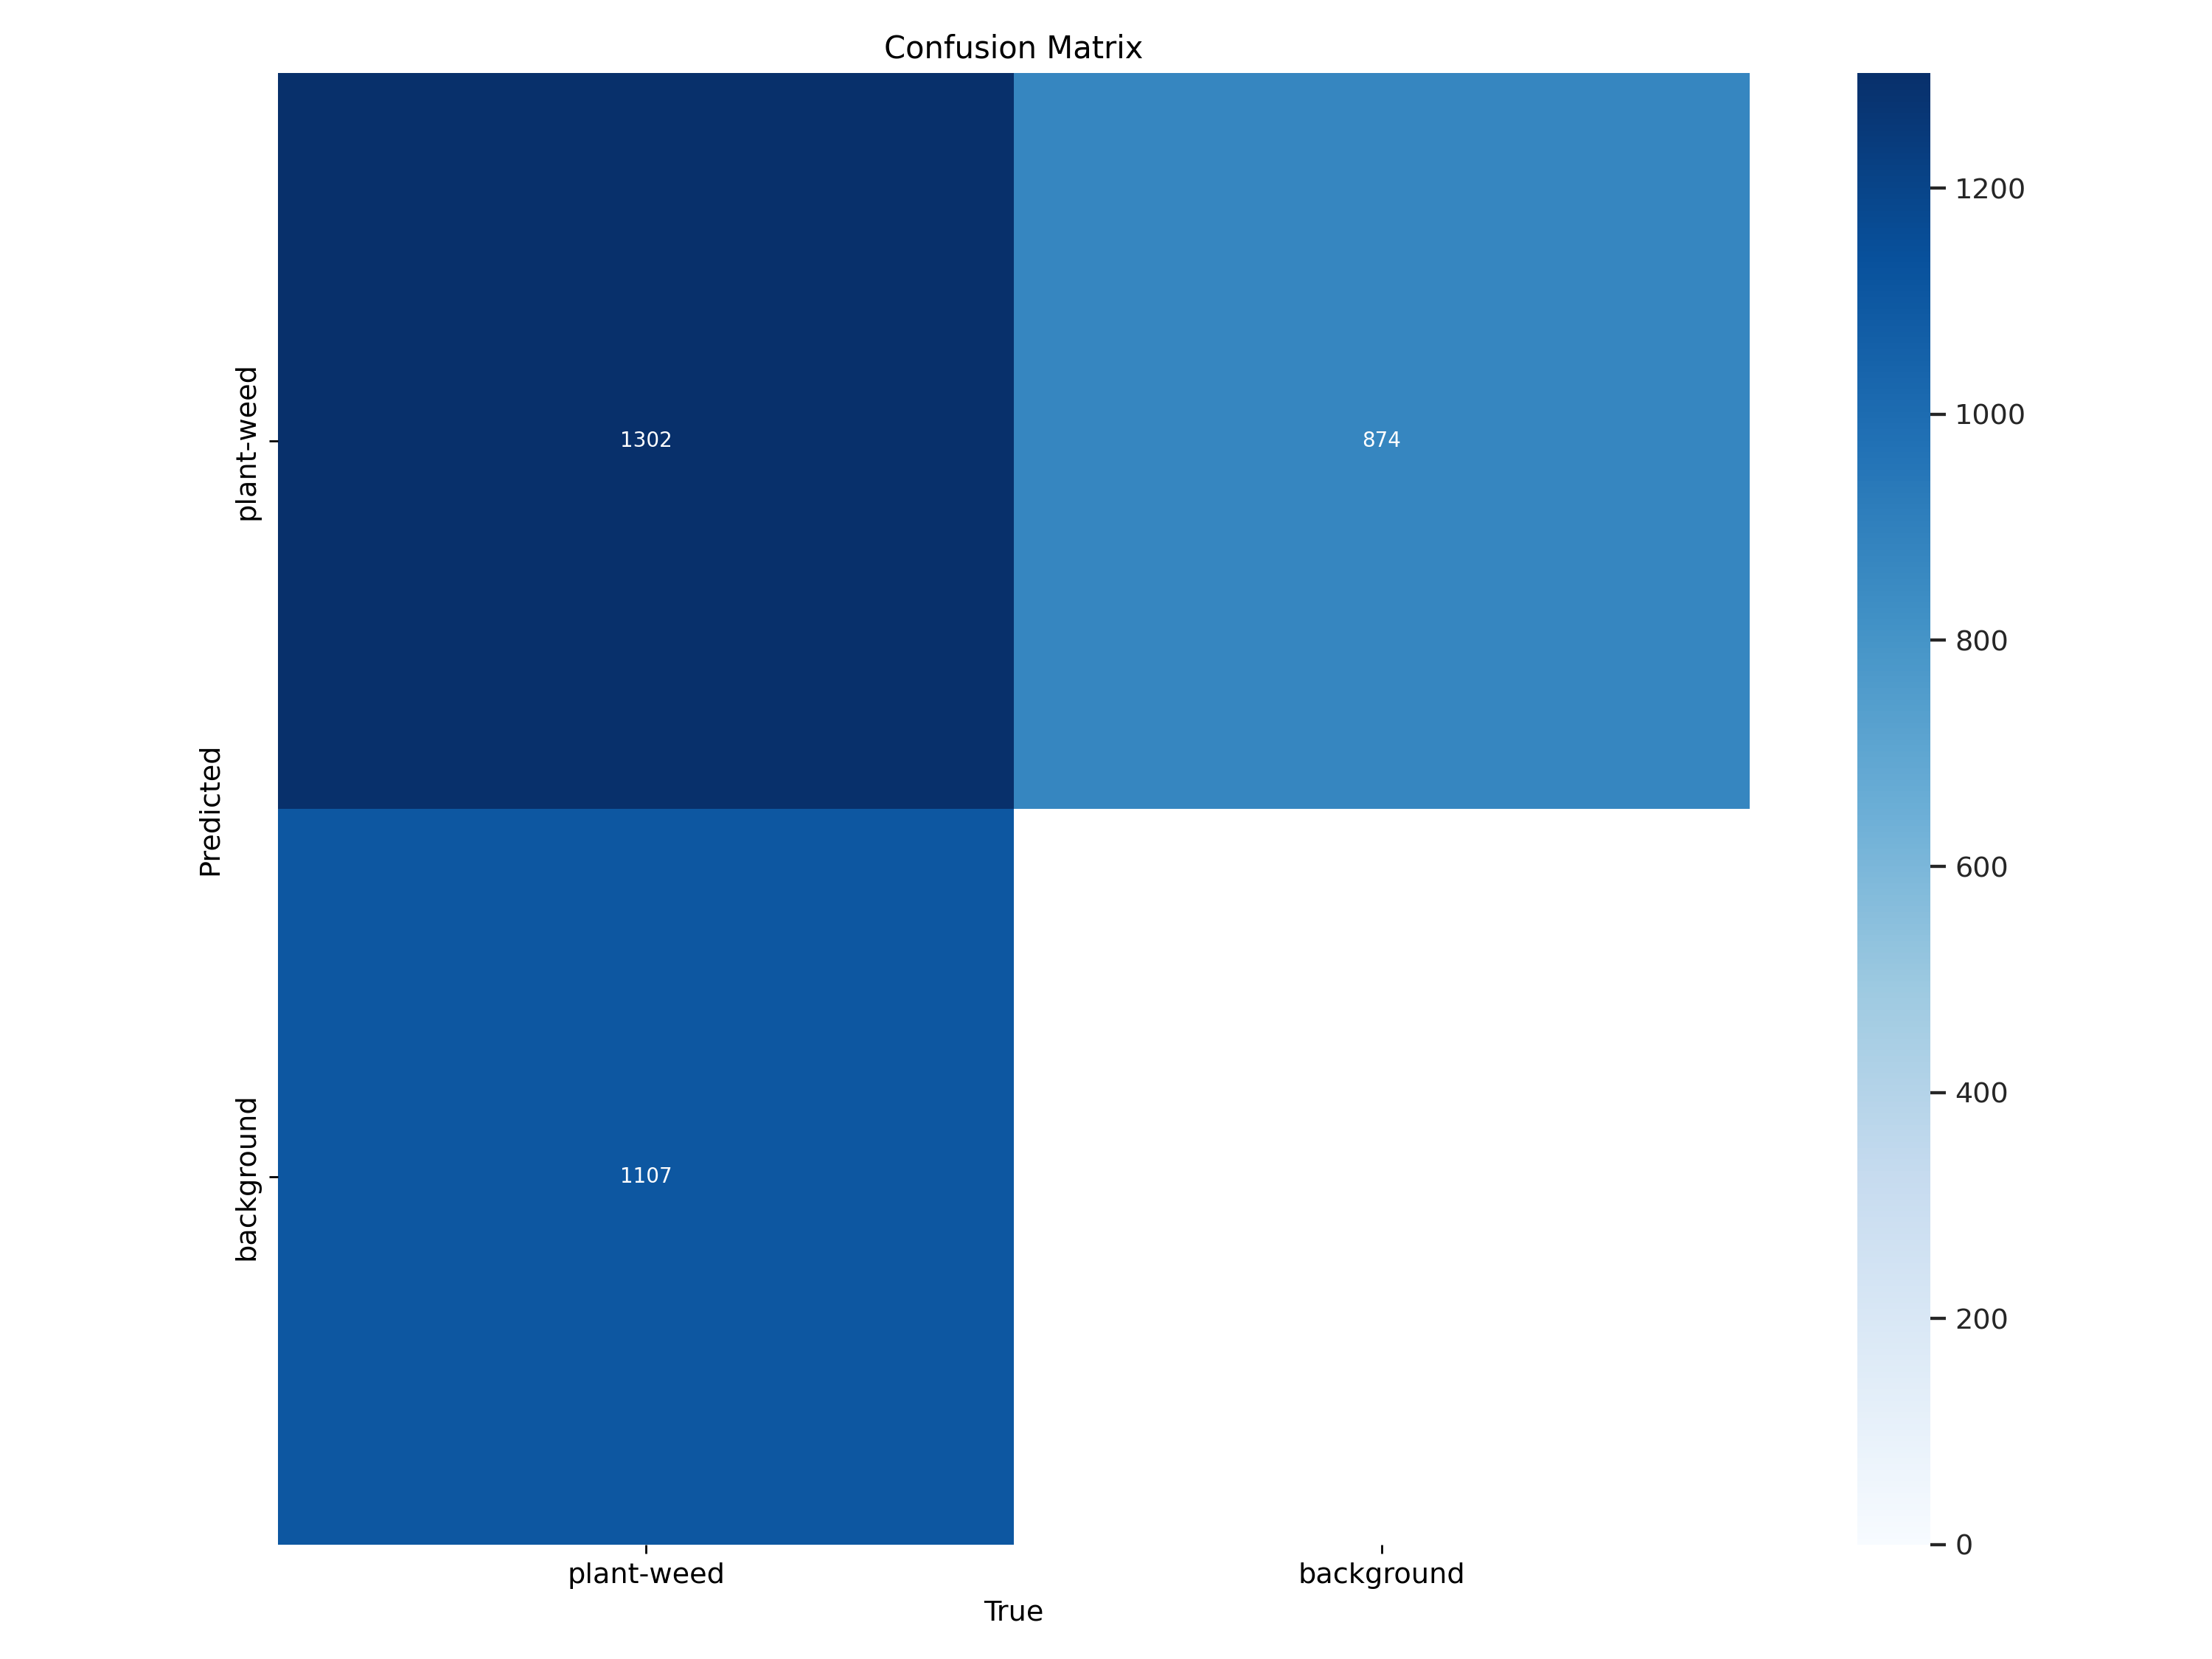

In [19]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

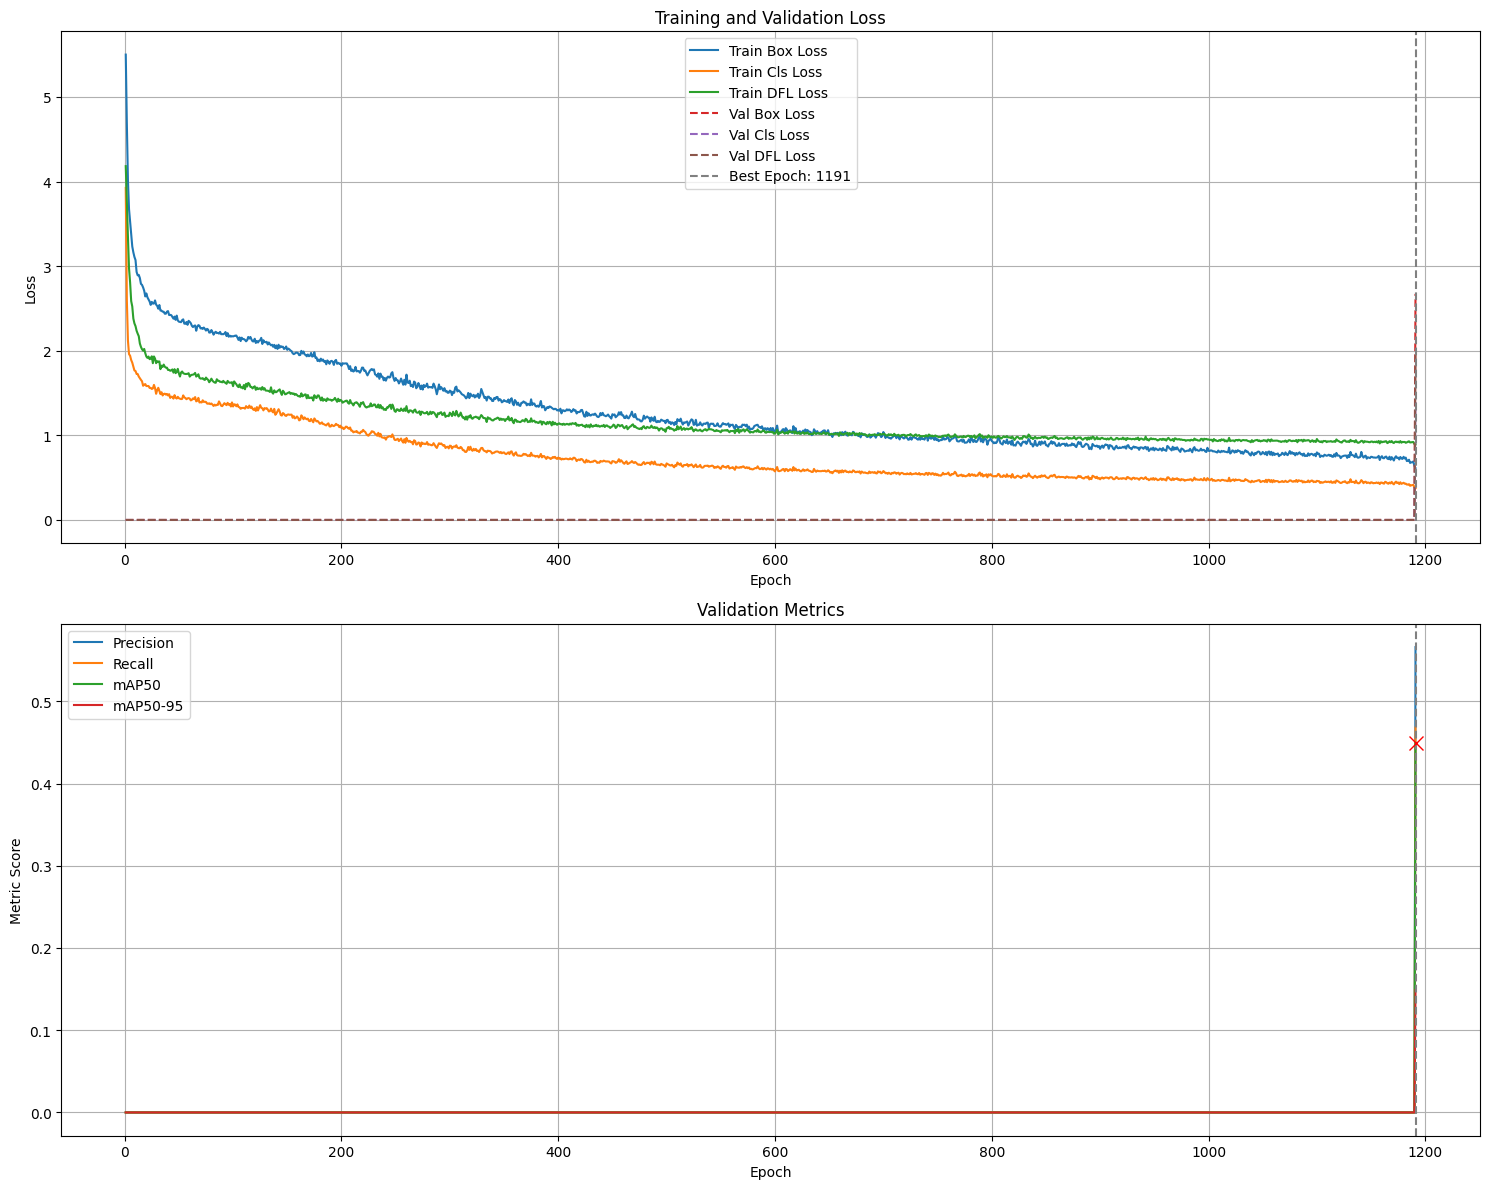

In [20]:
graph_training_metrics(df, epoch, graph="full")

In [21]:
graph_LrLoss_3D(df)

Validation set


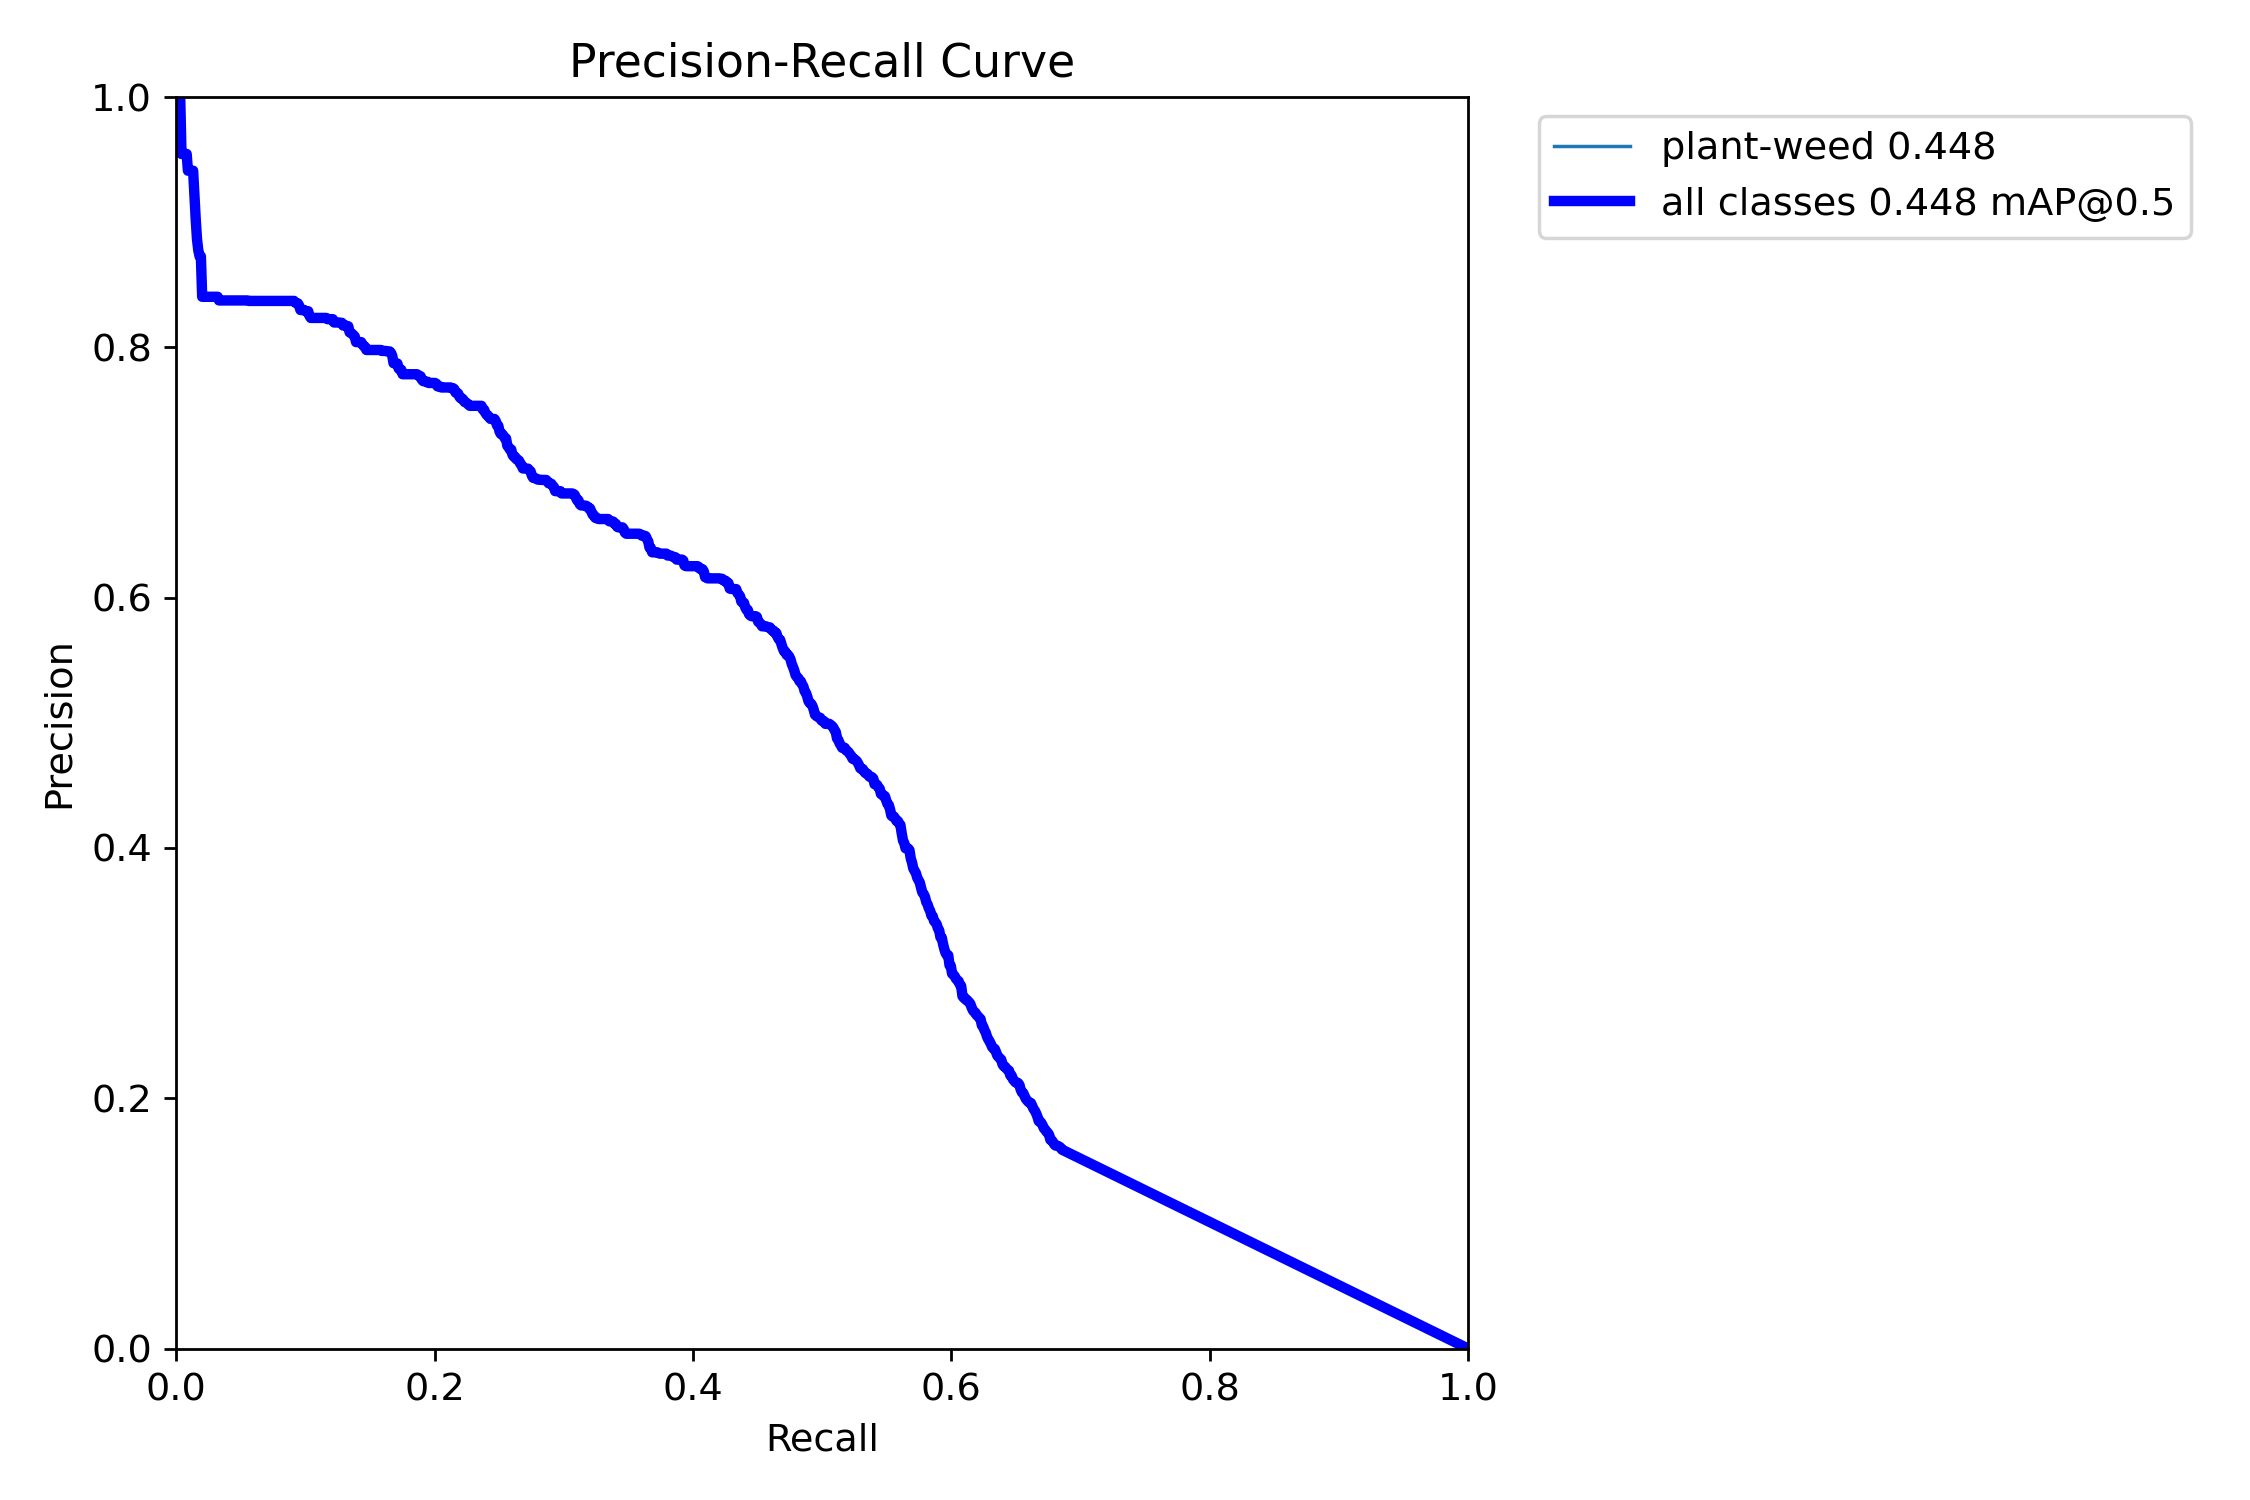

In [22]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

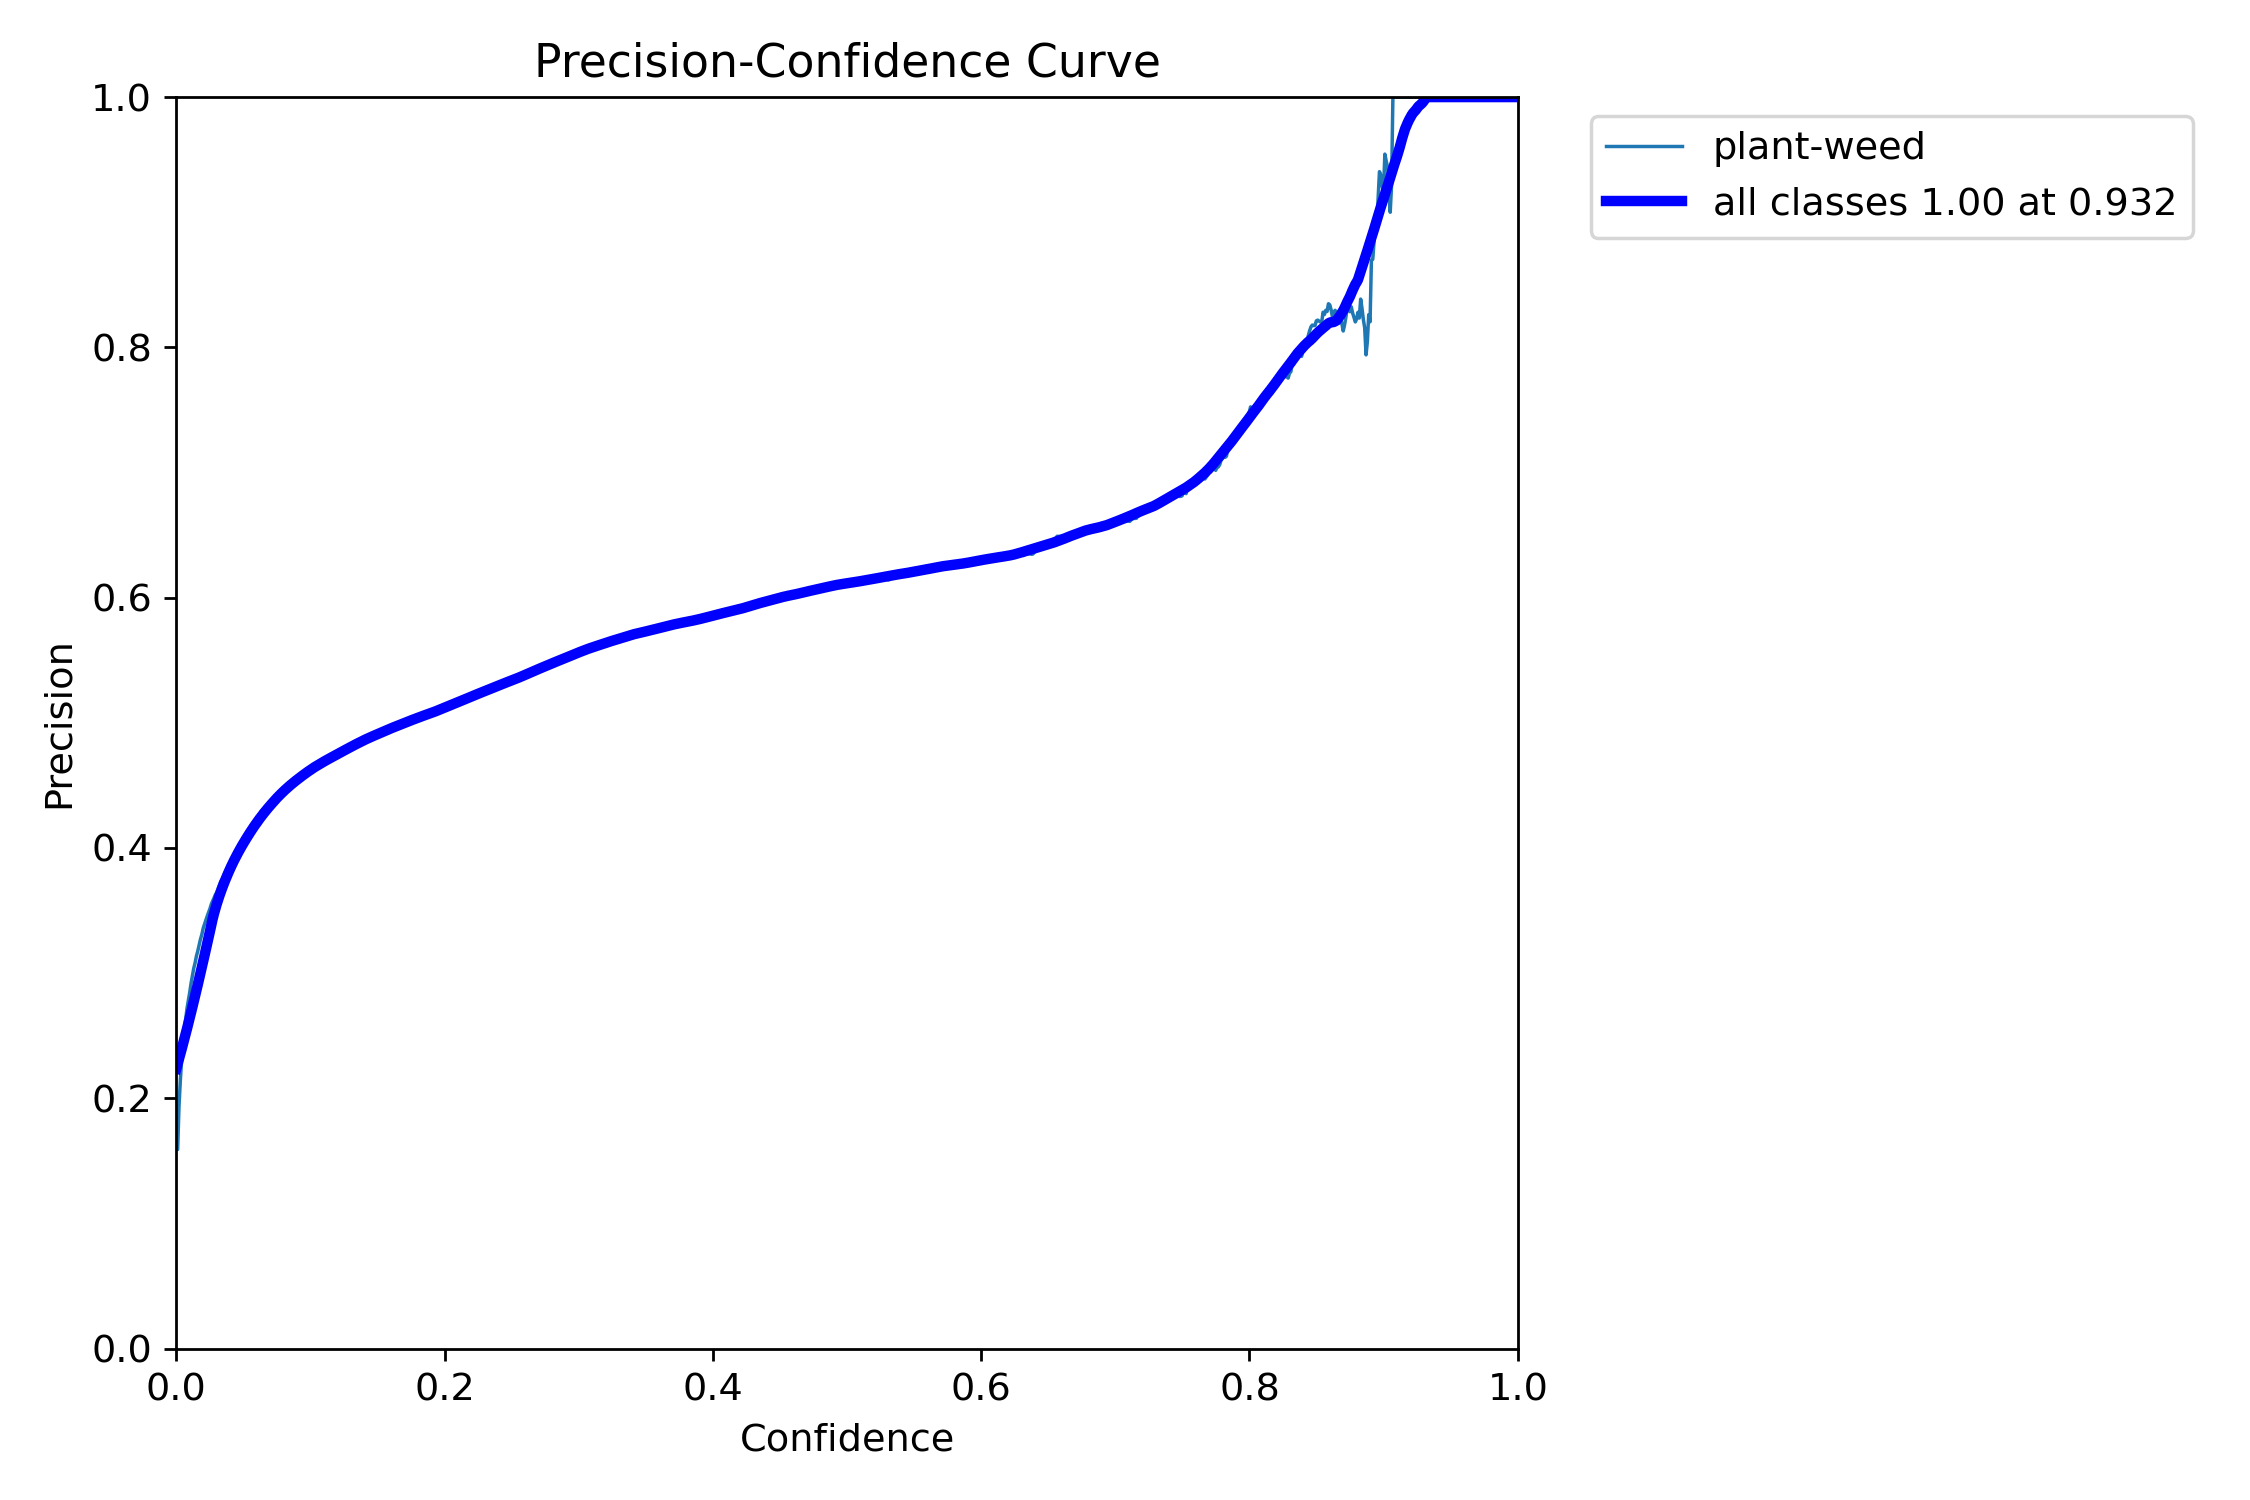

In [23]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

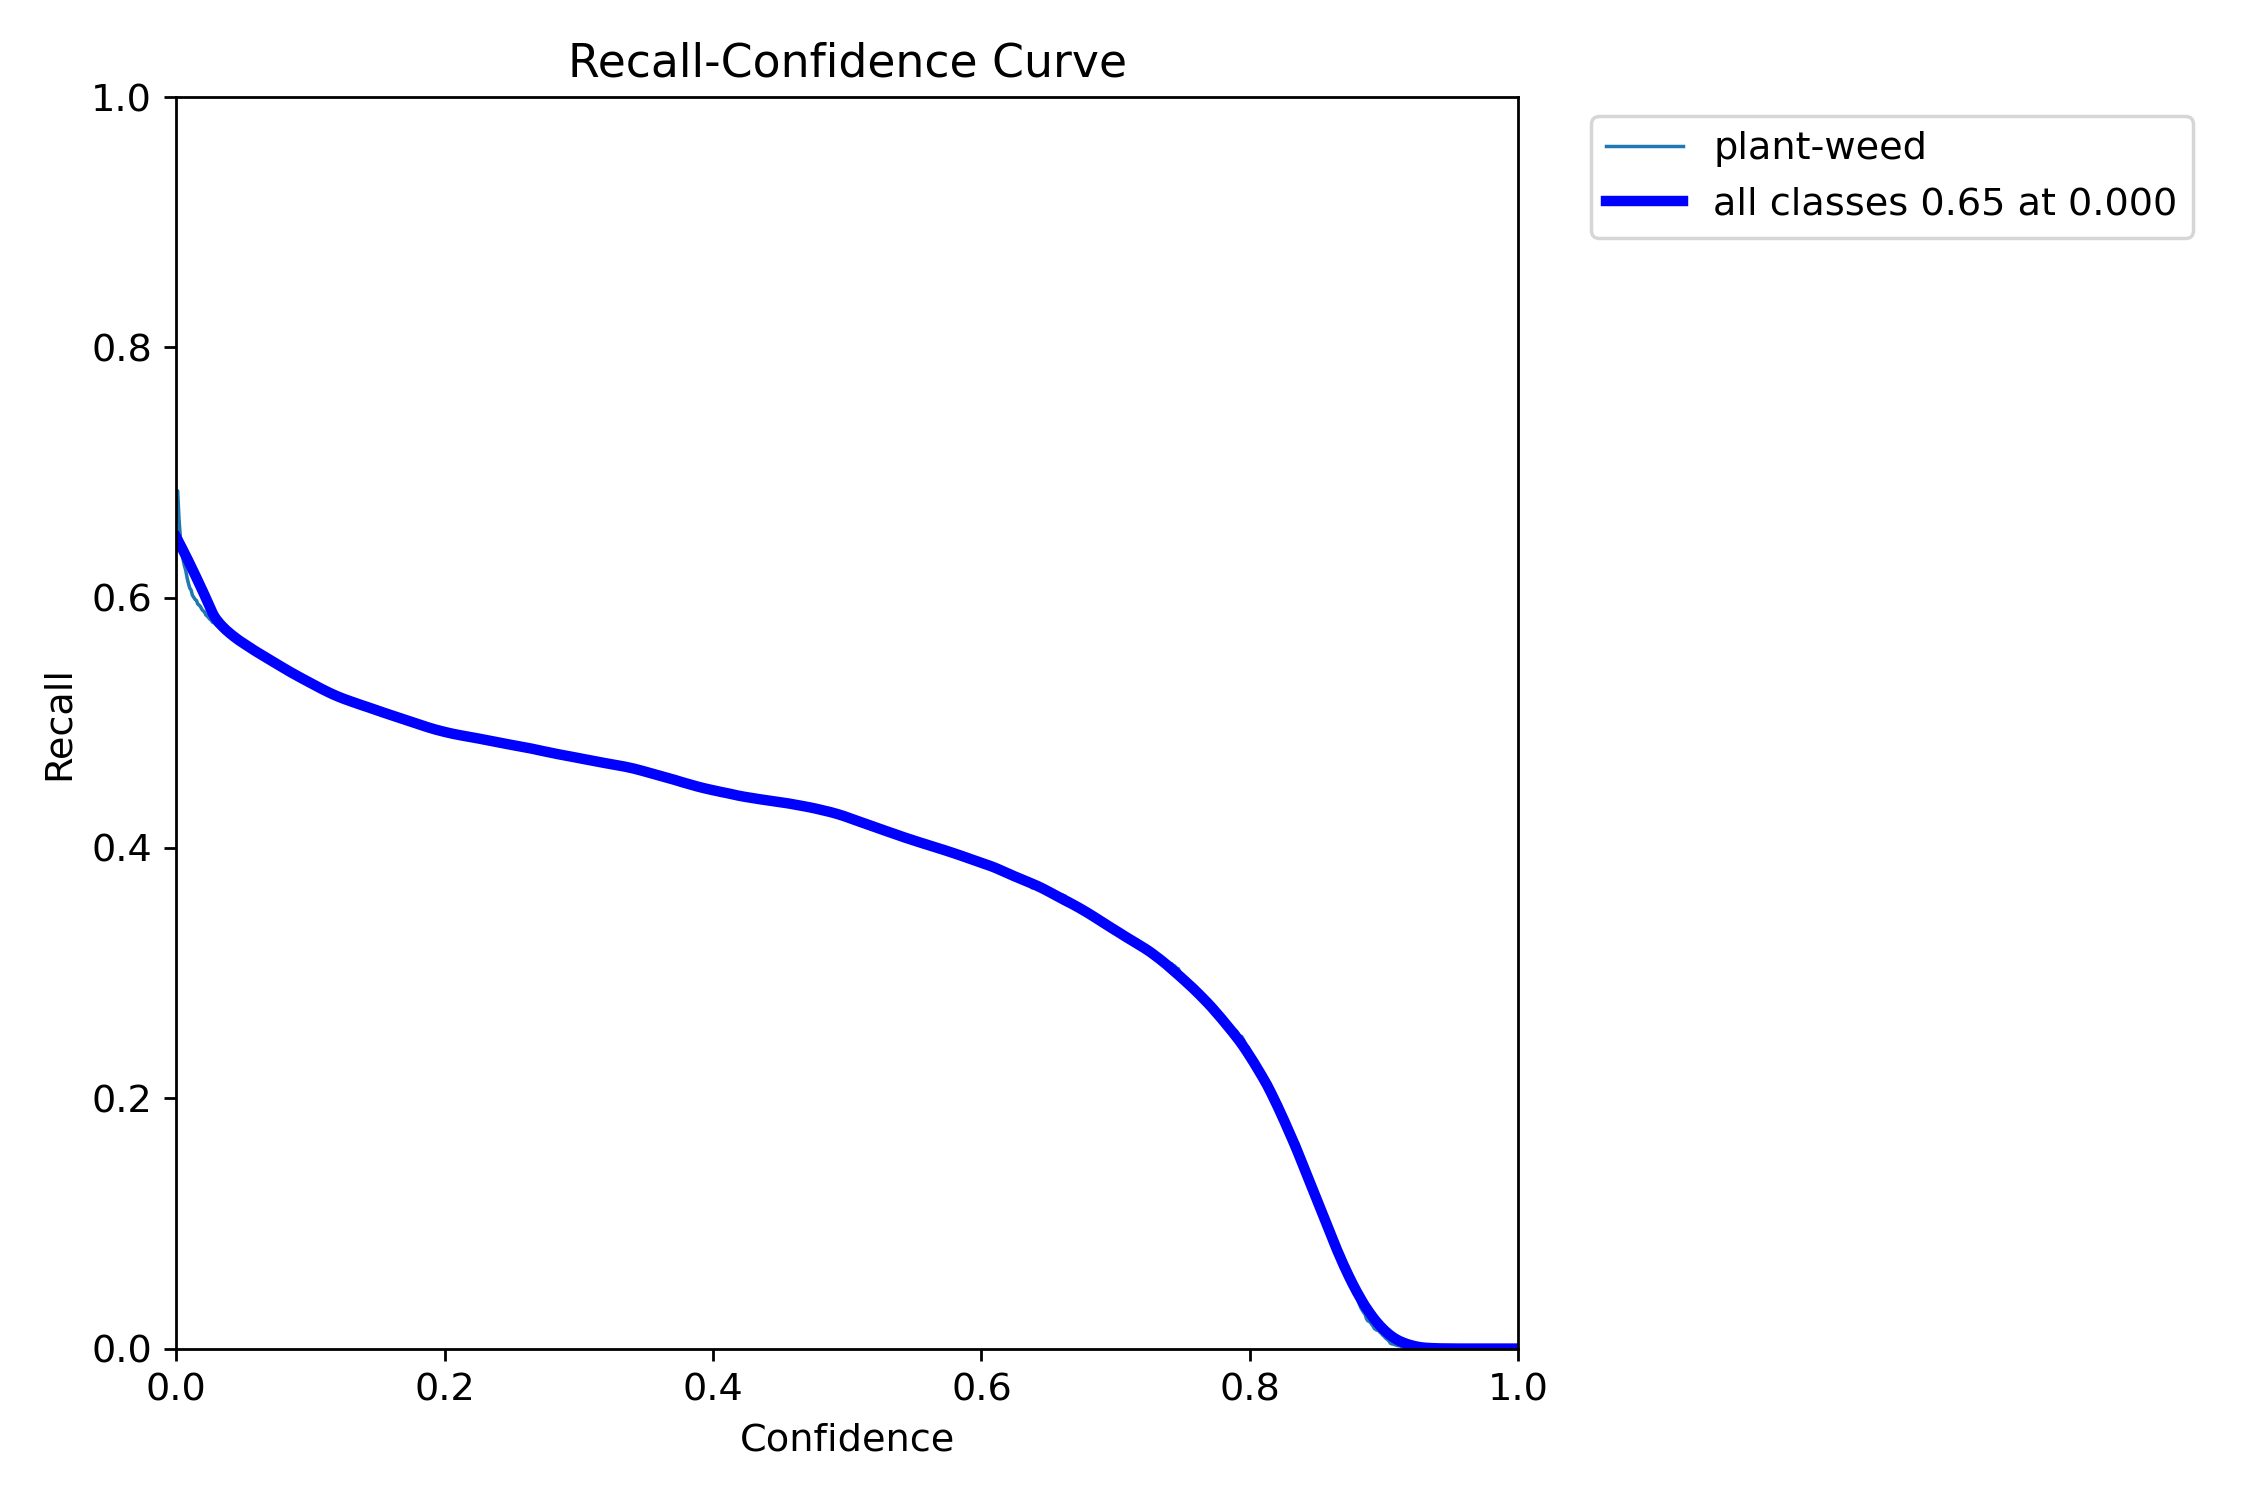

In [24]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

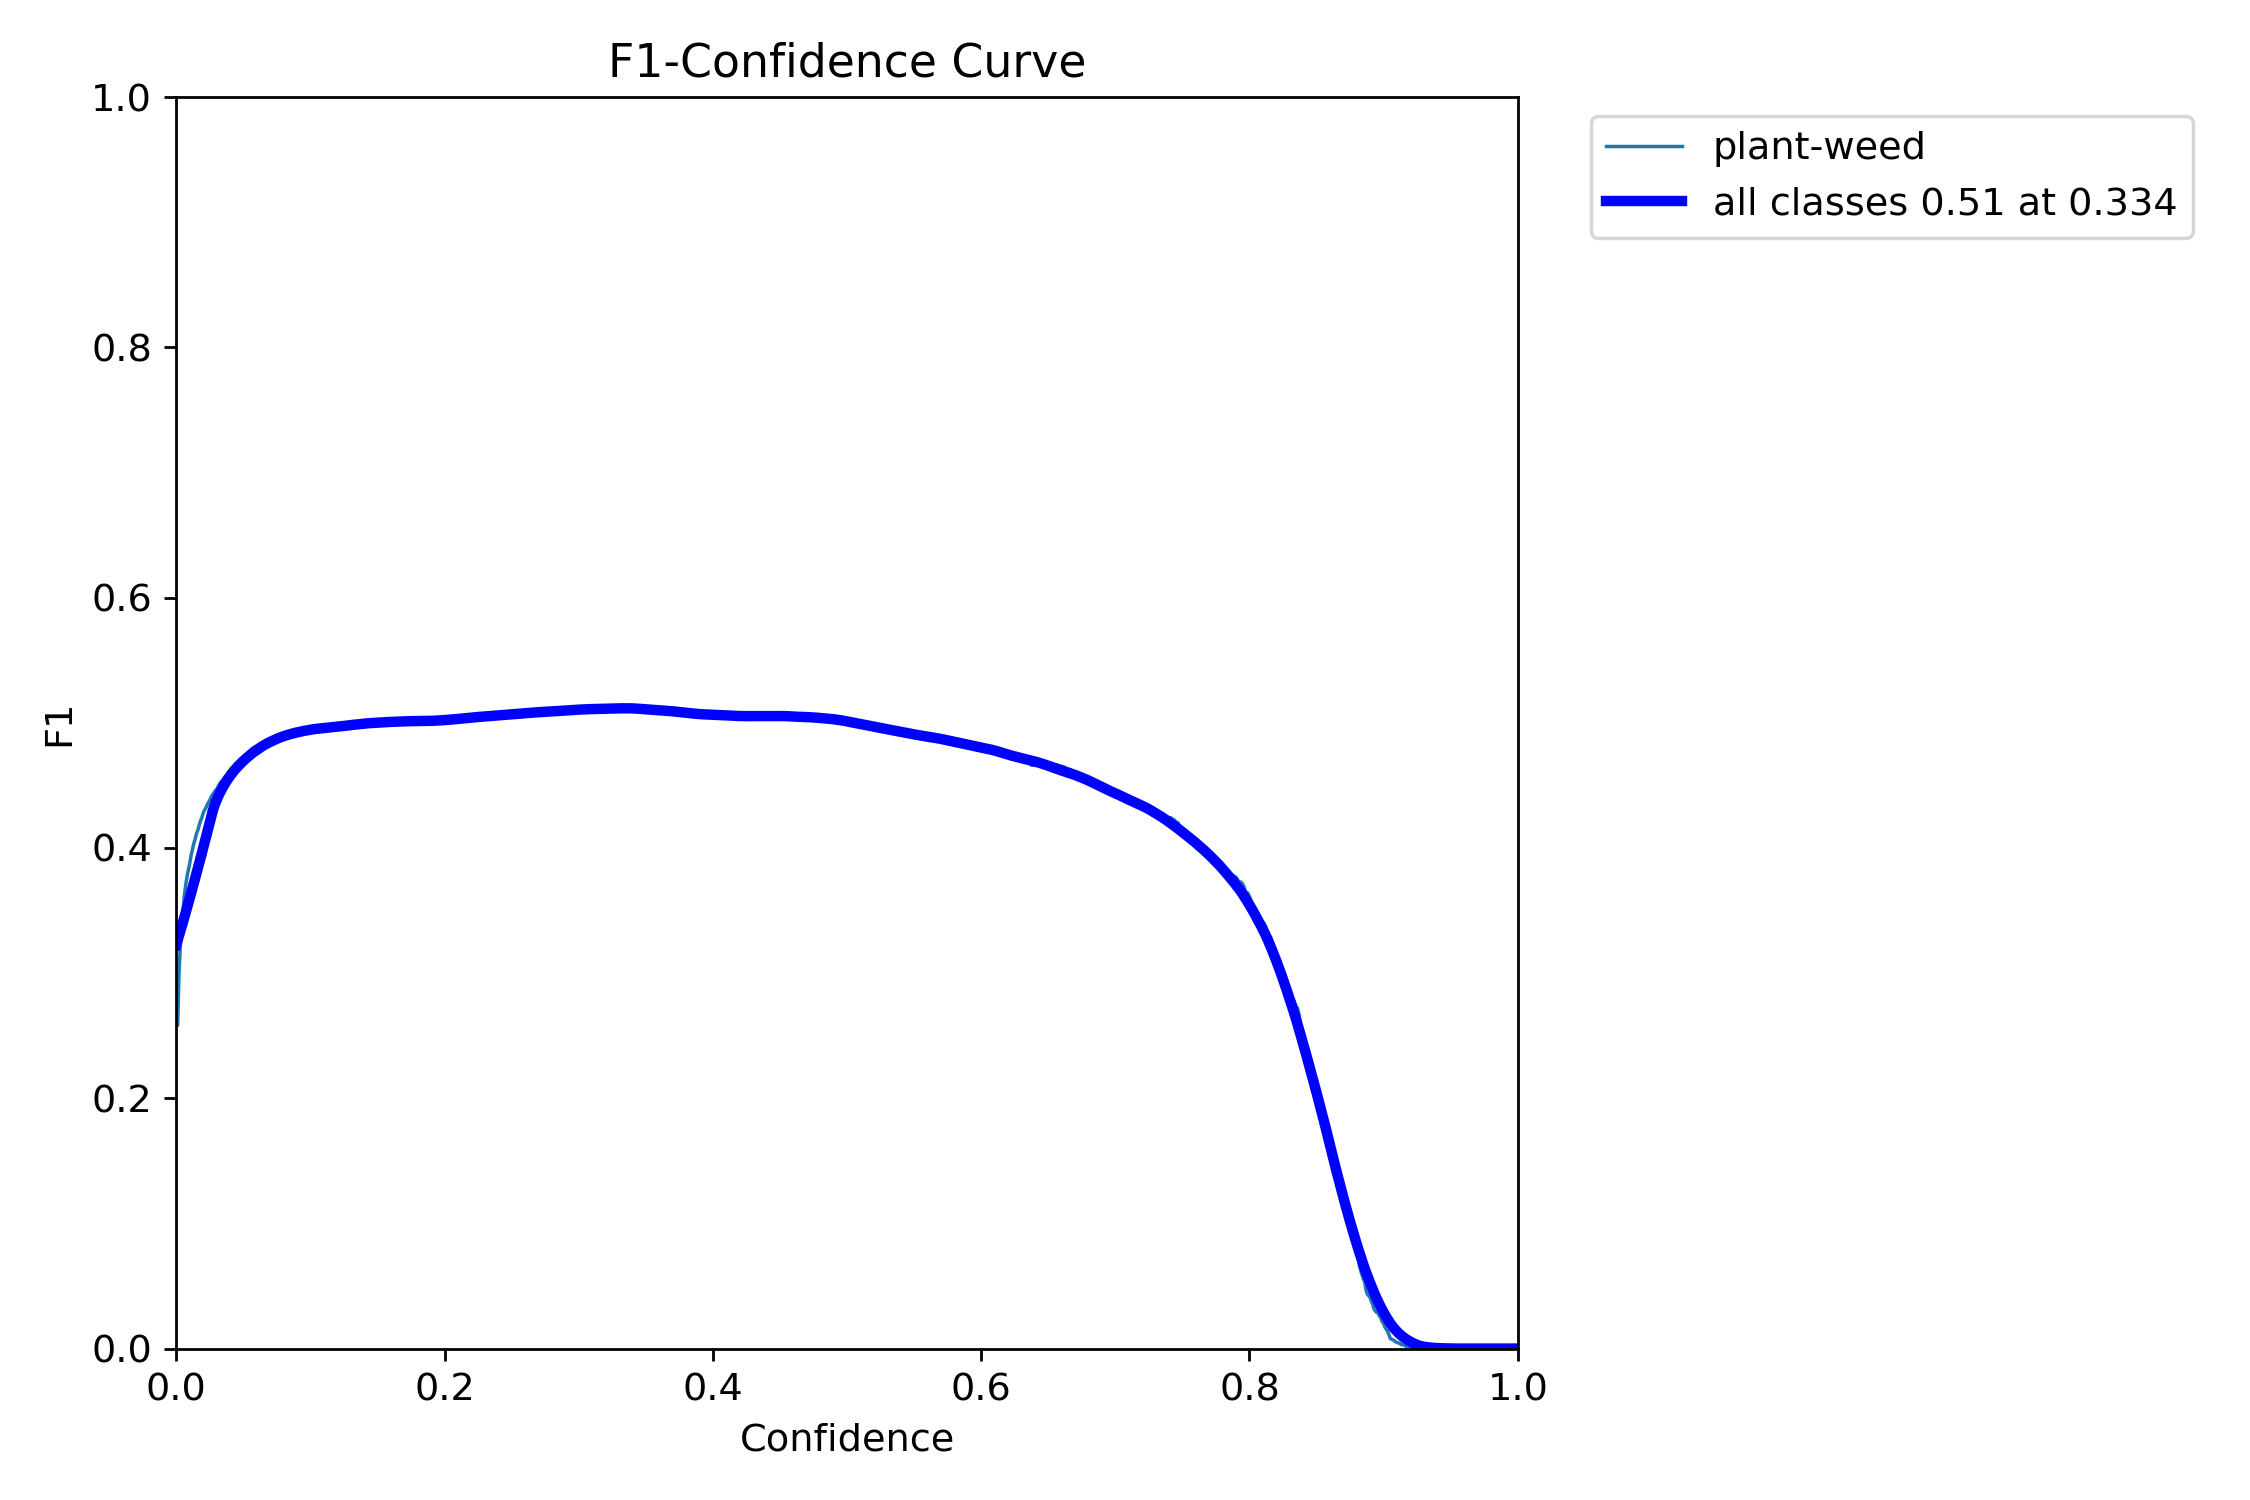

In [25]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Experiment 26
### *Full Fine-Tuning | ~1000 epochs*
Every layer was initialized with pre-trained YOLOv8 weights and then re-trained for ~1000 epochs

1. No pre-train
1. Full Fine-Tuning
1. Freezing Backbone *(8 layers)*
1. Freezing Backbone *(12 layers)*
- **Reference:** Freezing Backbone *(10 layers)*

In [26]:
folder = "train2/"

In [27]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
168,169,12195.9,1.02856,0.57053,1.02018,0,0,0,0,0,0,0,0.000088,0.000088,0.000088
169,170,12262.4,1.01047,0.55902,1.00149,0,0,0,0,0,0,0,0.000077,0.000077,0.000077
170,171,12342.3,1.01218,0.56321,1.01484,0,0,0,0,0,0,0,0.000066,0.000066,0.000066
171,172,12417.4,0.95753,0.53429,0.98759,0,0,0,0,0,0,0,0.000054,0.000054,0.000054
172,173,12501.7,0.98593,0.55160,1.01167,0,0,0,0,0,0,0,0.000043,0.000043,0.000043


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [28]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 208.362 min


#### Best epoch

In [29]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
0,1,15.0336,3.22651,4.6857,2.3448,0,0,0,0,0,0,0,0.00012,0.00012,0.00012,208.361667


In [30]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1 con mAP50 de 0.000


In [31]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [175]:
TP = 1453
FP = 1049
FN = 956
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3458


In [176]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.4201850780798149, 0.3033545401966455, 0.2764603817235396)

### Graphs

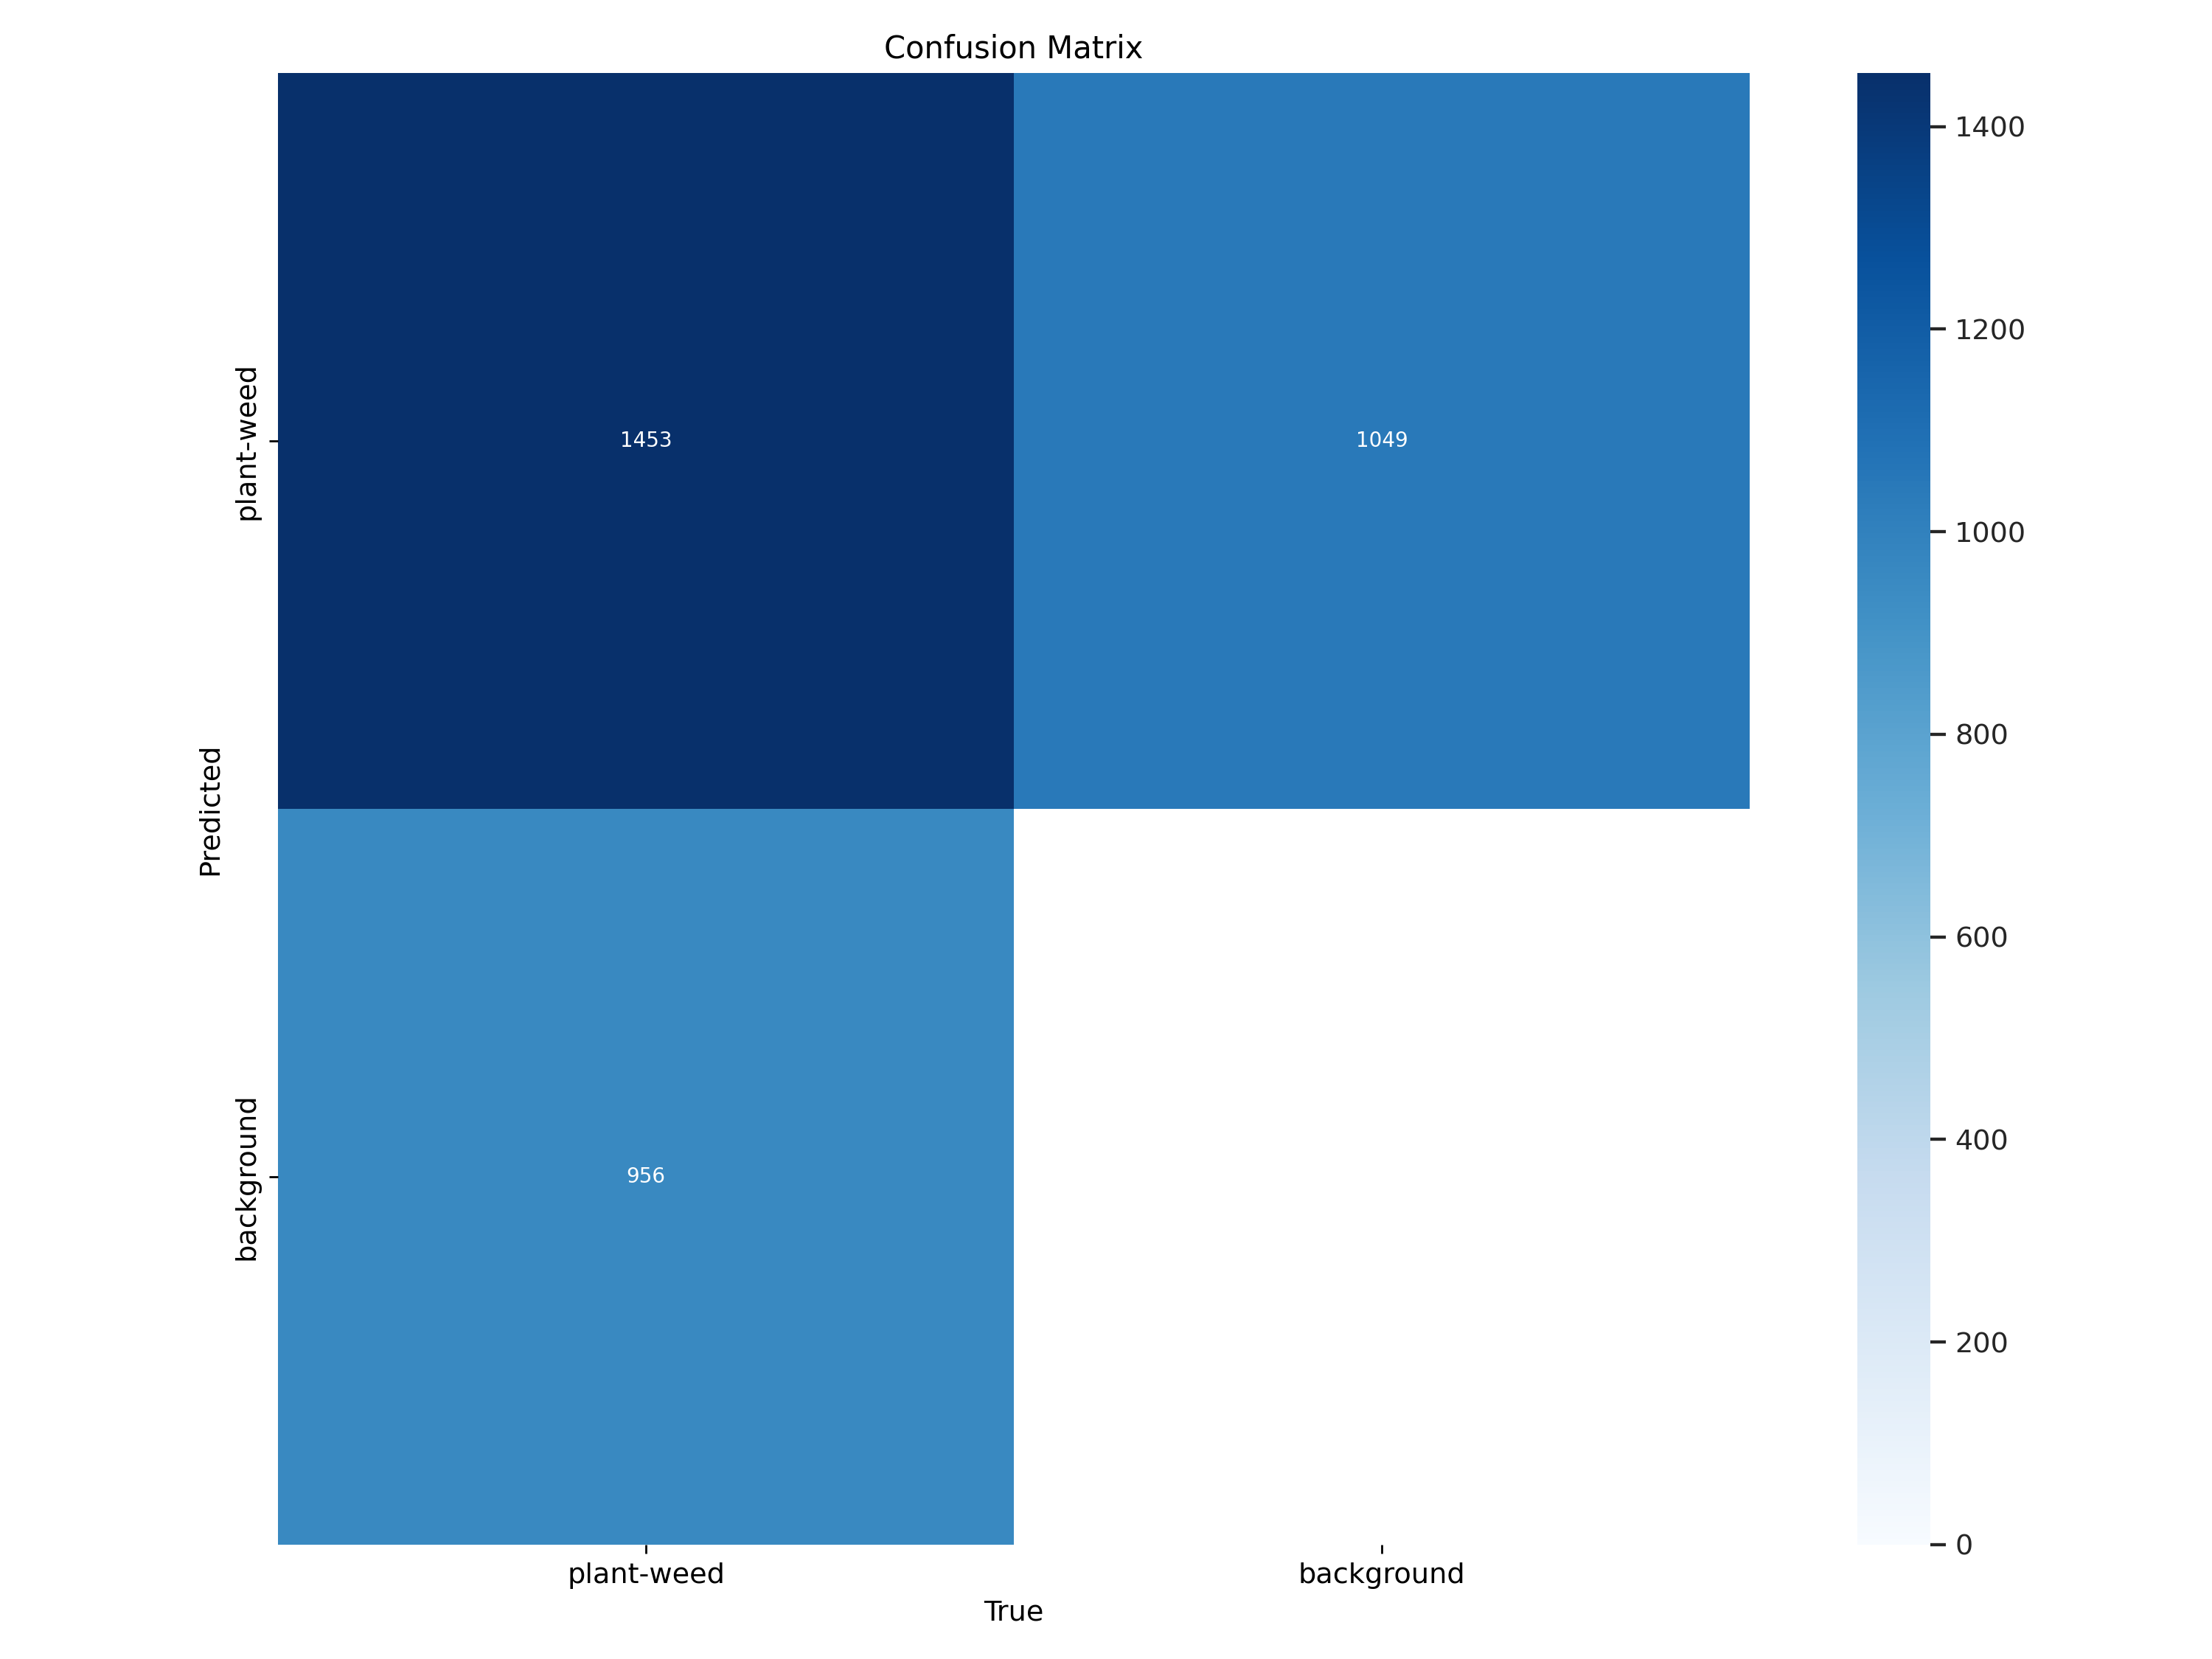

In [34]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

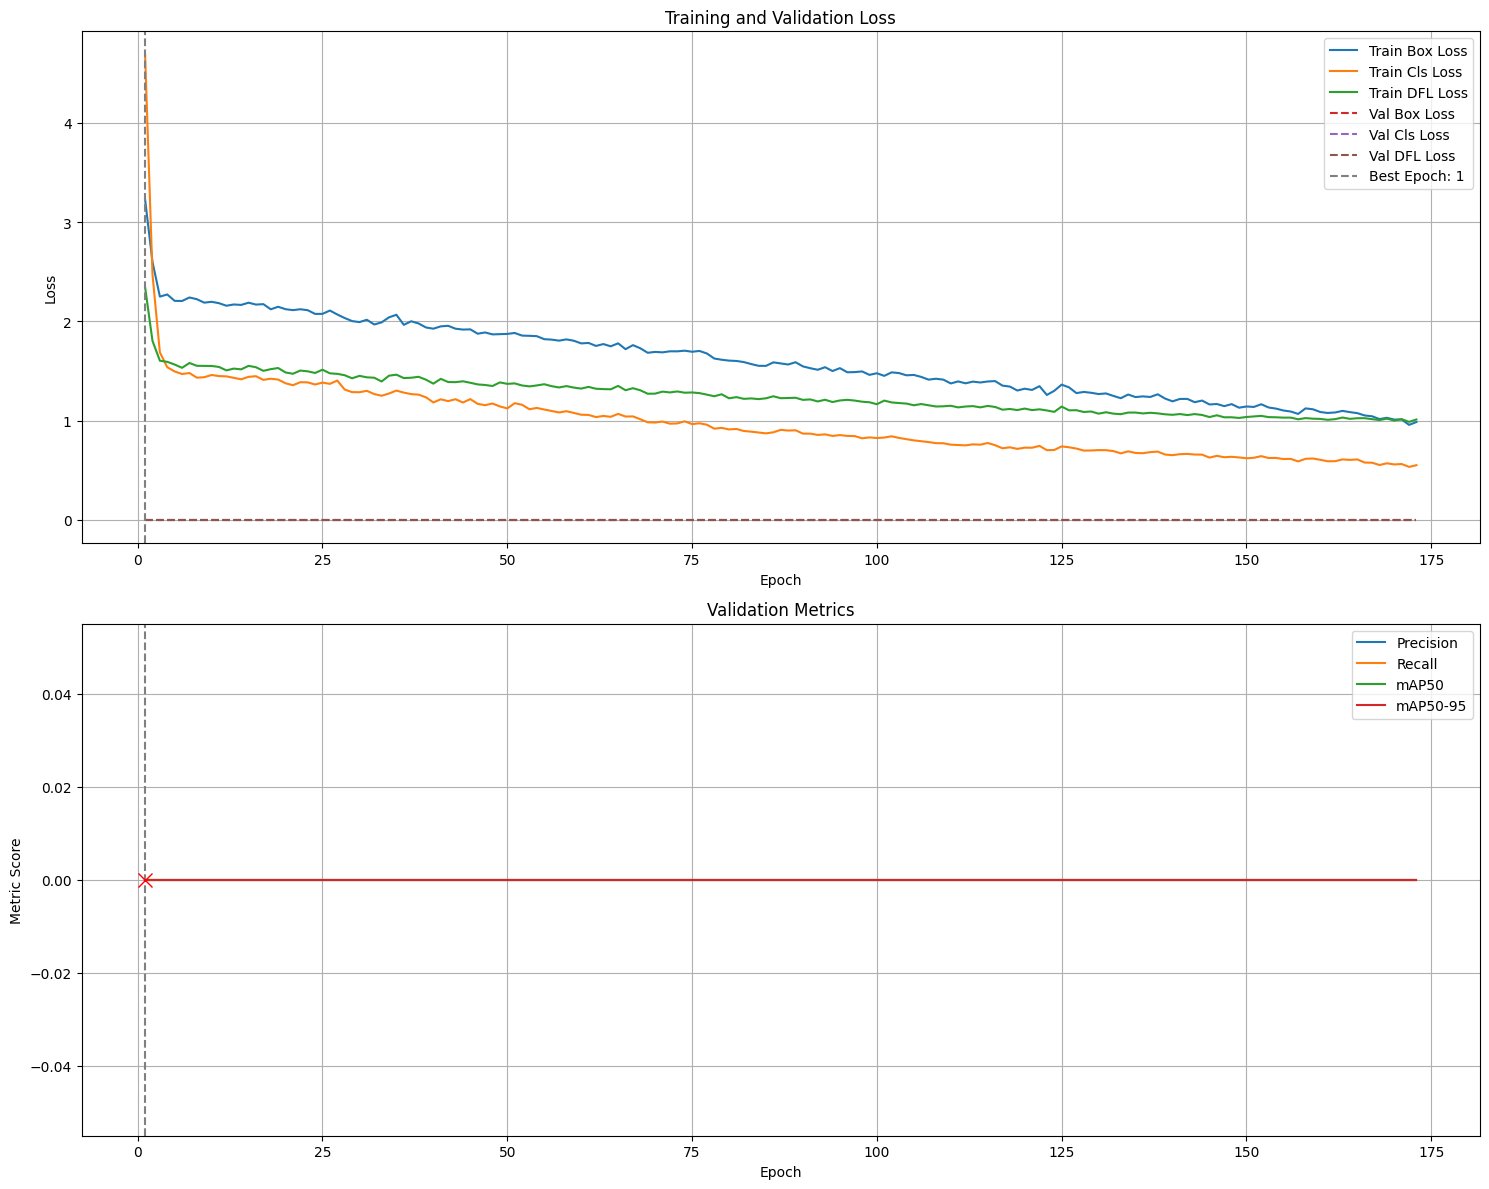

In [35]:
graph_training_metrics(df, epoch, graph="full")

In [36]:
graph_LrLoss_3D(df)

Validation set


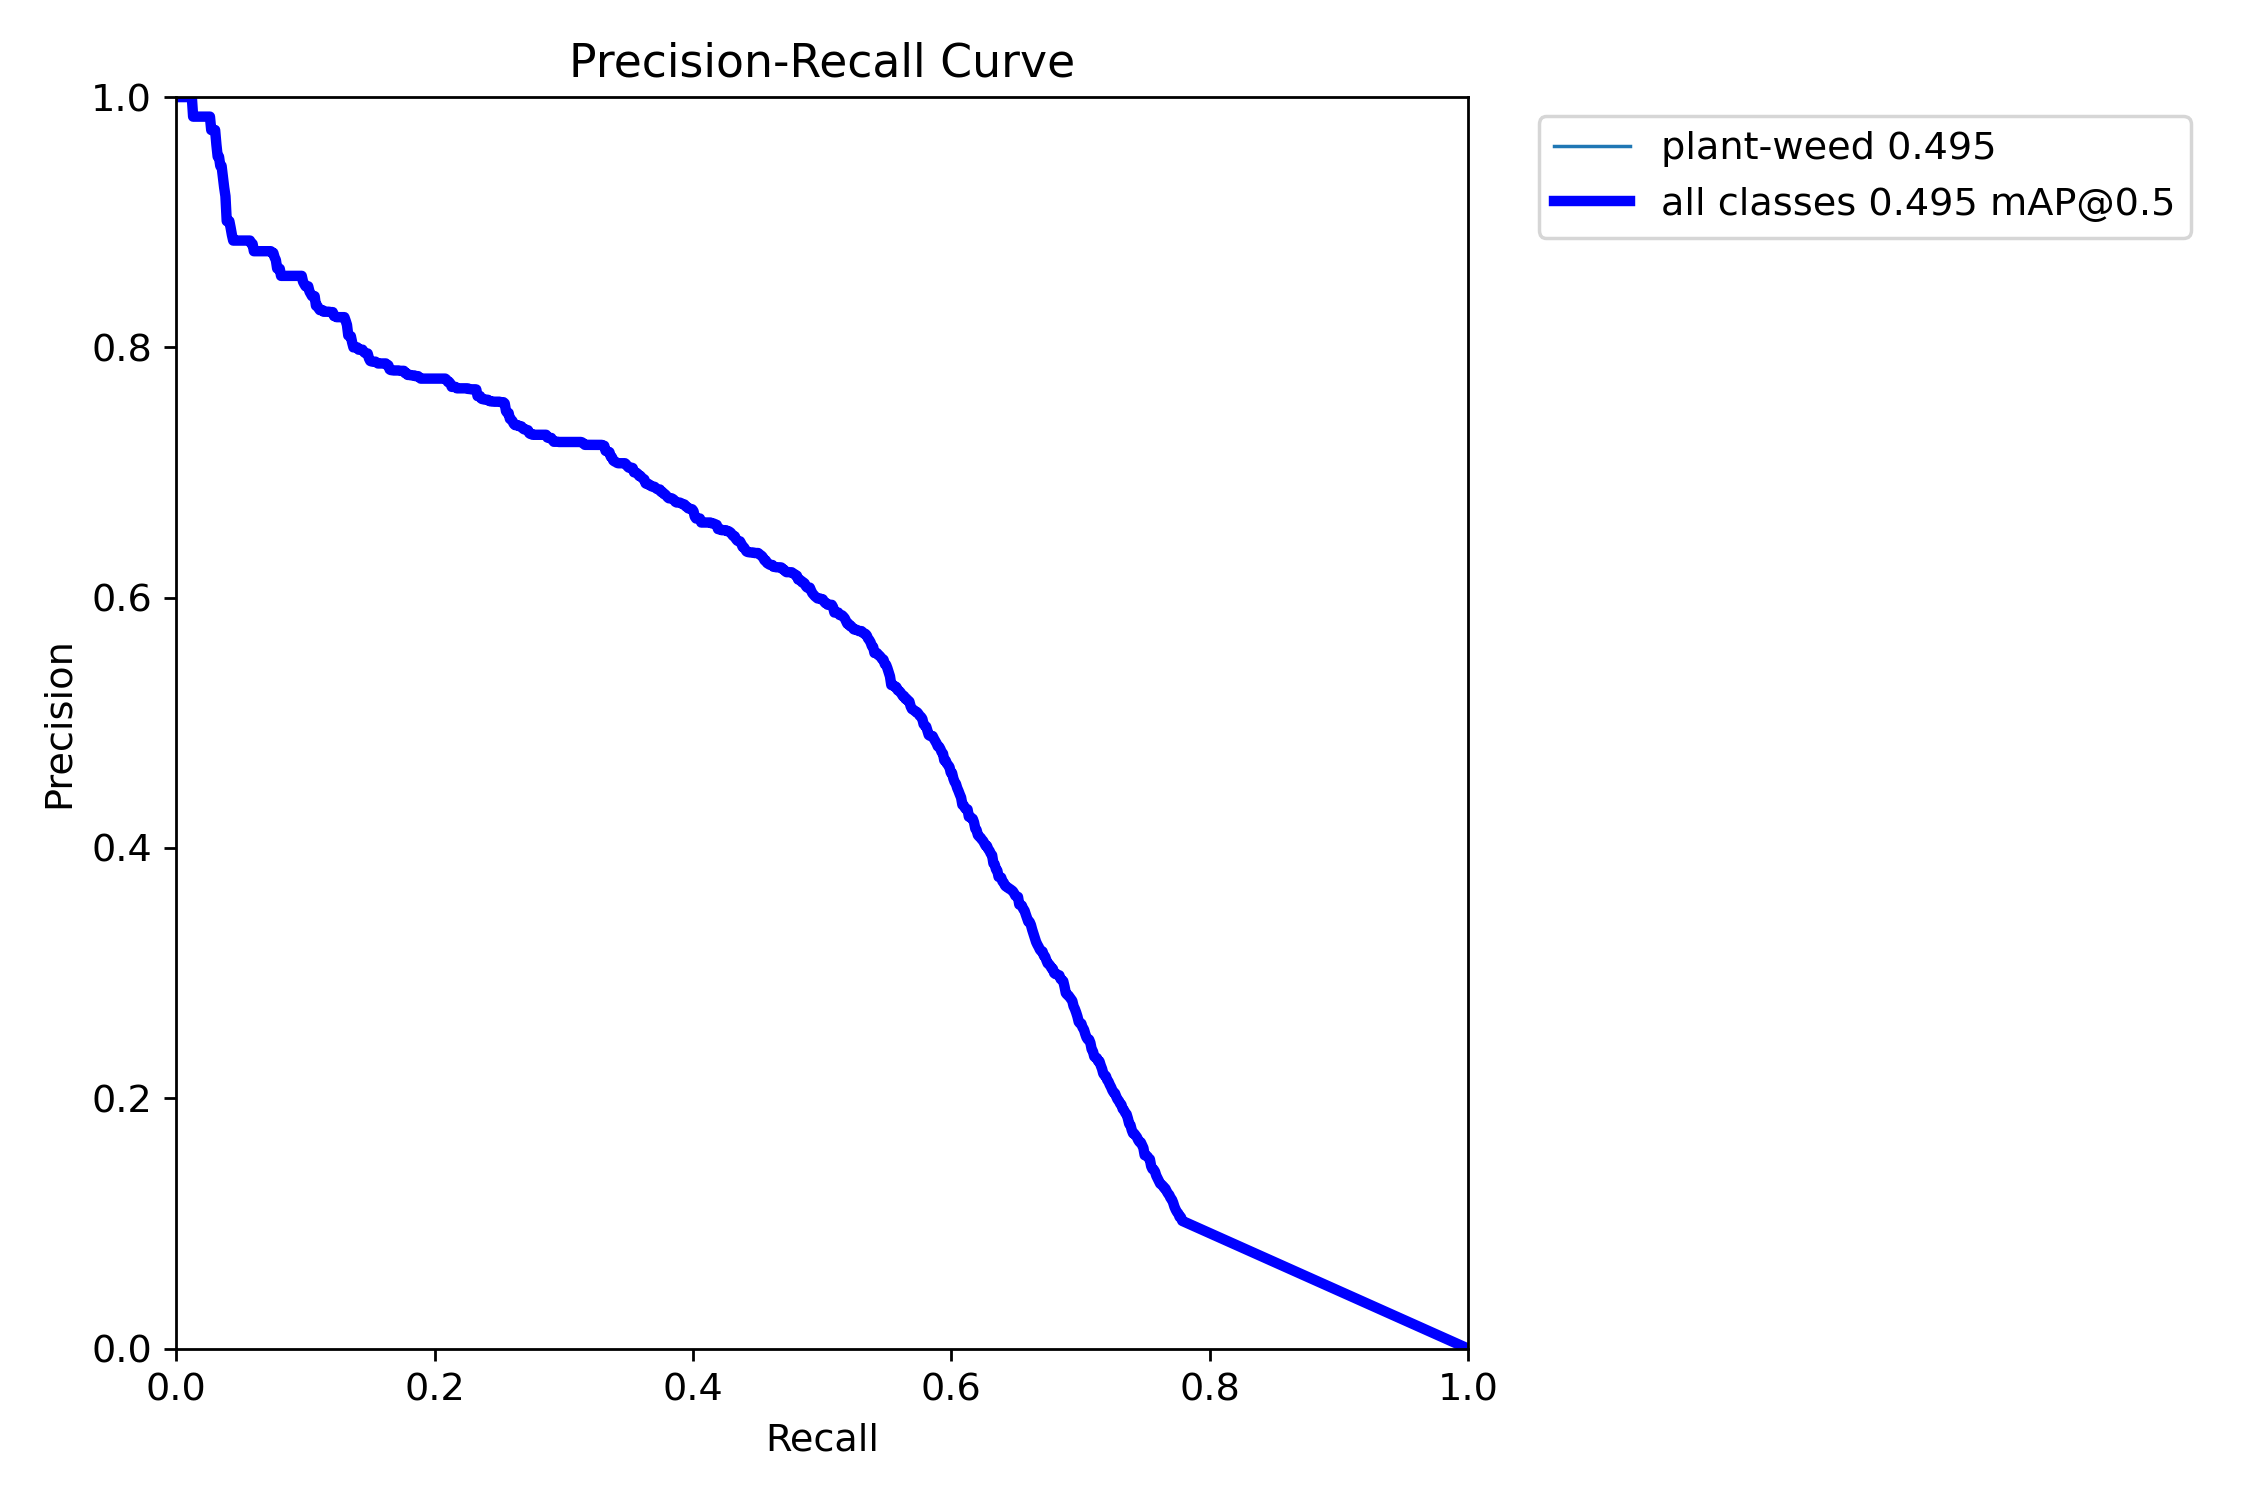

In [37]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

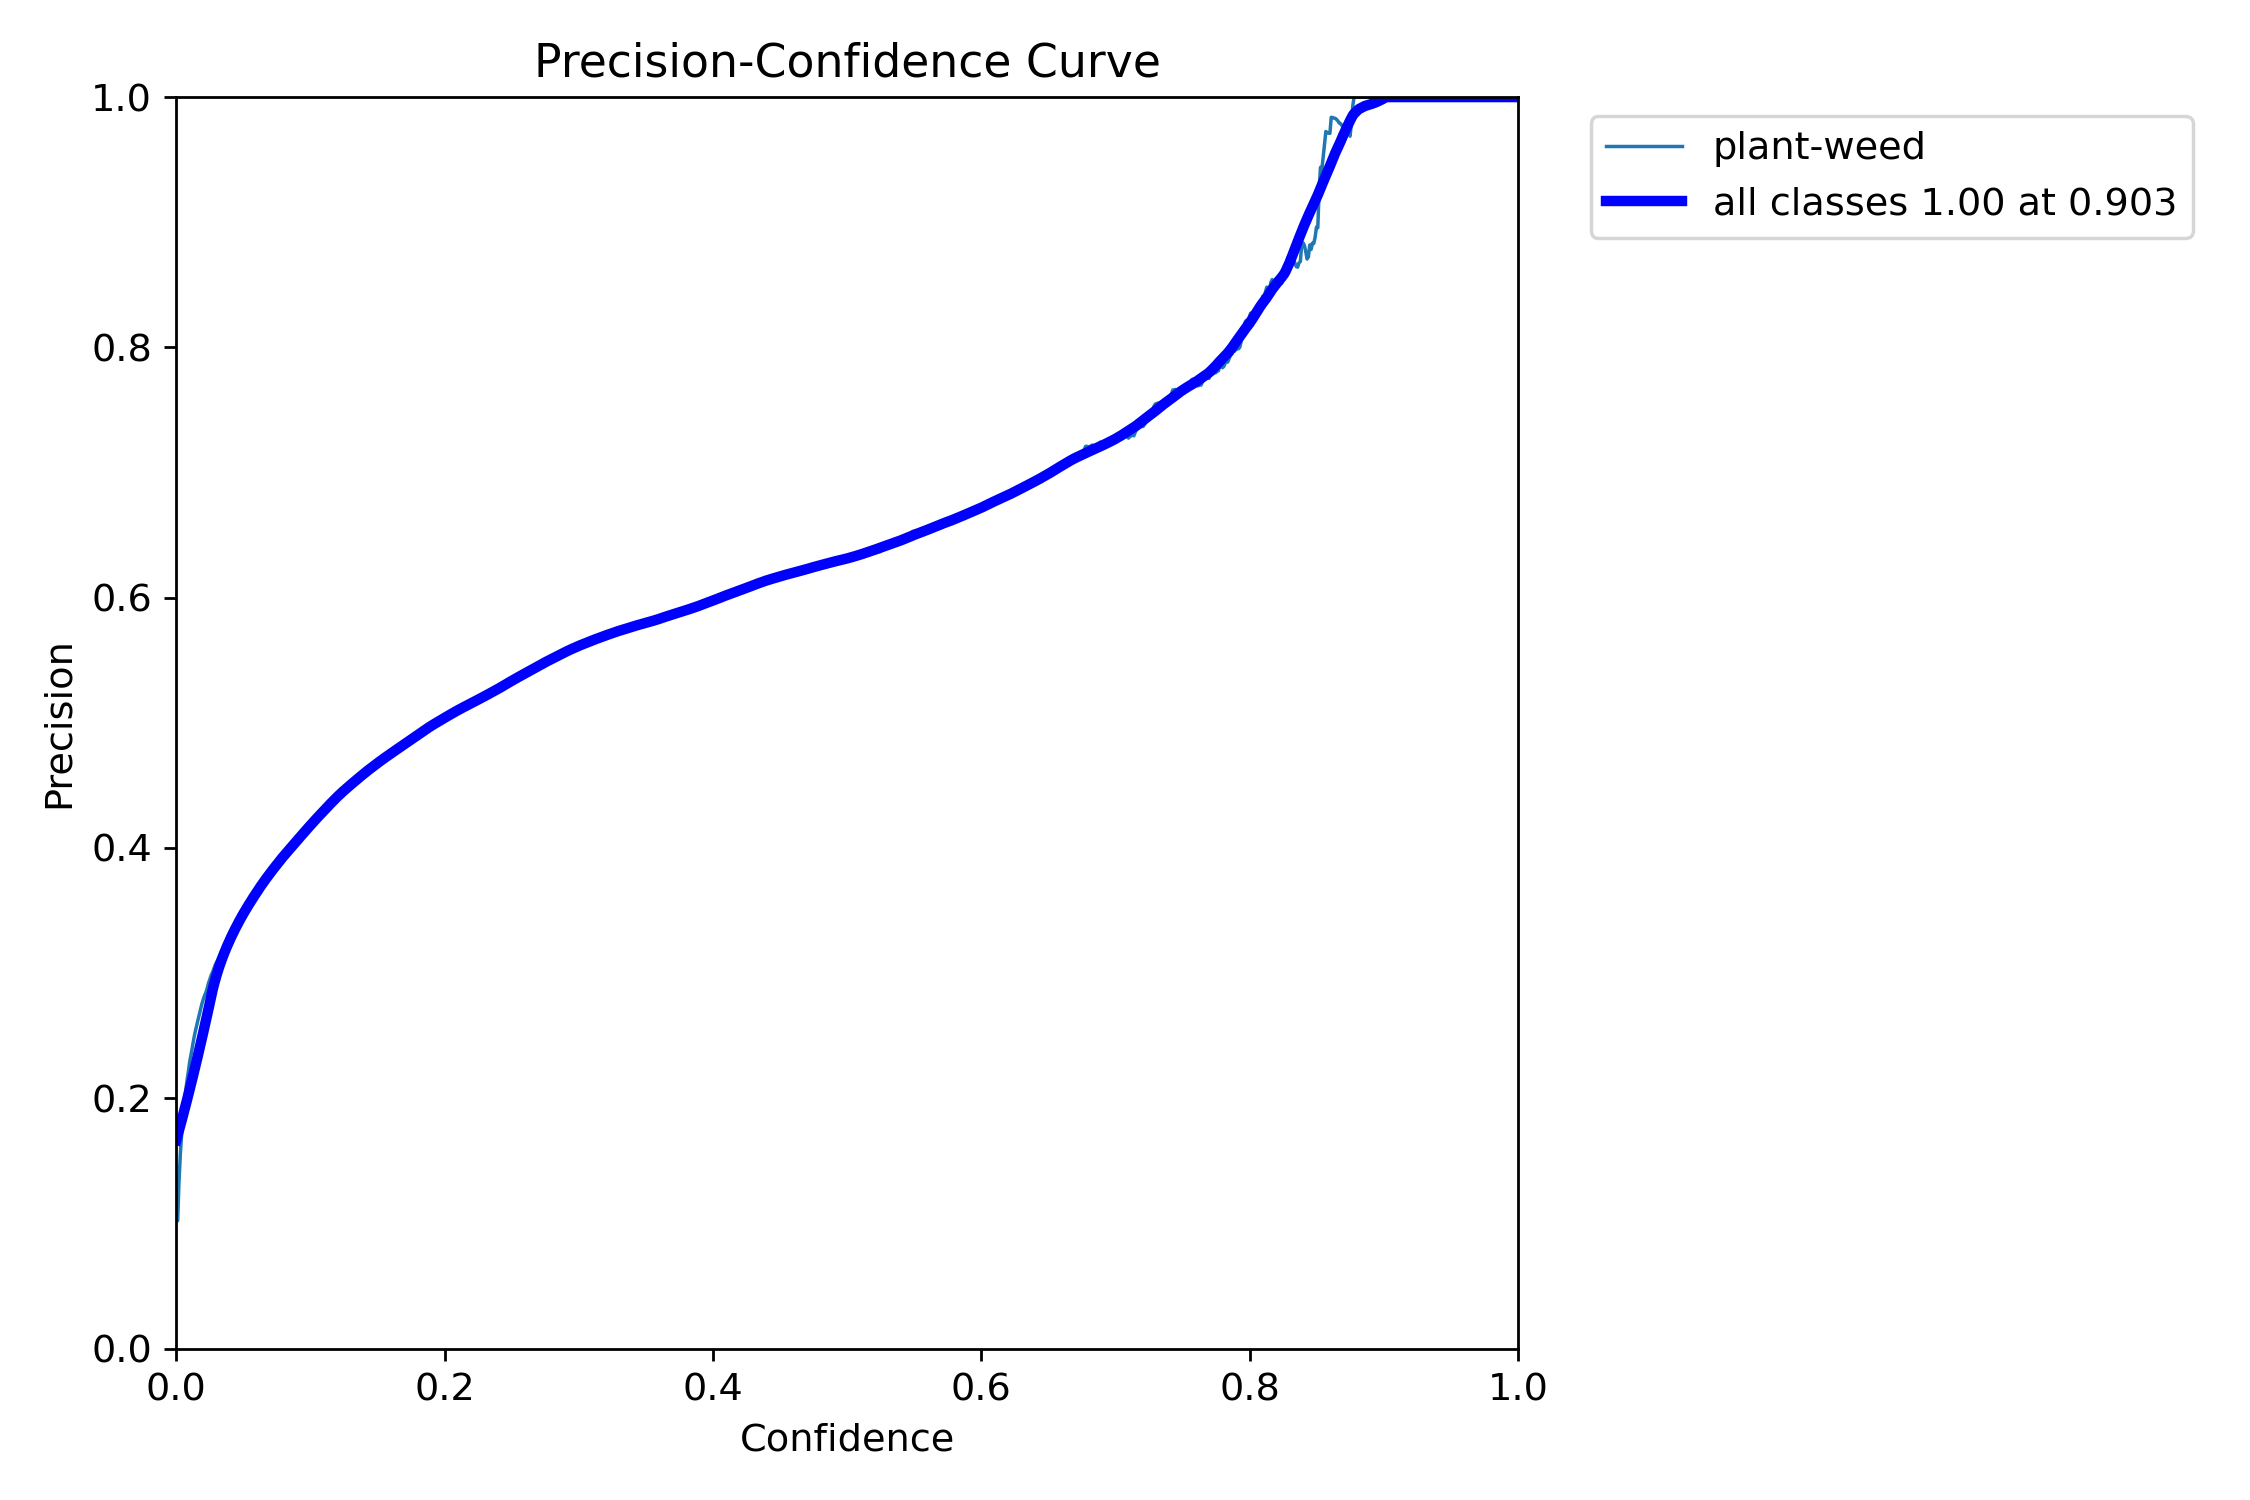

In [38]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

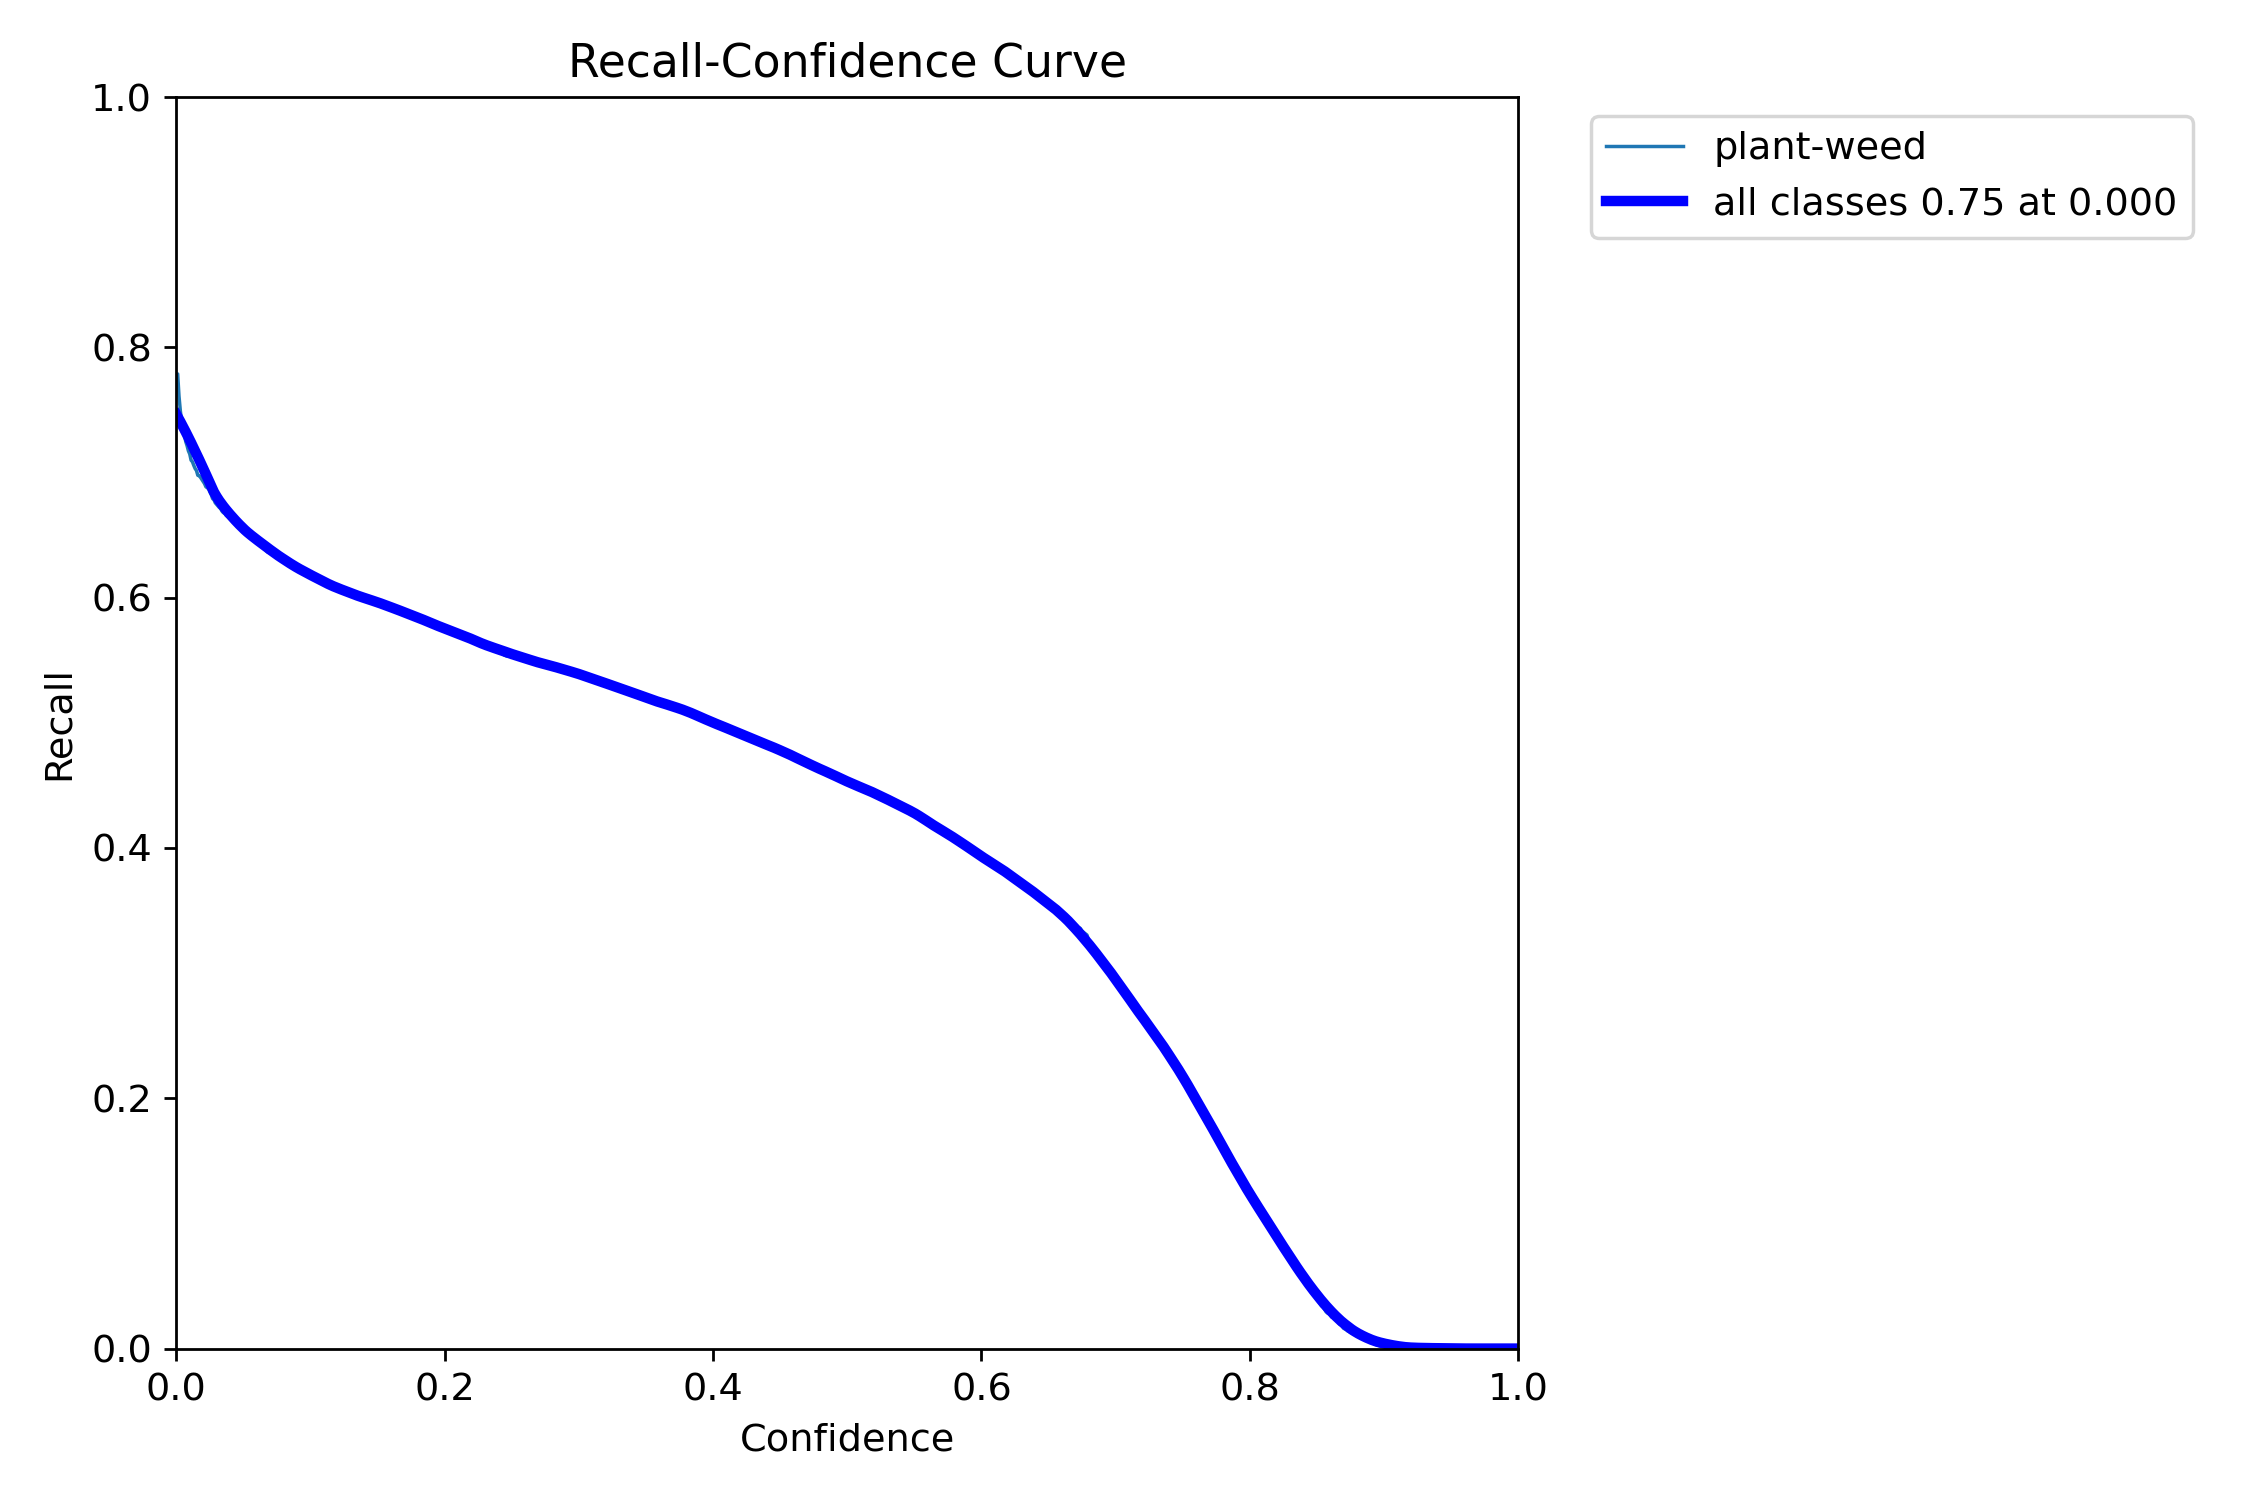

In [39]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

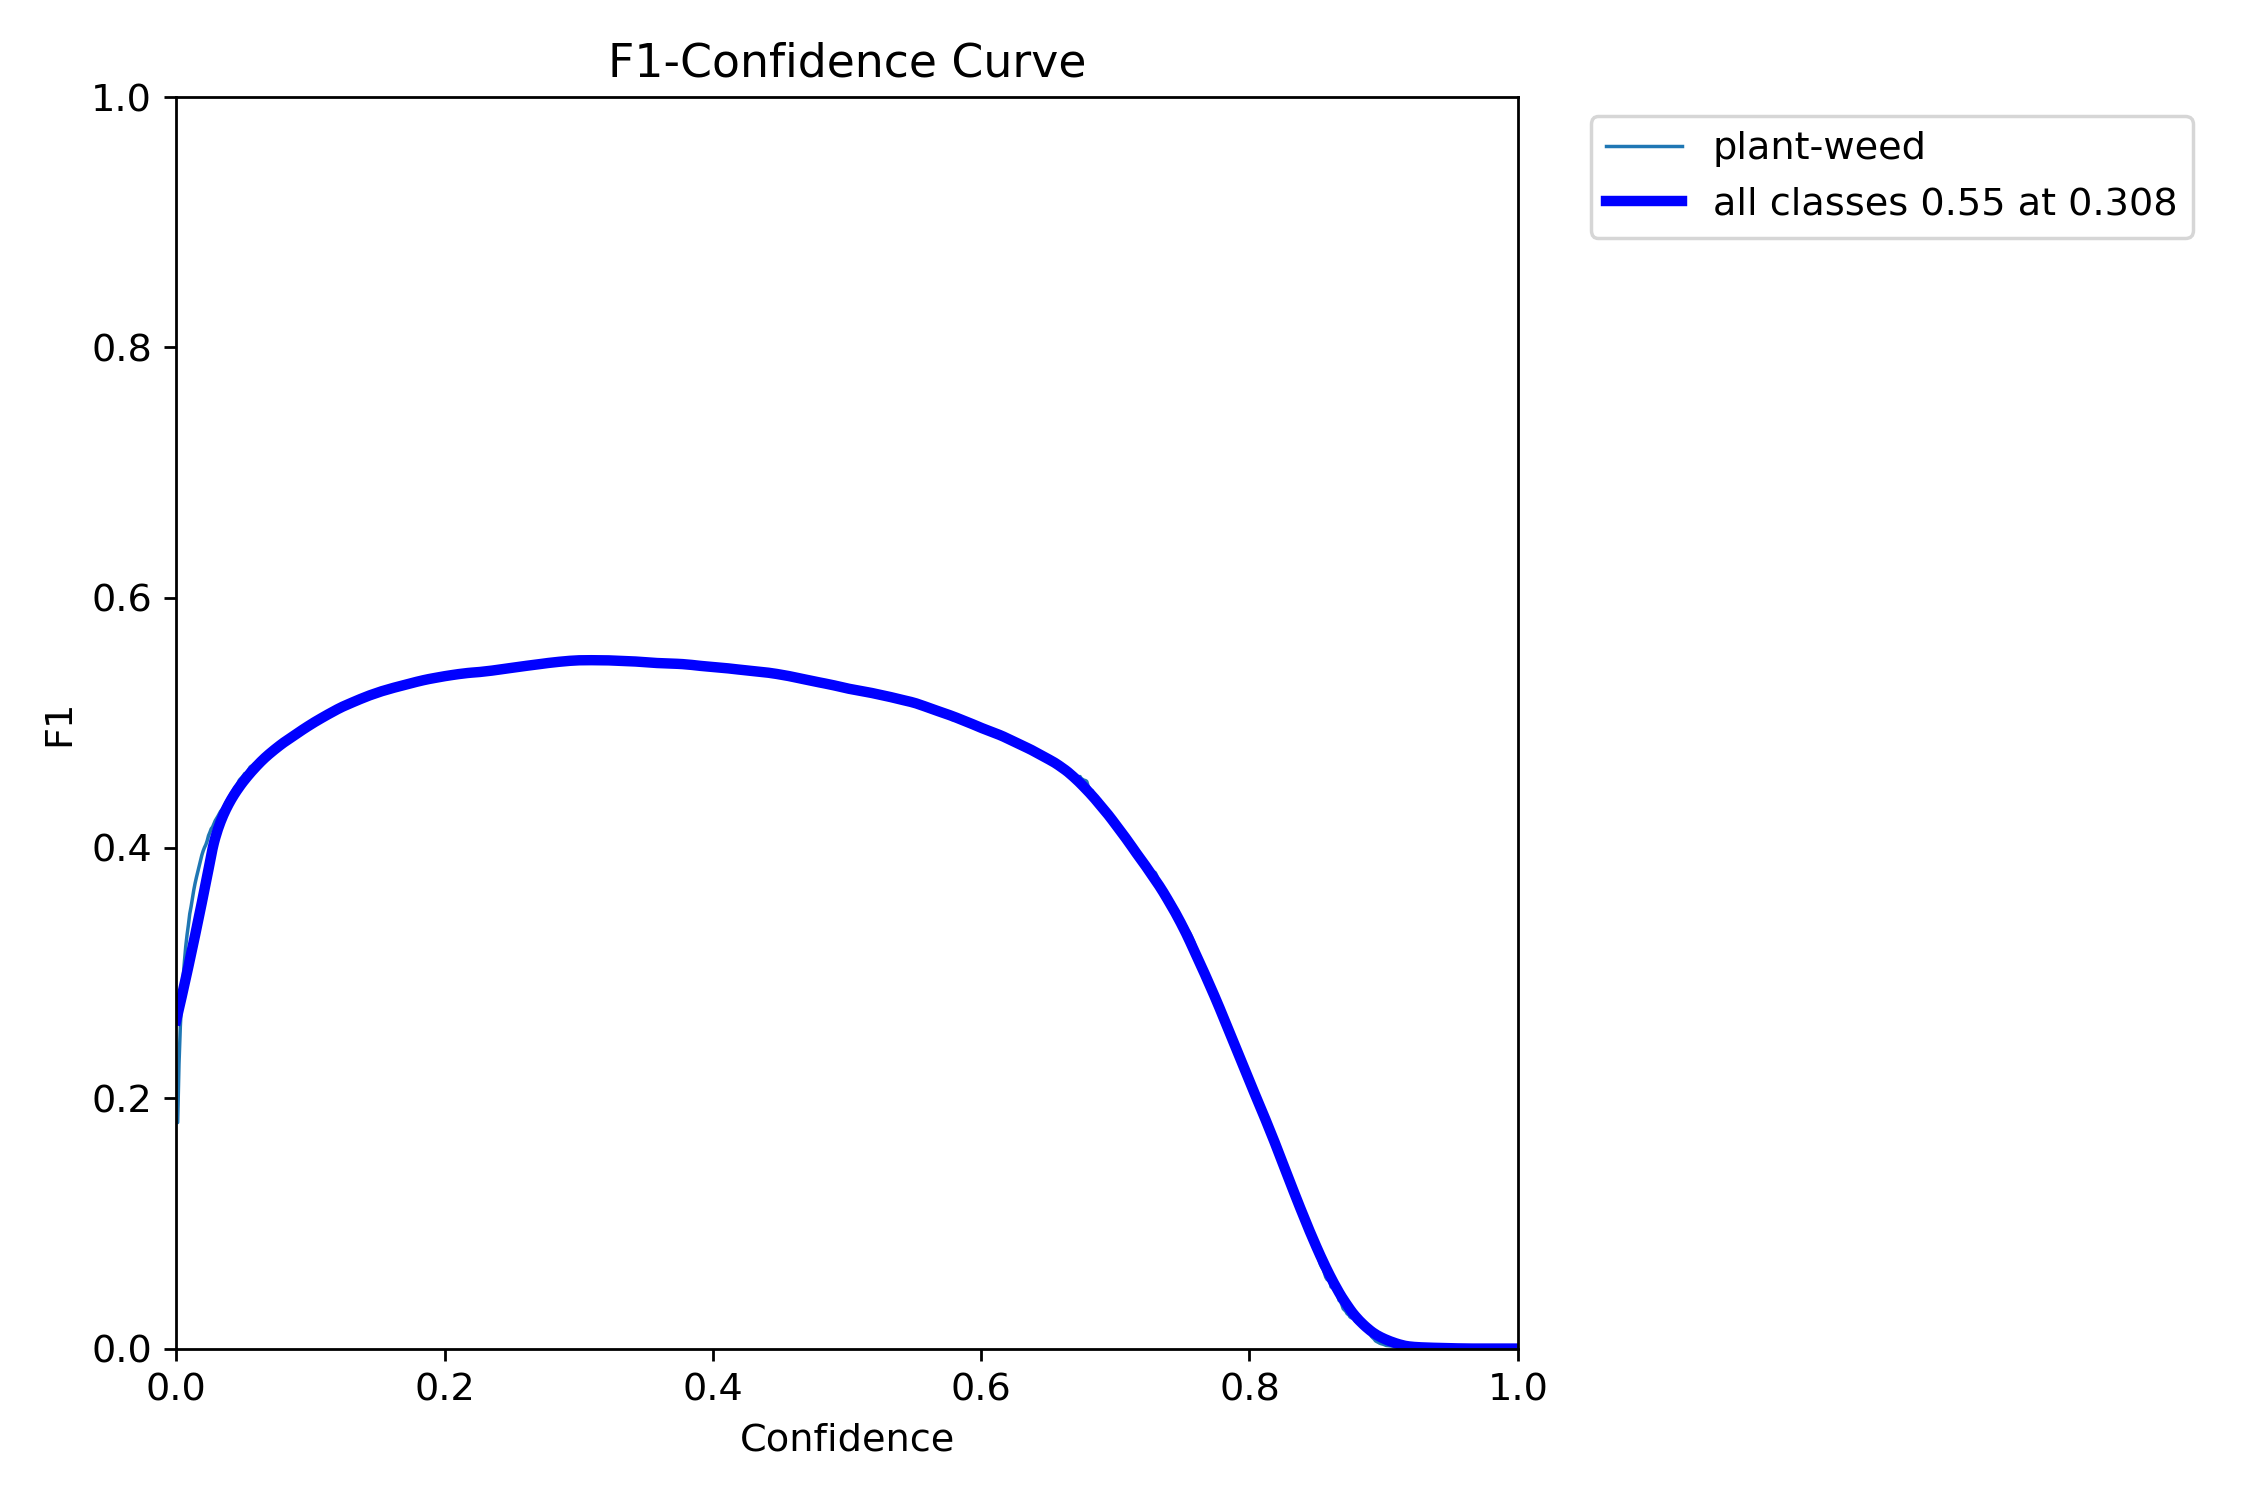

In [40]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Experiment 27
### *8 layers freezing | ~1000 epochs*
Every layer was initialized with pre-trained YOLOv8 weights and then freezed up to 8th layer and re-trained for ~1000 epochs

In [41]:
folder = "train3/"

In [42]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
1247,1248,14363.0,0.58453,0.34254,0.83994,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000026,0.000026,0.000026
1248,1249,14375.3,0.61453,0.35881,0.84635,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000025,0.000025,0.000025
1249,1250,14385.7,0.58413,0.34333,0.83648,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000023,0.000023,0.000023
1250,1251,14391.2,0.57823,0.33969,0.83803,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000023,0.000023,0.000023
1251,1252,14410.3,0.58034,0.34377,0.83817,0.53887,0.45114,0.43299,0.14432,2.70694,1.49658,1.94813,0.000022,0.000022,0.000022


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [43]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 240.172 min


#### Best epoch

In [44]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1251,1252,14410.3,0.58034,0.34377,0.83817,0.53887,0.45114,0.43299,0.14432,2.70694,1.49658,1.94813,0.000022,0.000022,0.000022,240.171667


In [45]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1252 con mAP50 de 0.433


In [46]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [177]:
TP = 1235
FP = 867
FN = 1174
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3276


In [178]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.376984126984127, 0.26465201465201466, 0.35836385836385837)

### Graphs

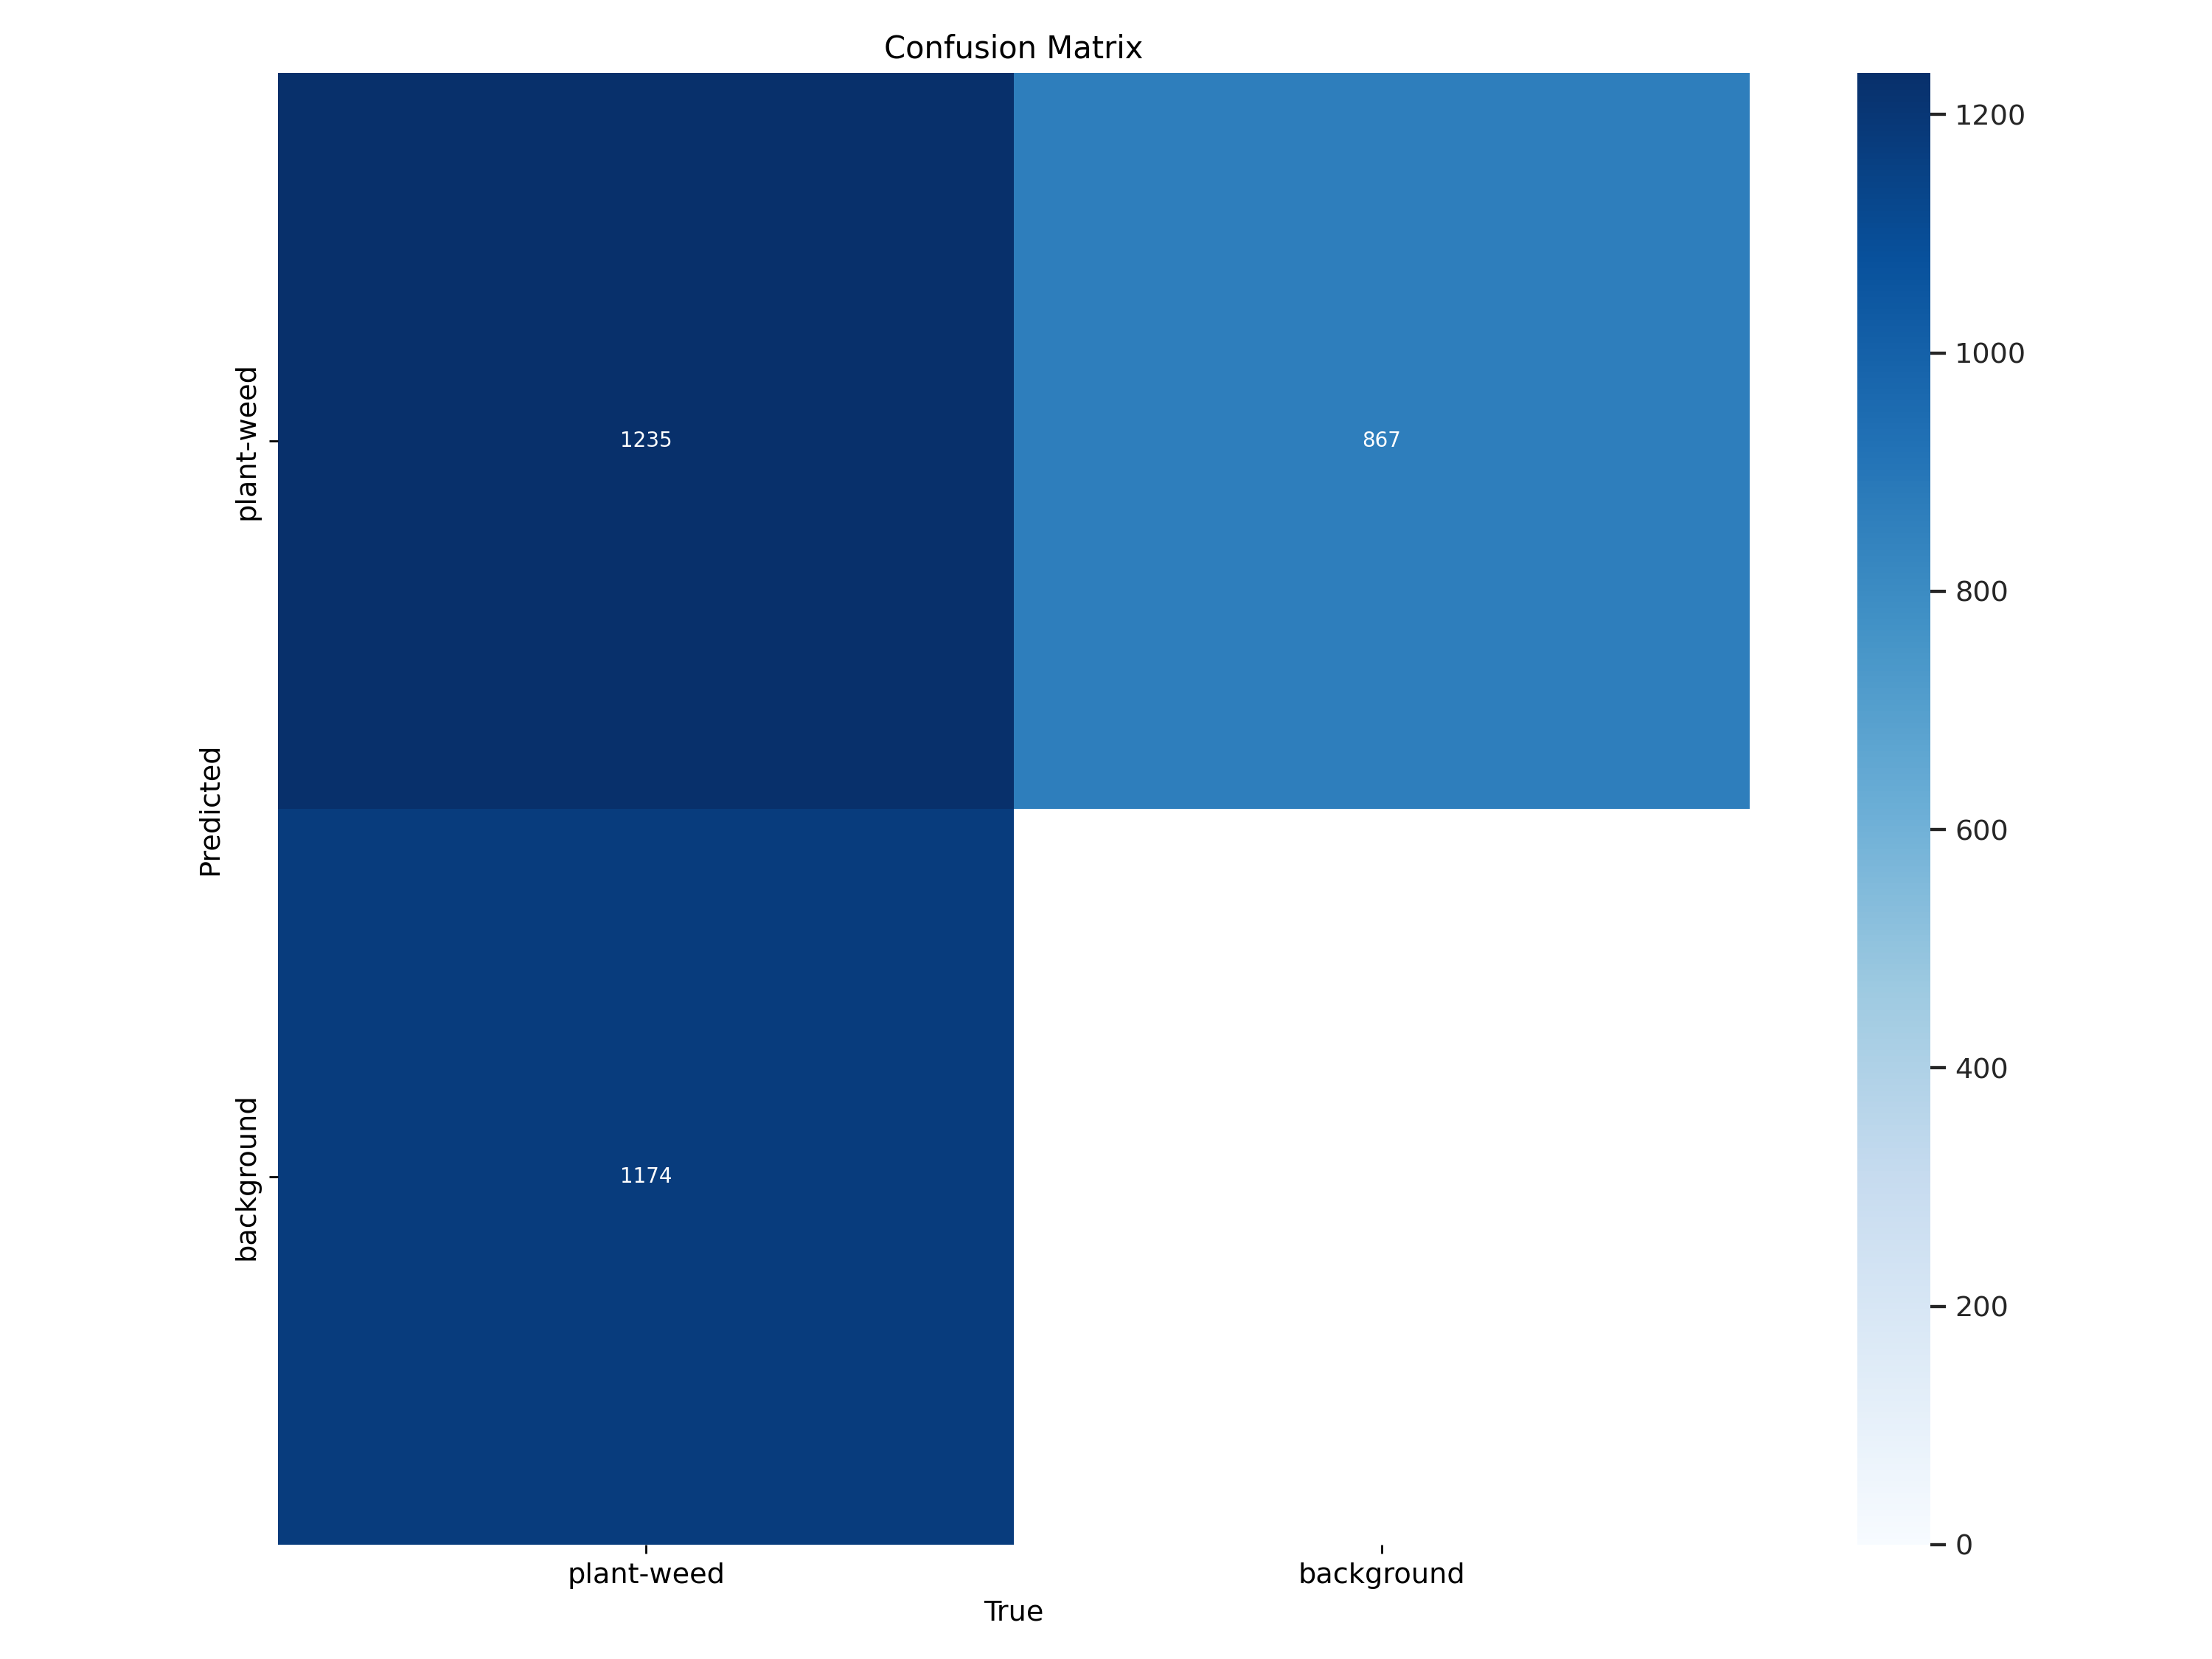

In [49]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

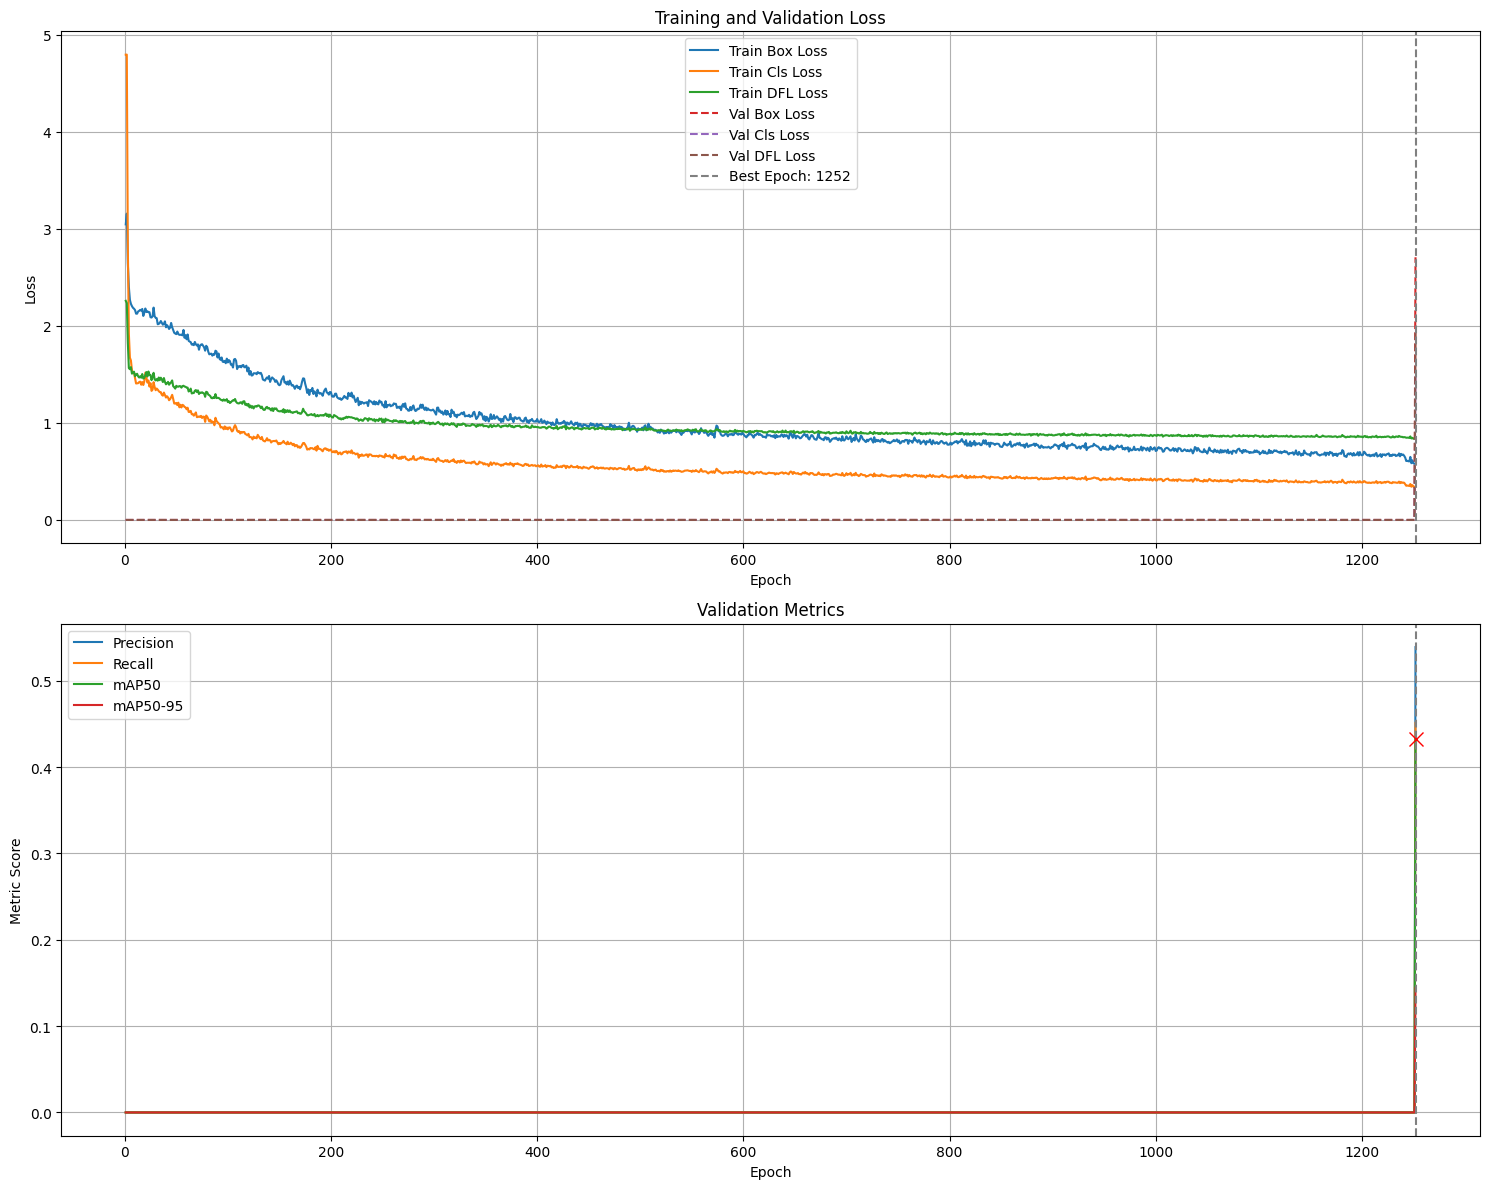

In [50]:
graph_training_metrics(df, epoch, graph="full")

In [51]:
graph_LrLoss_3D(df)

Validation set


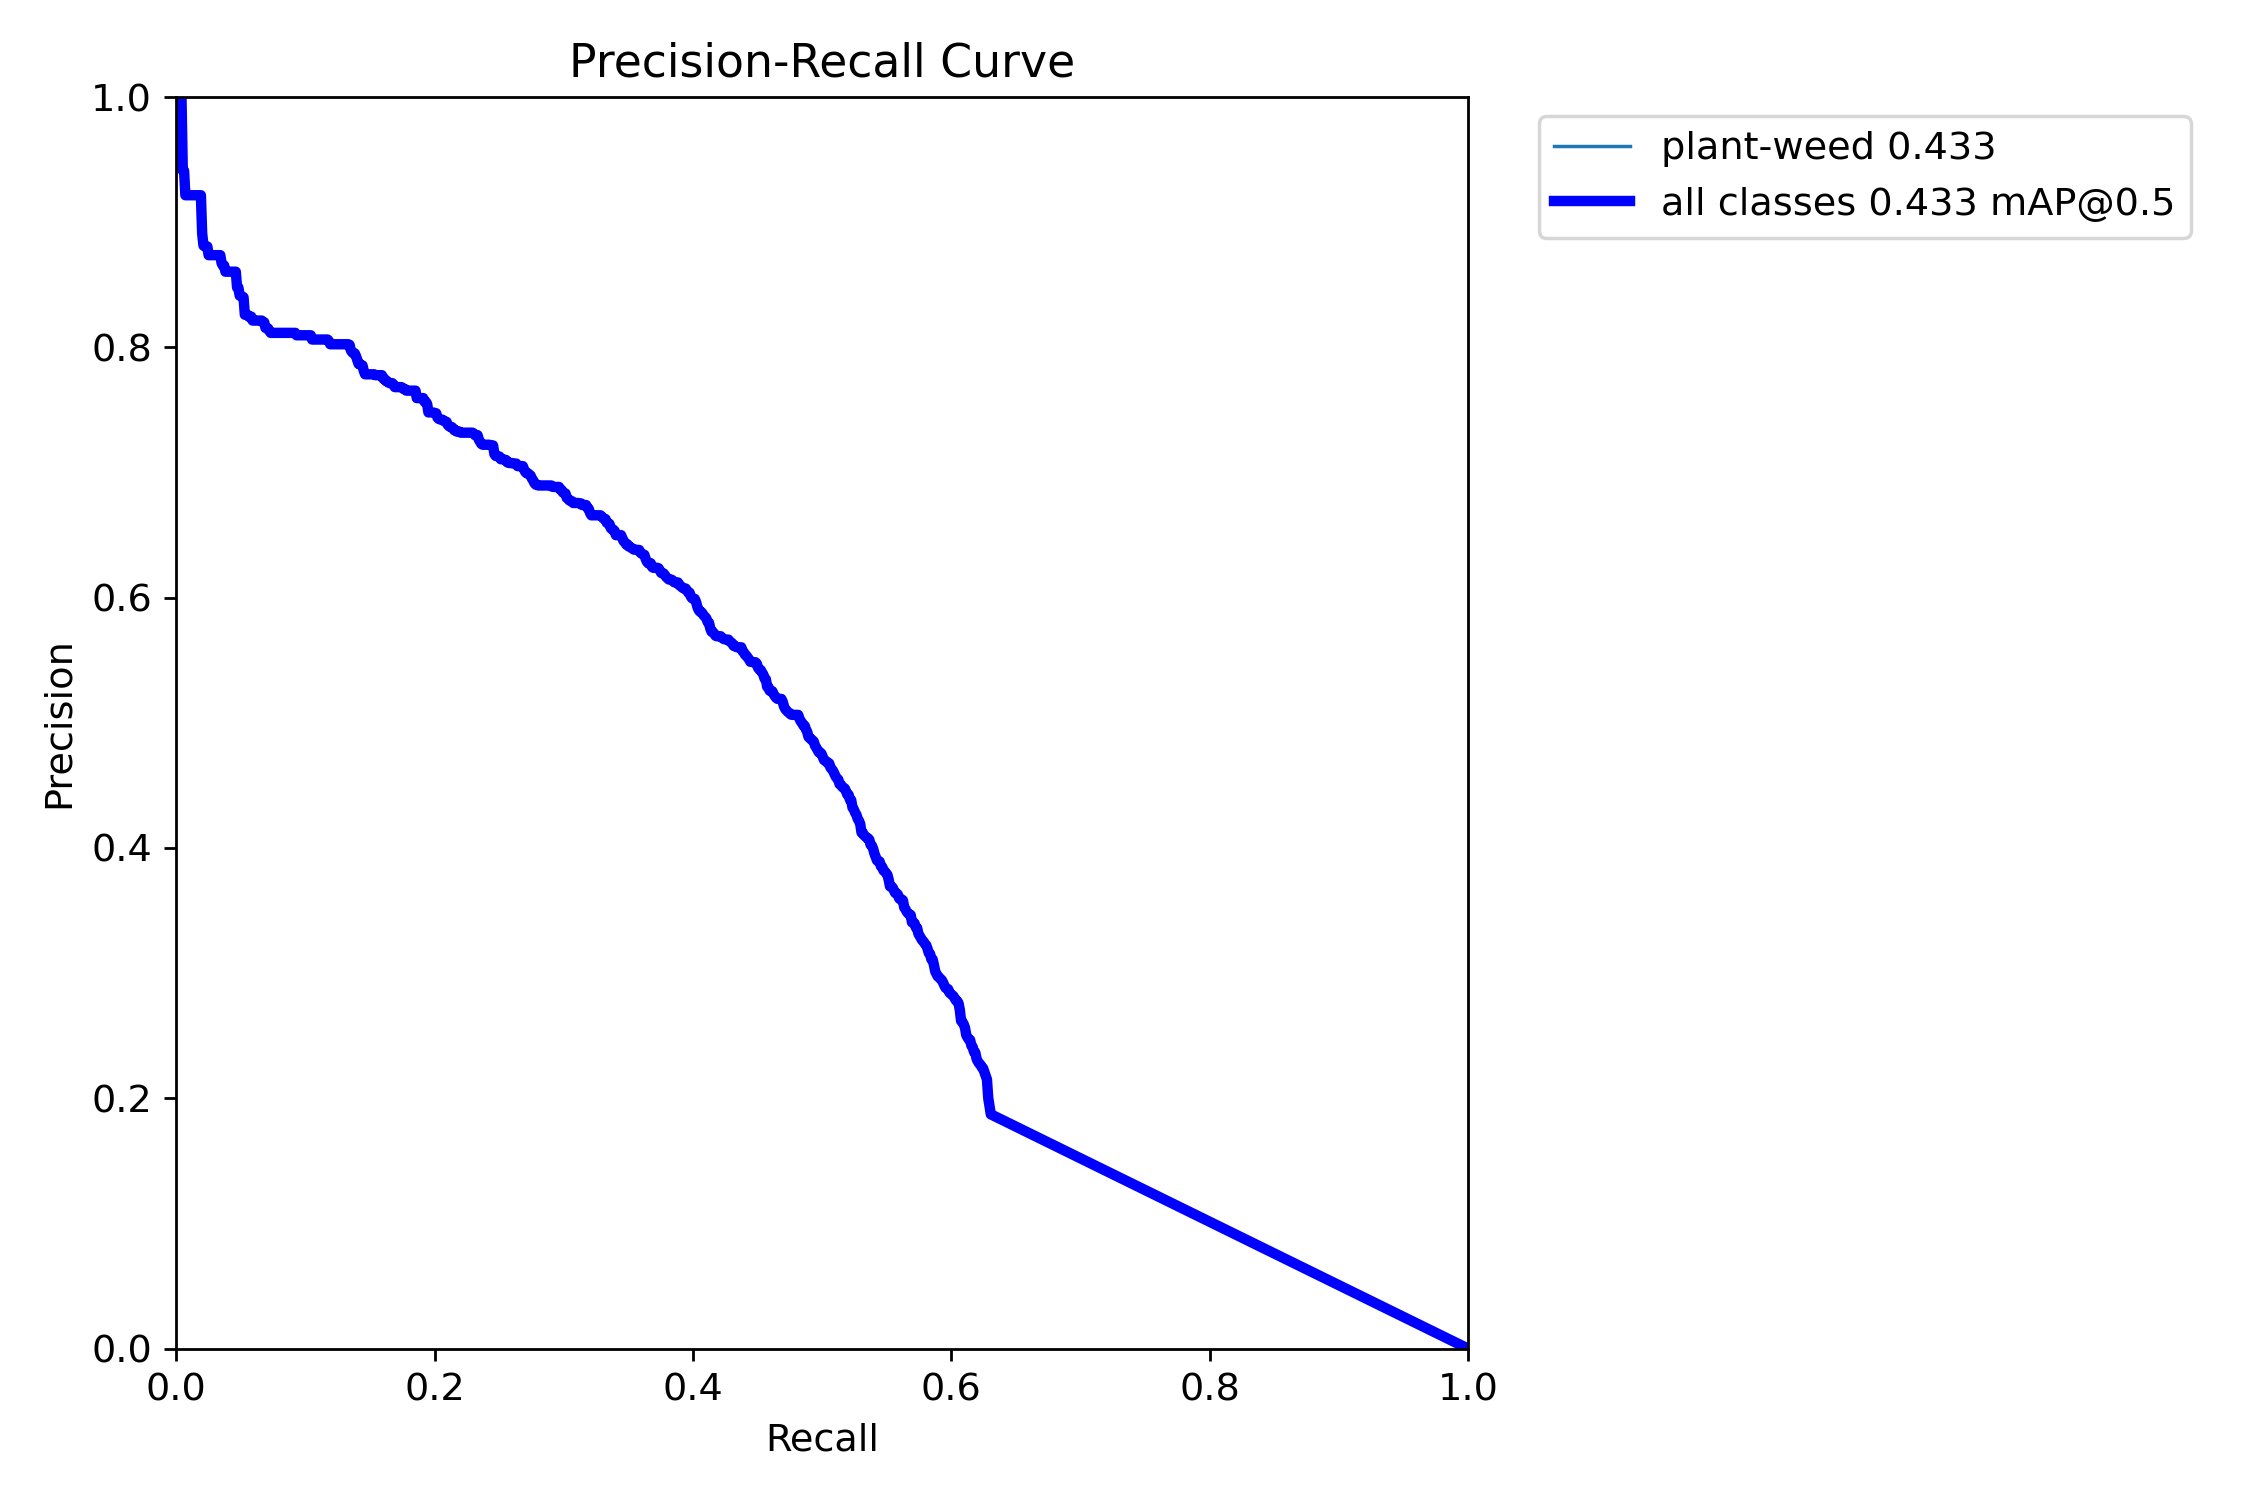

In [52]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

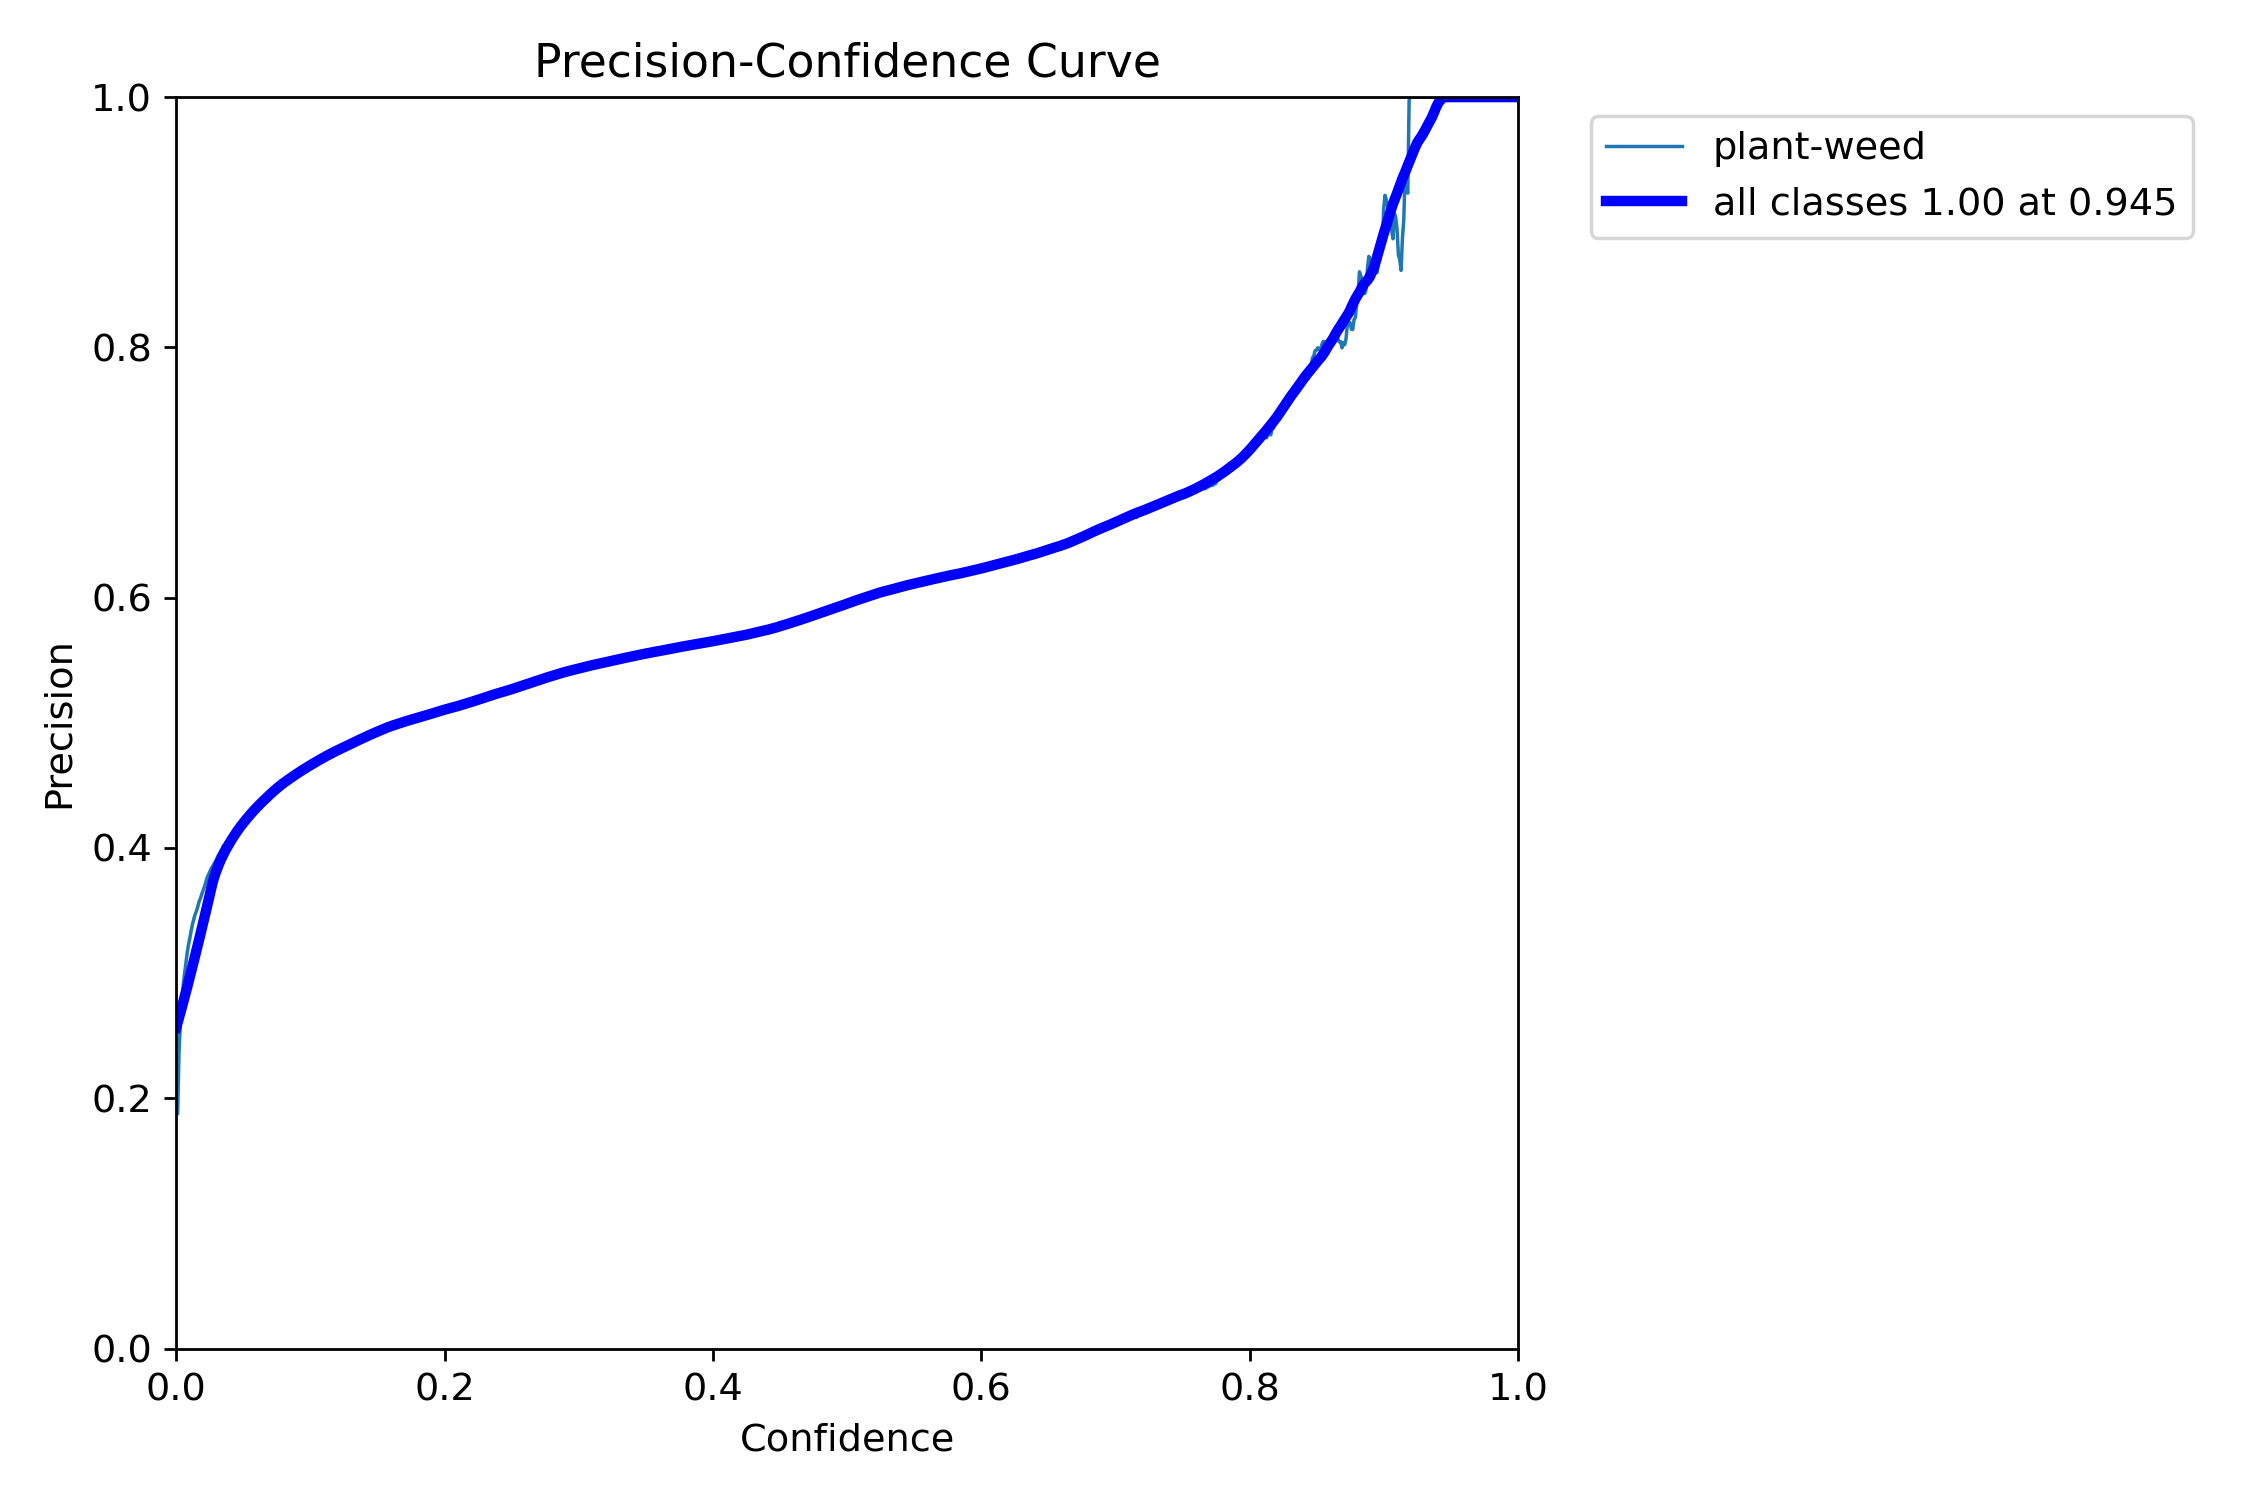

In [53]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

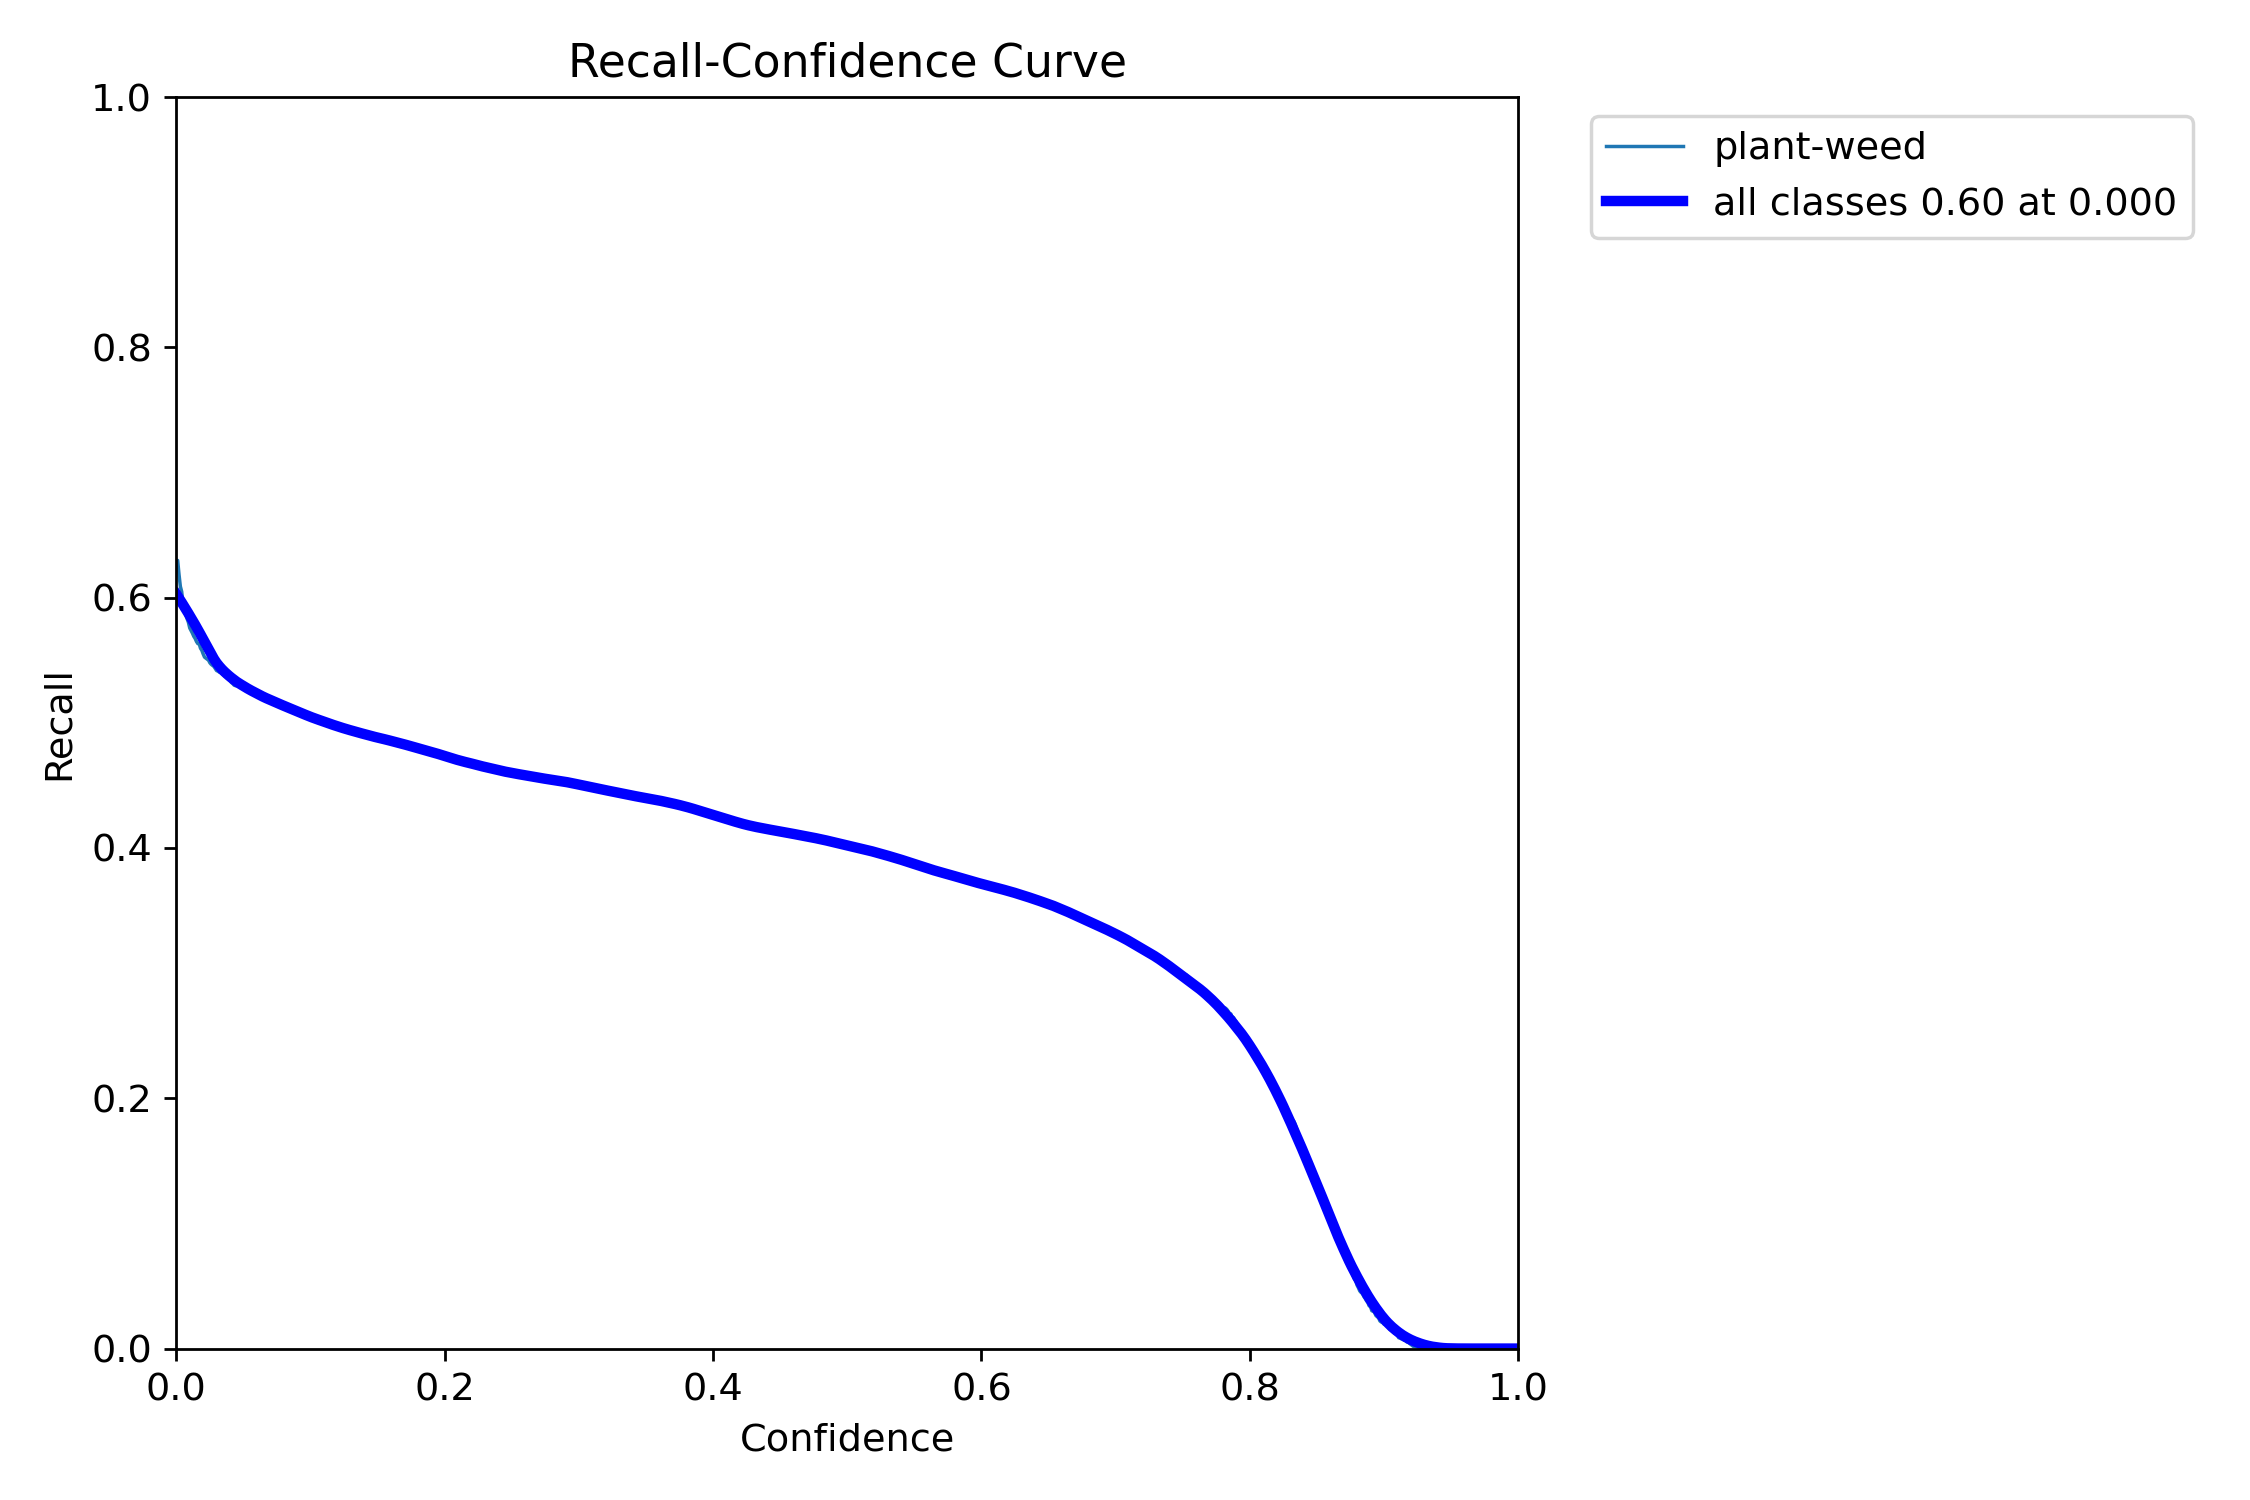

In [54]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

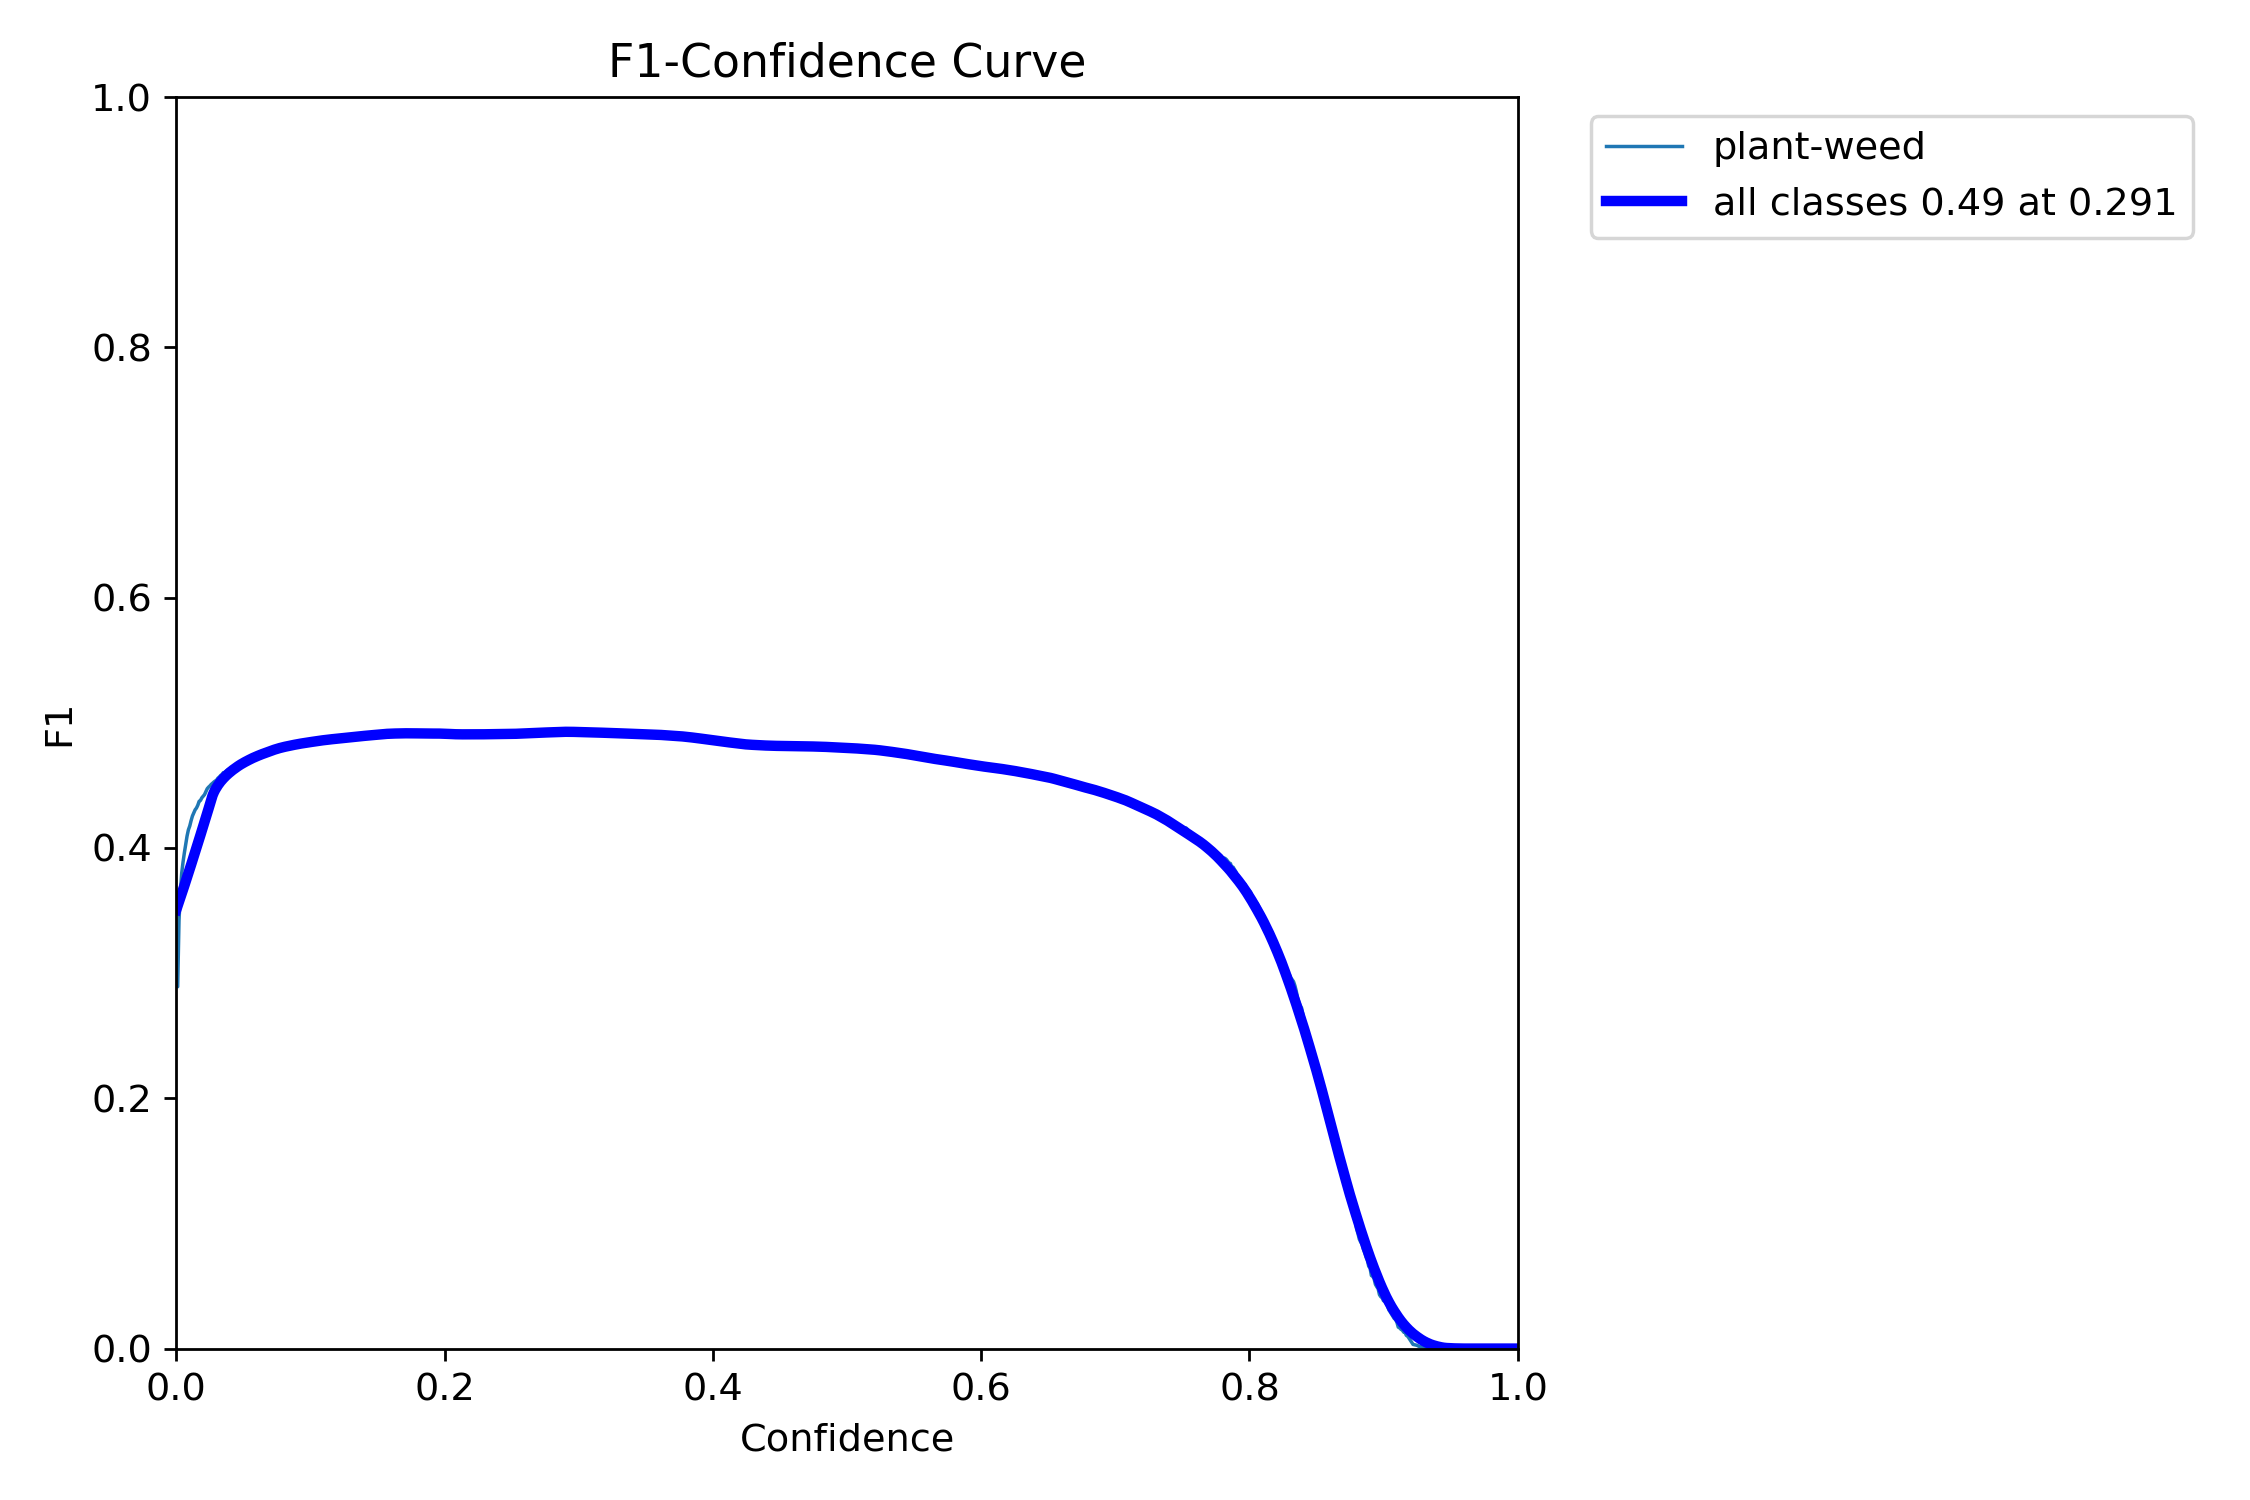

In [55]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Experiment 28
### *12 layers freezing | ~1000 epochs*
Every layer was initialized with pre-trained YOLOv8 weights and then freezed up to 12th layer and re-trained for ~1000 epochs

In [56]:
folder = "train4/"

In [57]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df4 = pd.read_csv(file_path)
df = df4.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
1440,1441,14362.4,0.89866,0.52854,0.91182,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000027,0.000027,0.000027
1441,1442,14368.3,0.85927,0.51018,0.90897,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000025,0.000025,0.000025
1442,1443,14374.2,0.84906,0.49707,0.89932,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000025,0.000025,0.000025
1443,1444,14380.3,0.84407,0.50688,0.89208,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000024,0.000024,0.000024
1444,1445,14409.1,0.87407,0.51323,0.90462,0.52267,0.47696,0.45023,0.14495,2.5857,1.36671,1.73956,0.000021,0.000021,0.000021


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [58]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 240.152 min


#### Best epoch

In [59]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1444,1445,14409.1,0.87407,0.51323,0.90462,0.52267,0.47696,0.45023,0.14495,2.5857,1.36671,1.73956,0.000021,0.000021,0.000021,240.151667


In [60]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1445 con mAP50 de 0.450


In [61]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [179]:
TP = 1259
FP = 962
FN = 1150
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3371


In [180]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3734796796202907, 0.2853752595668941, 0.3411450608128152)

### Graphs

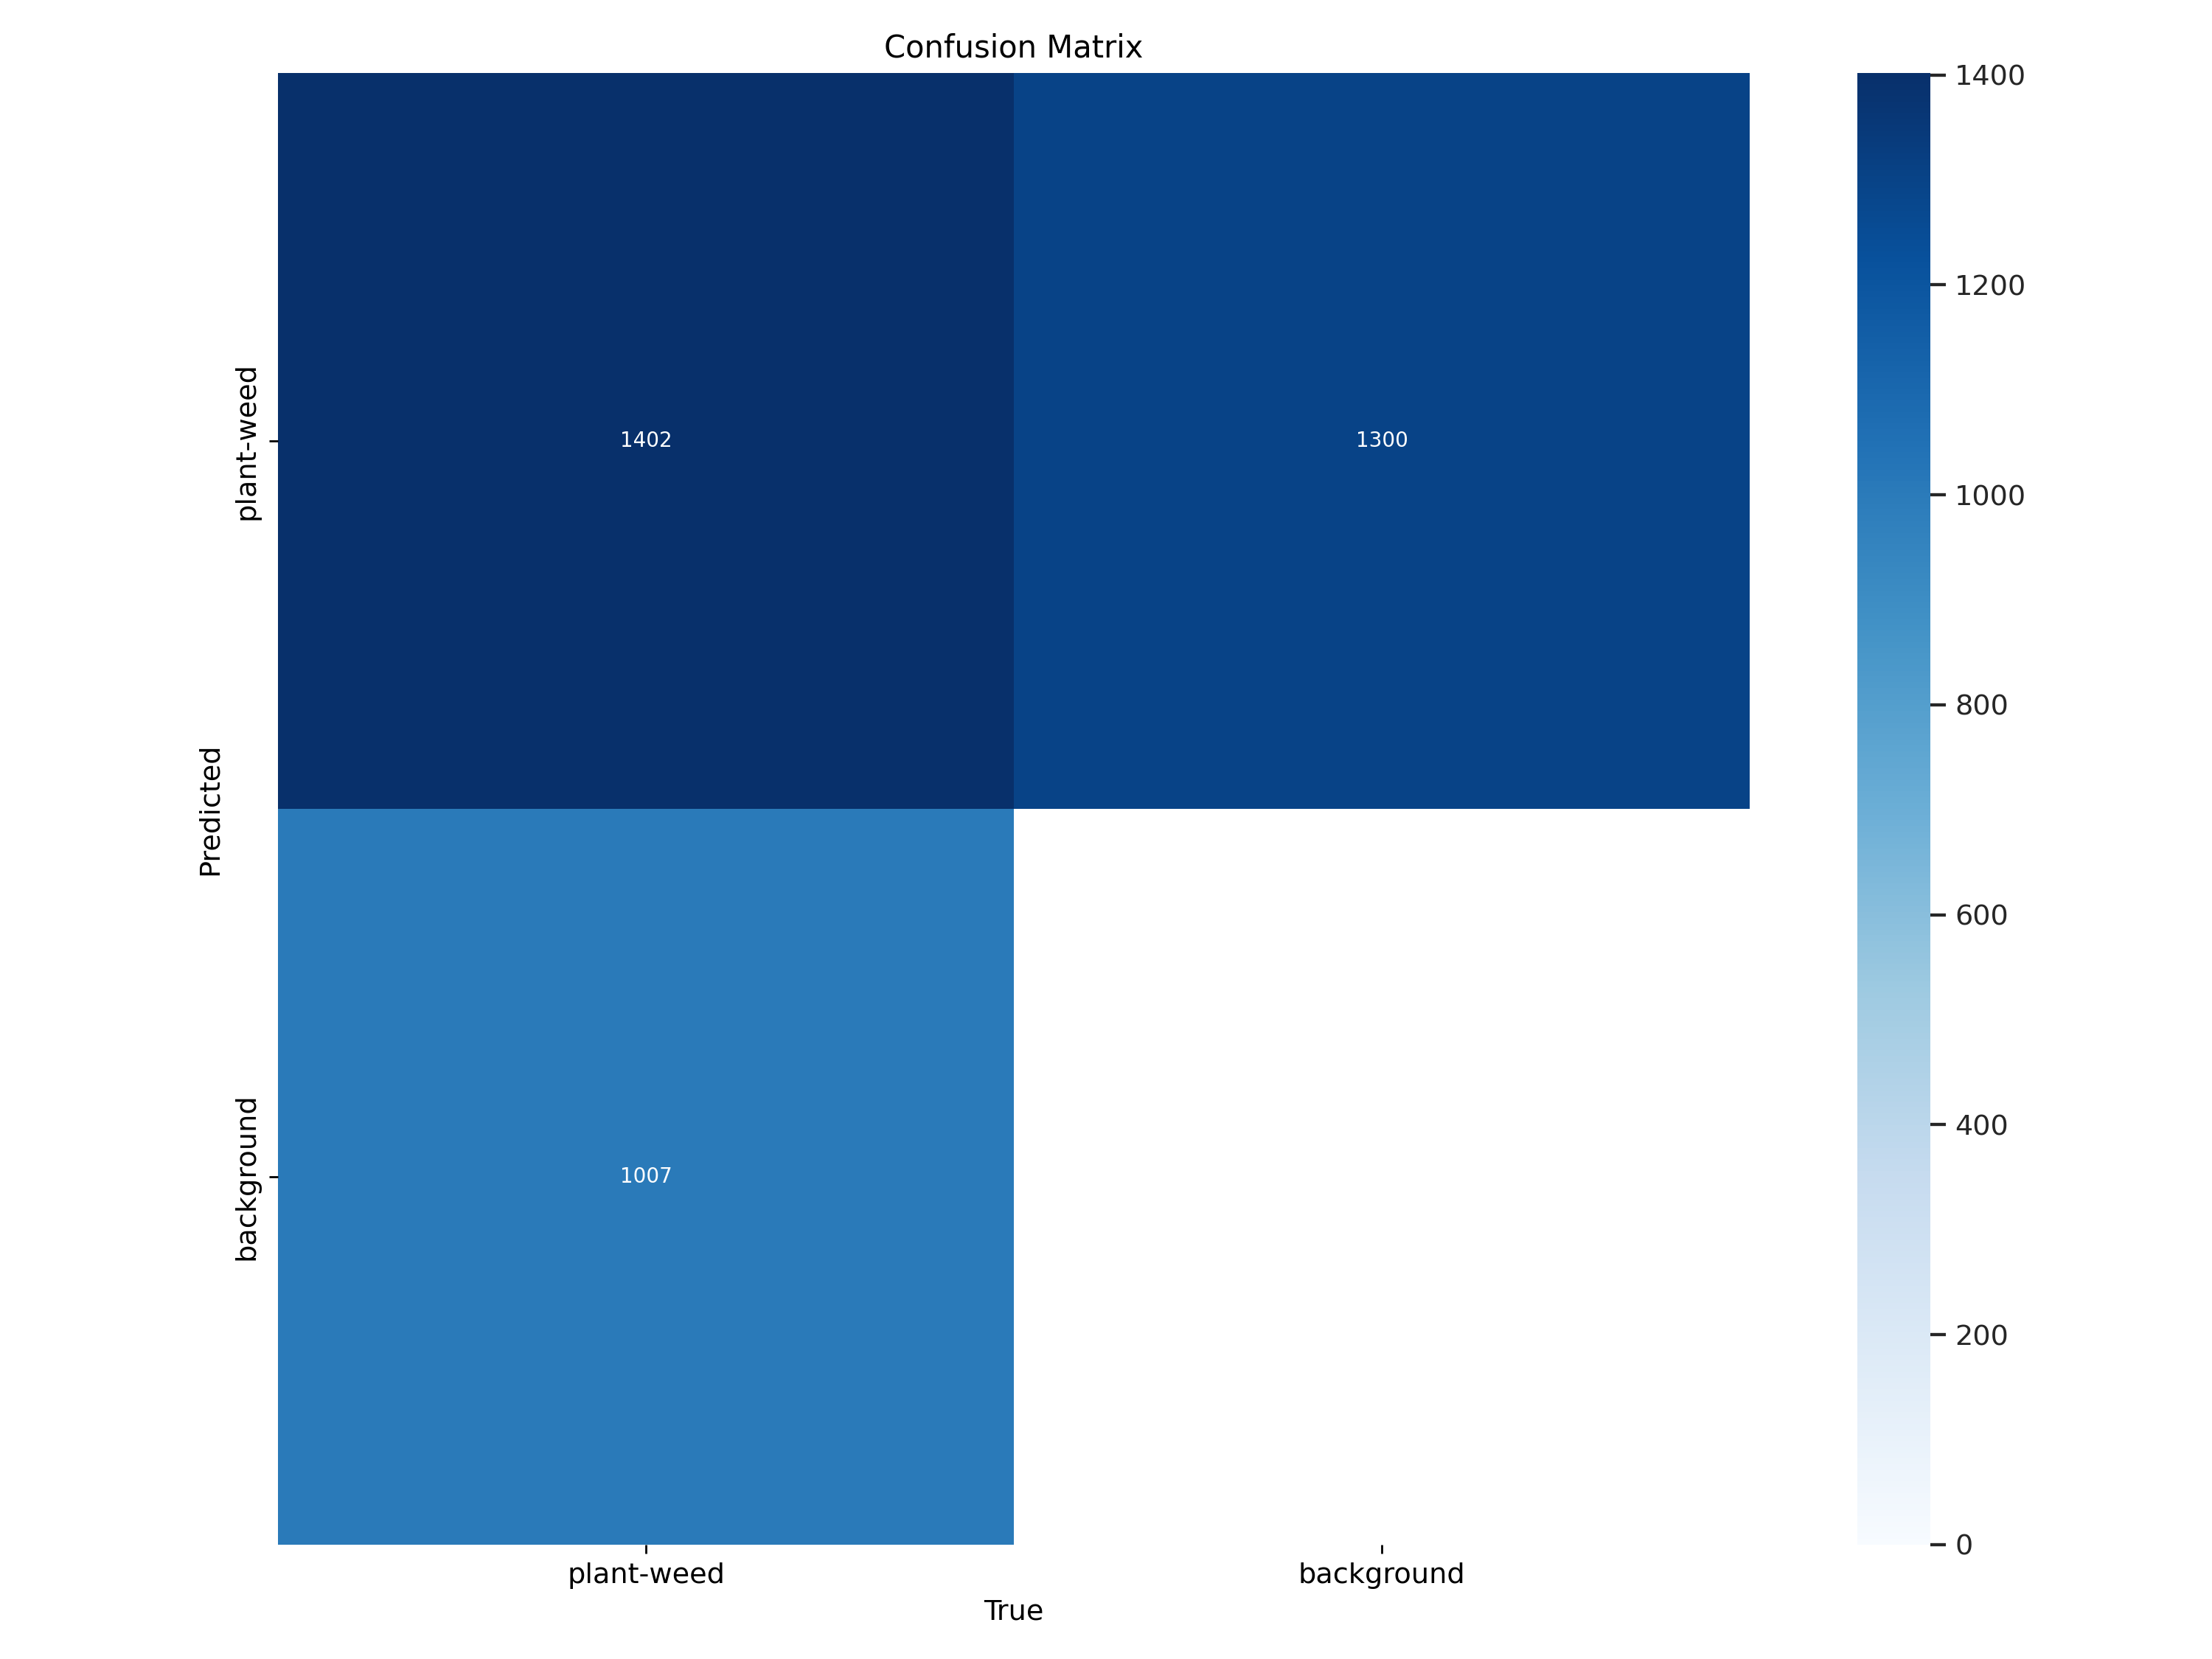

In [64]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

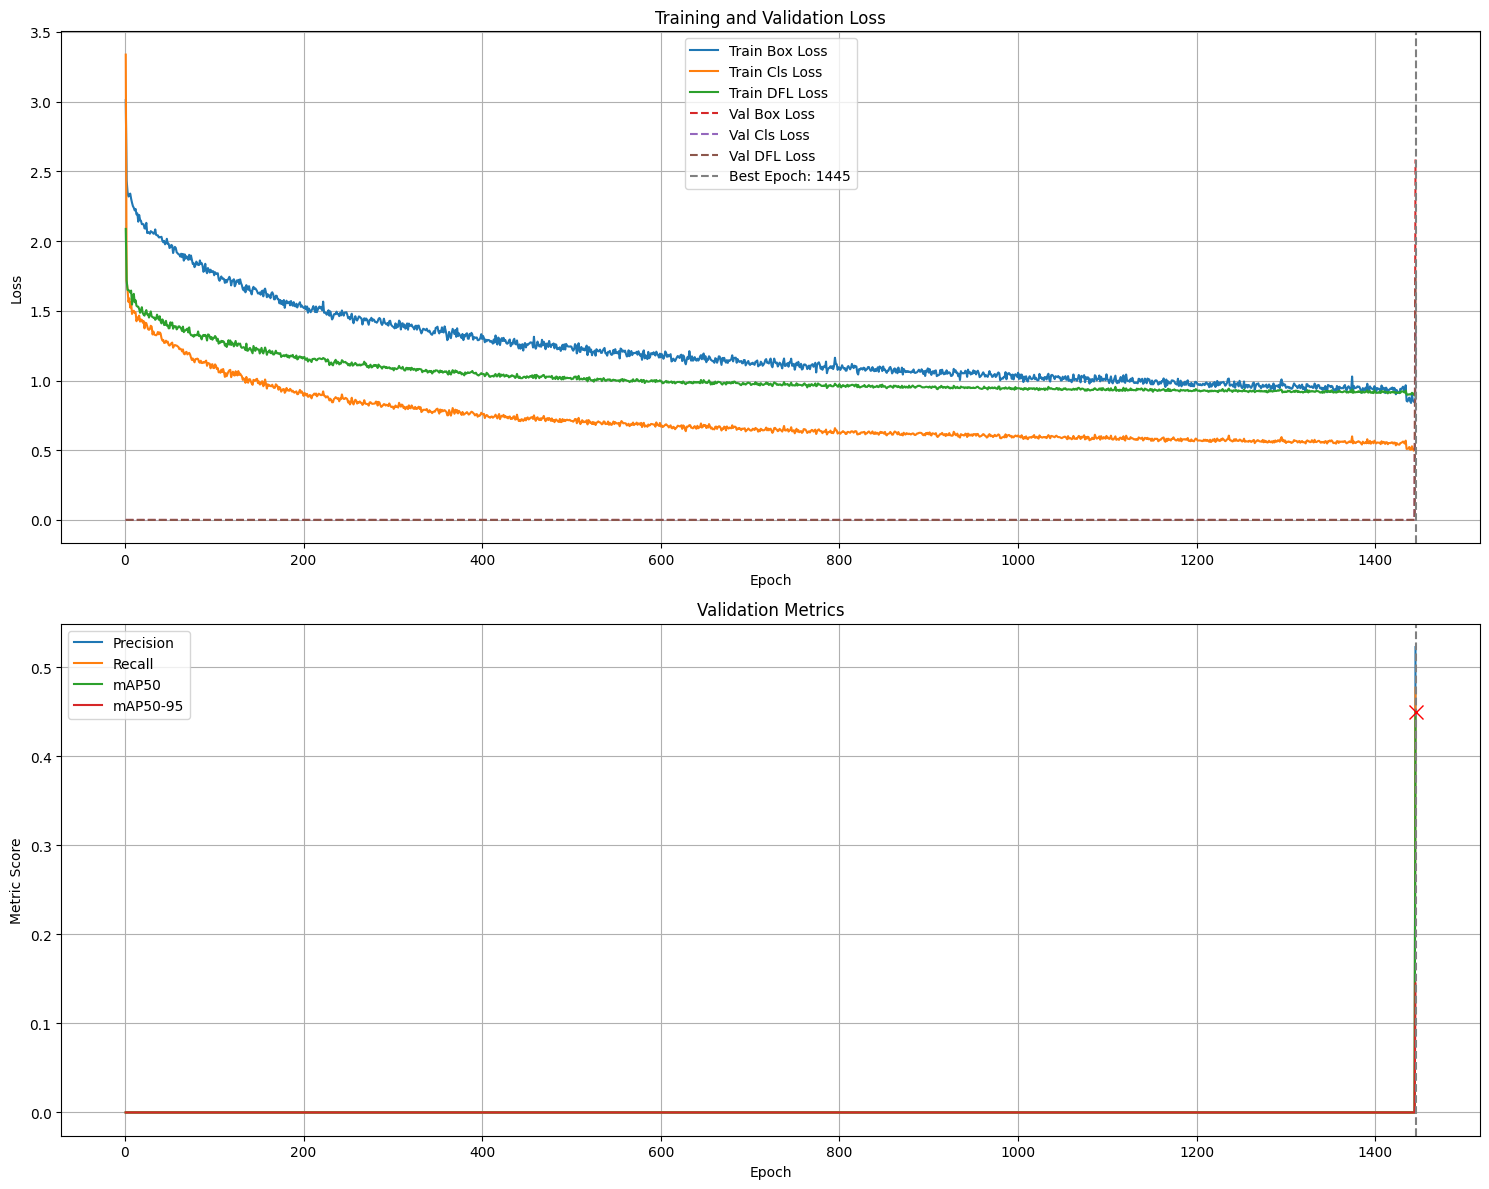

In [65]:
graph_training_metrics(df, epoch, graph="full")

In [66]:
graph_LrLoss_3D(df)

Validation set


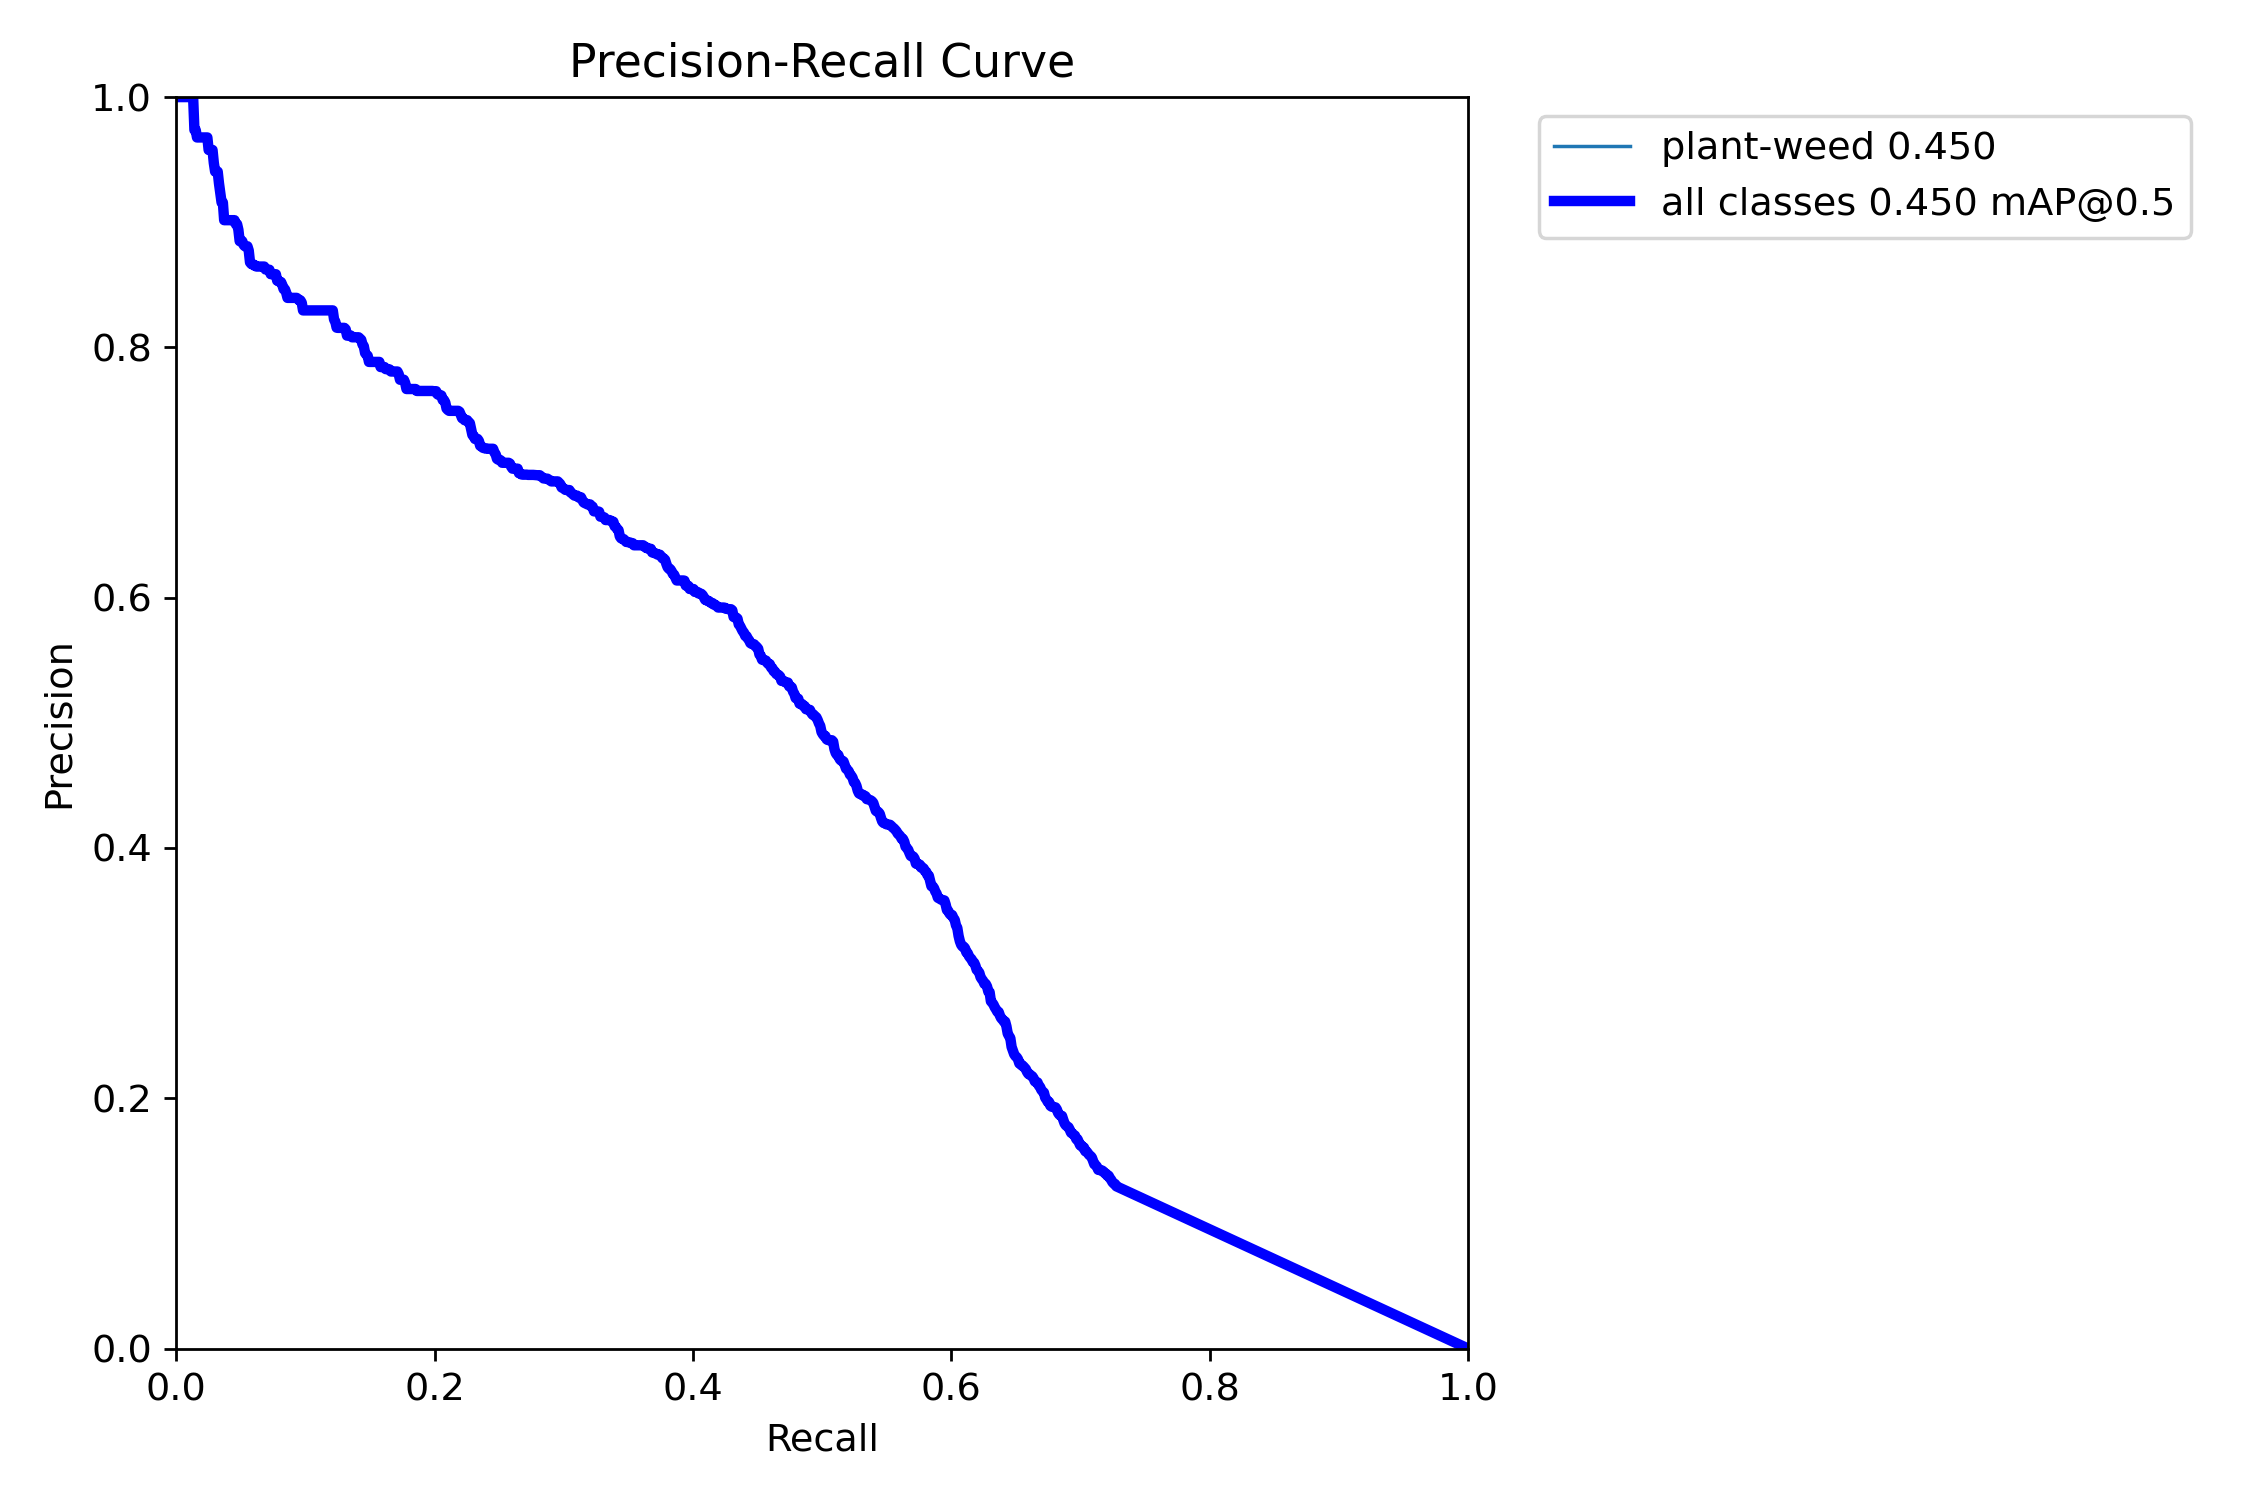

In [67]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

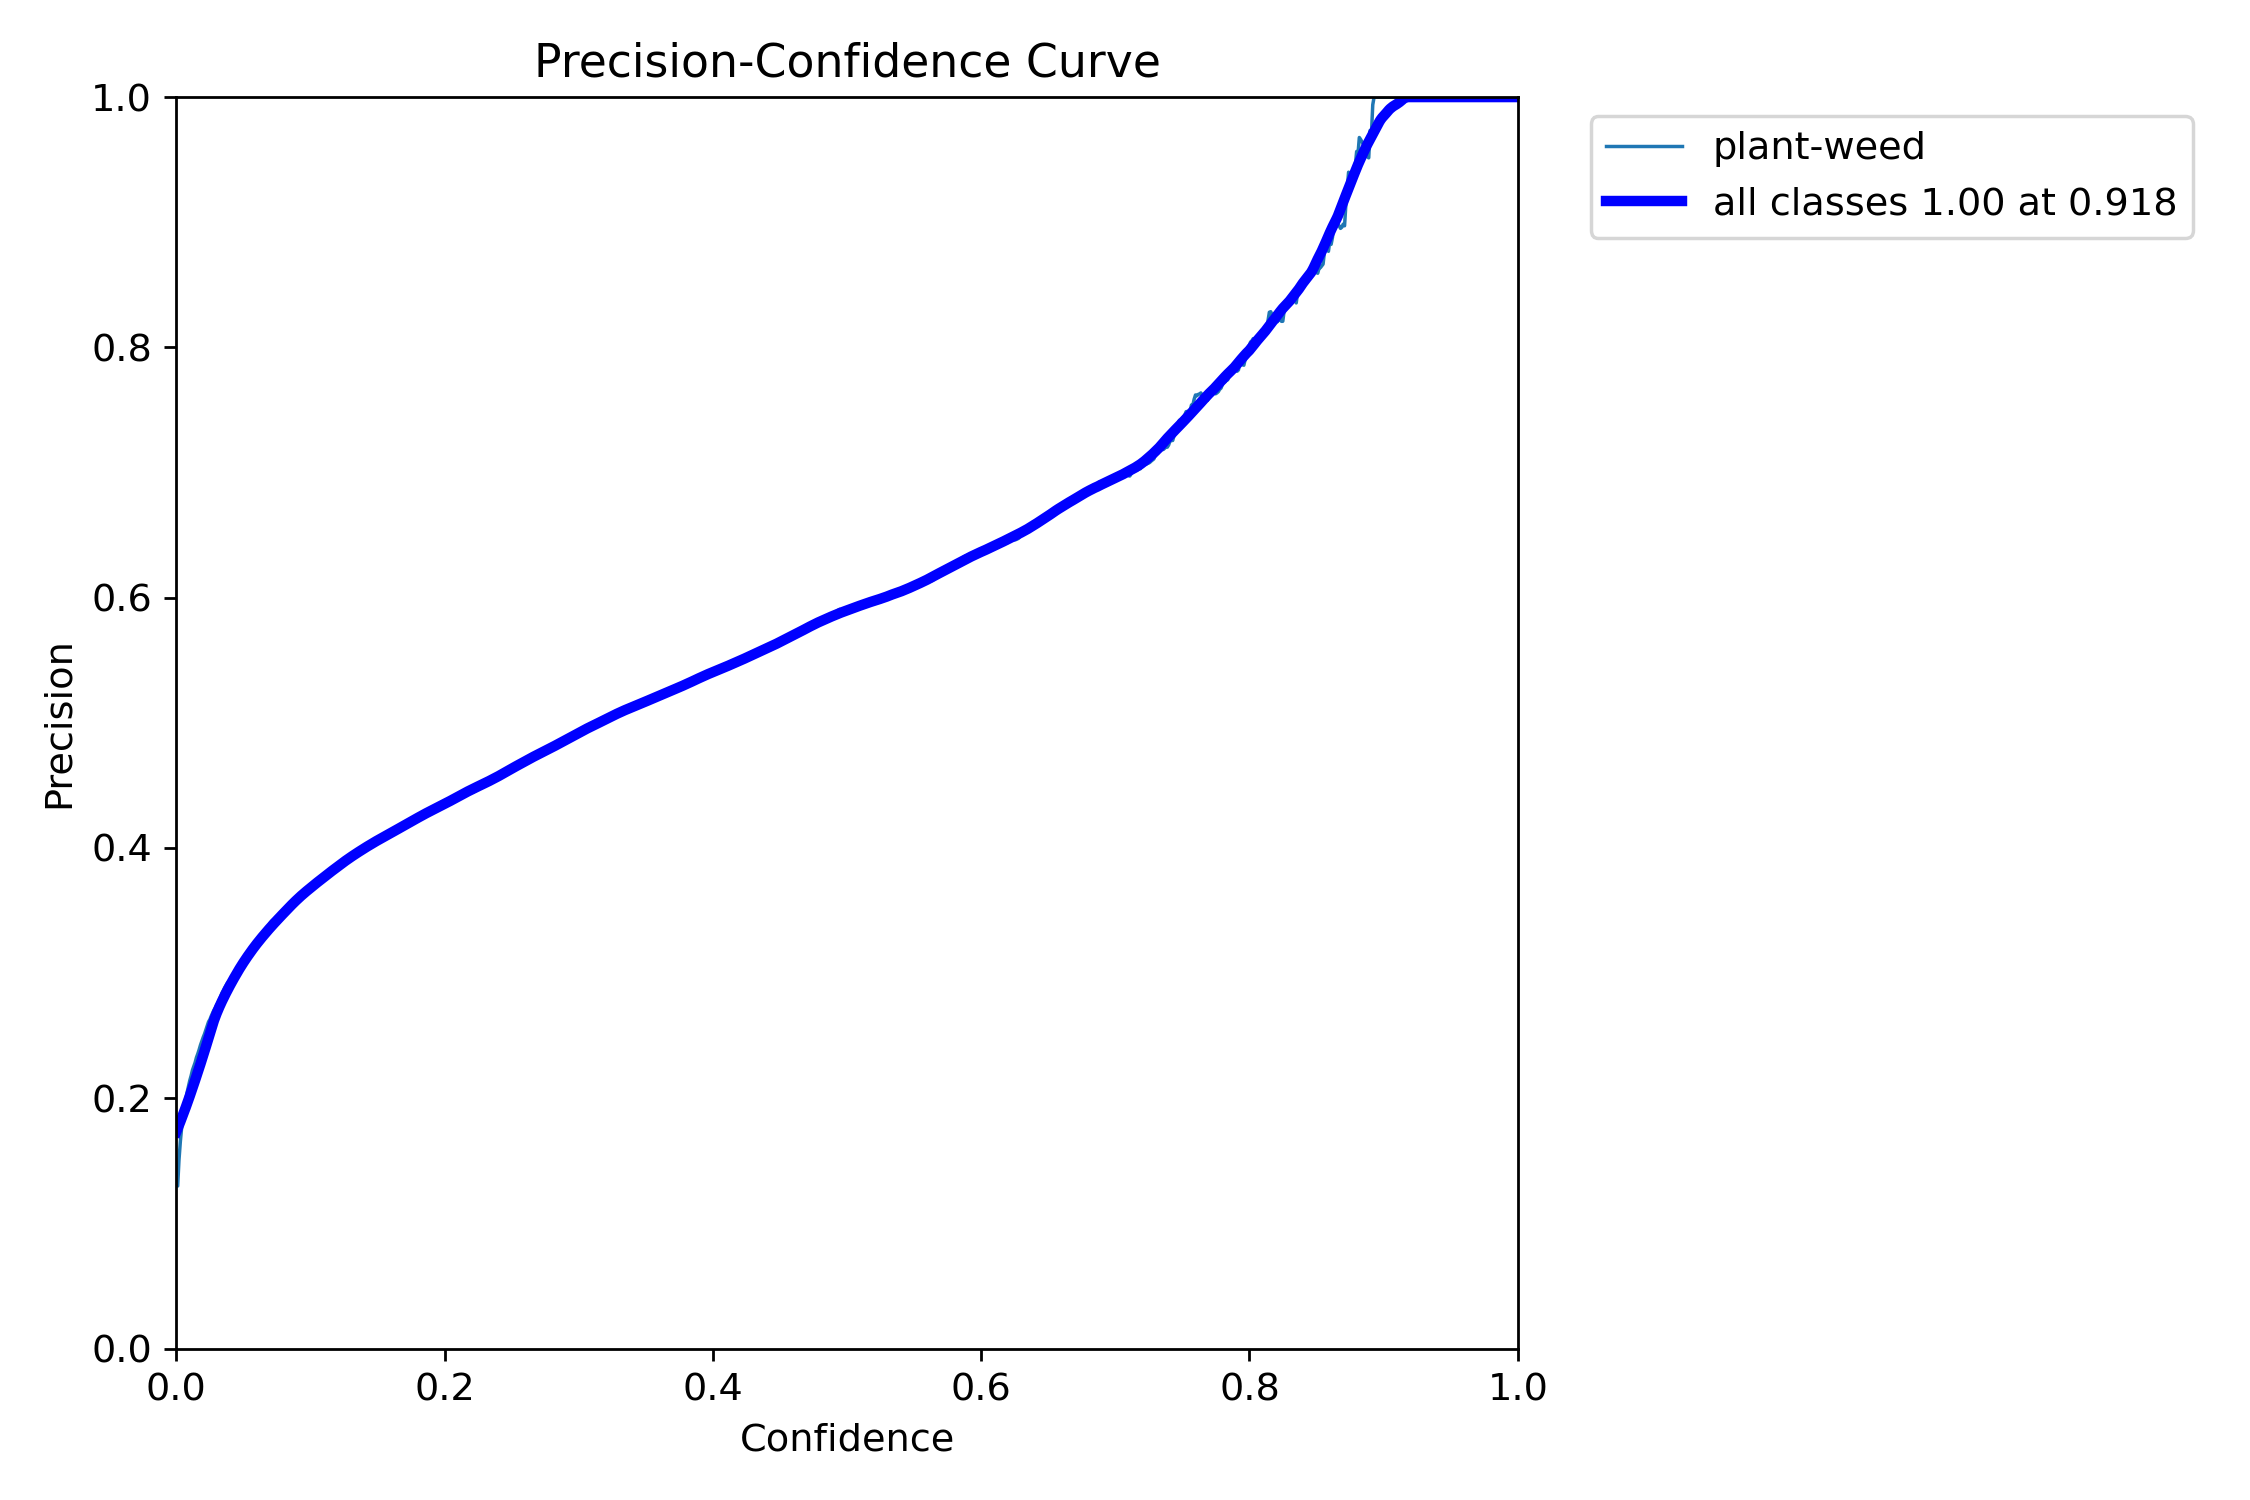

In [68]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

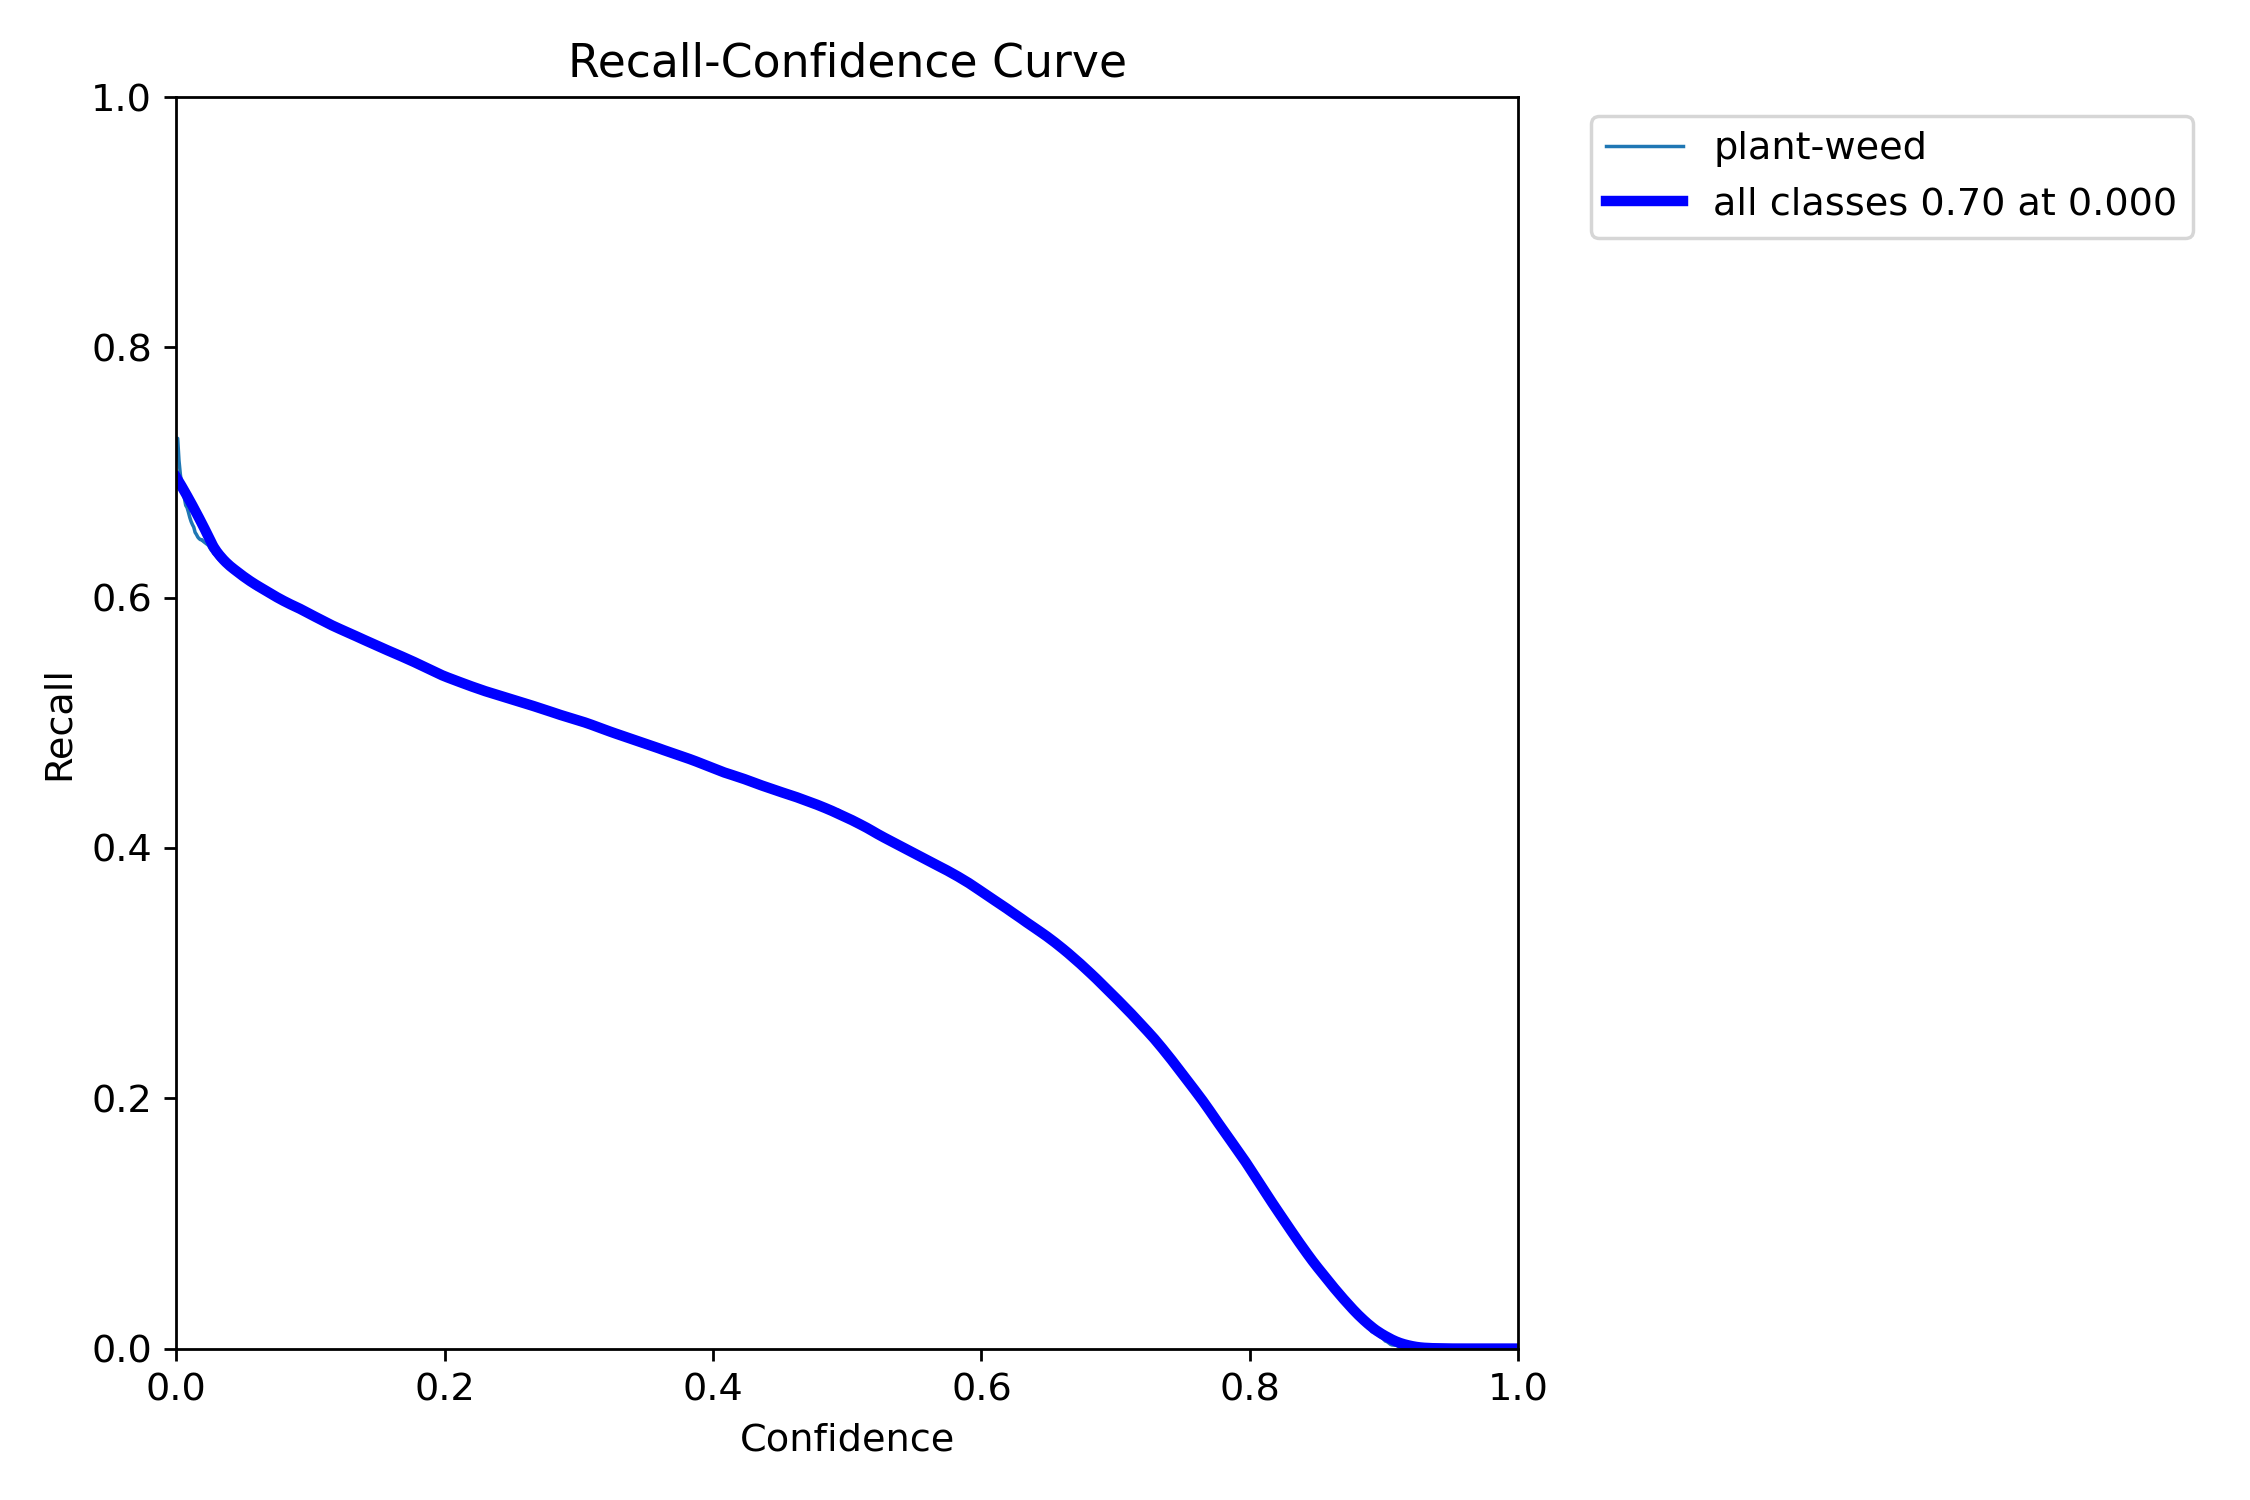

In [69]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

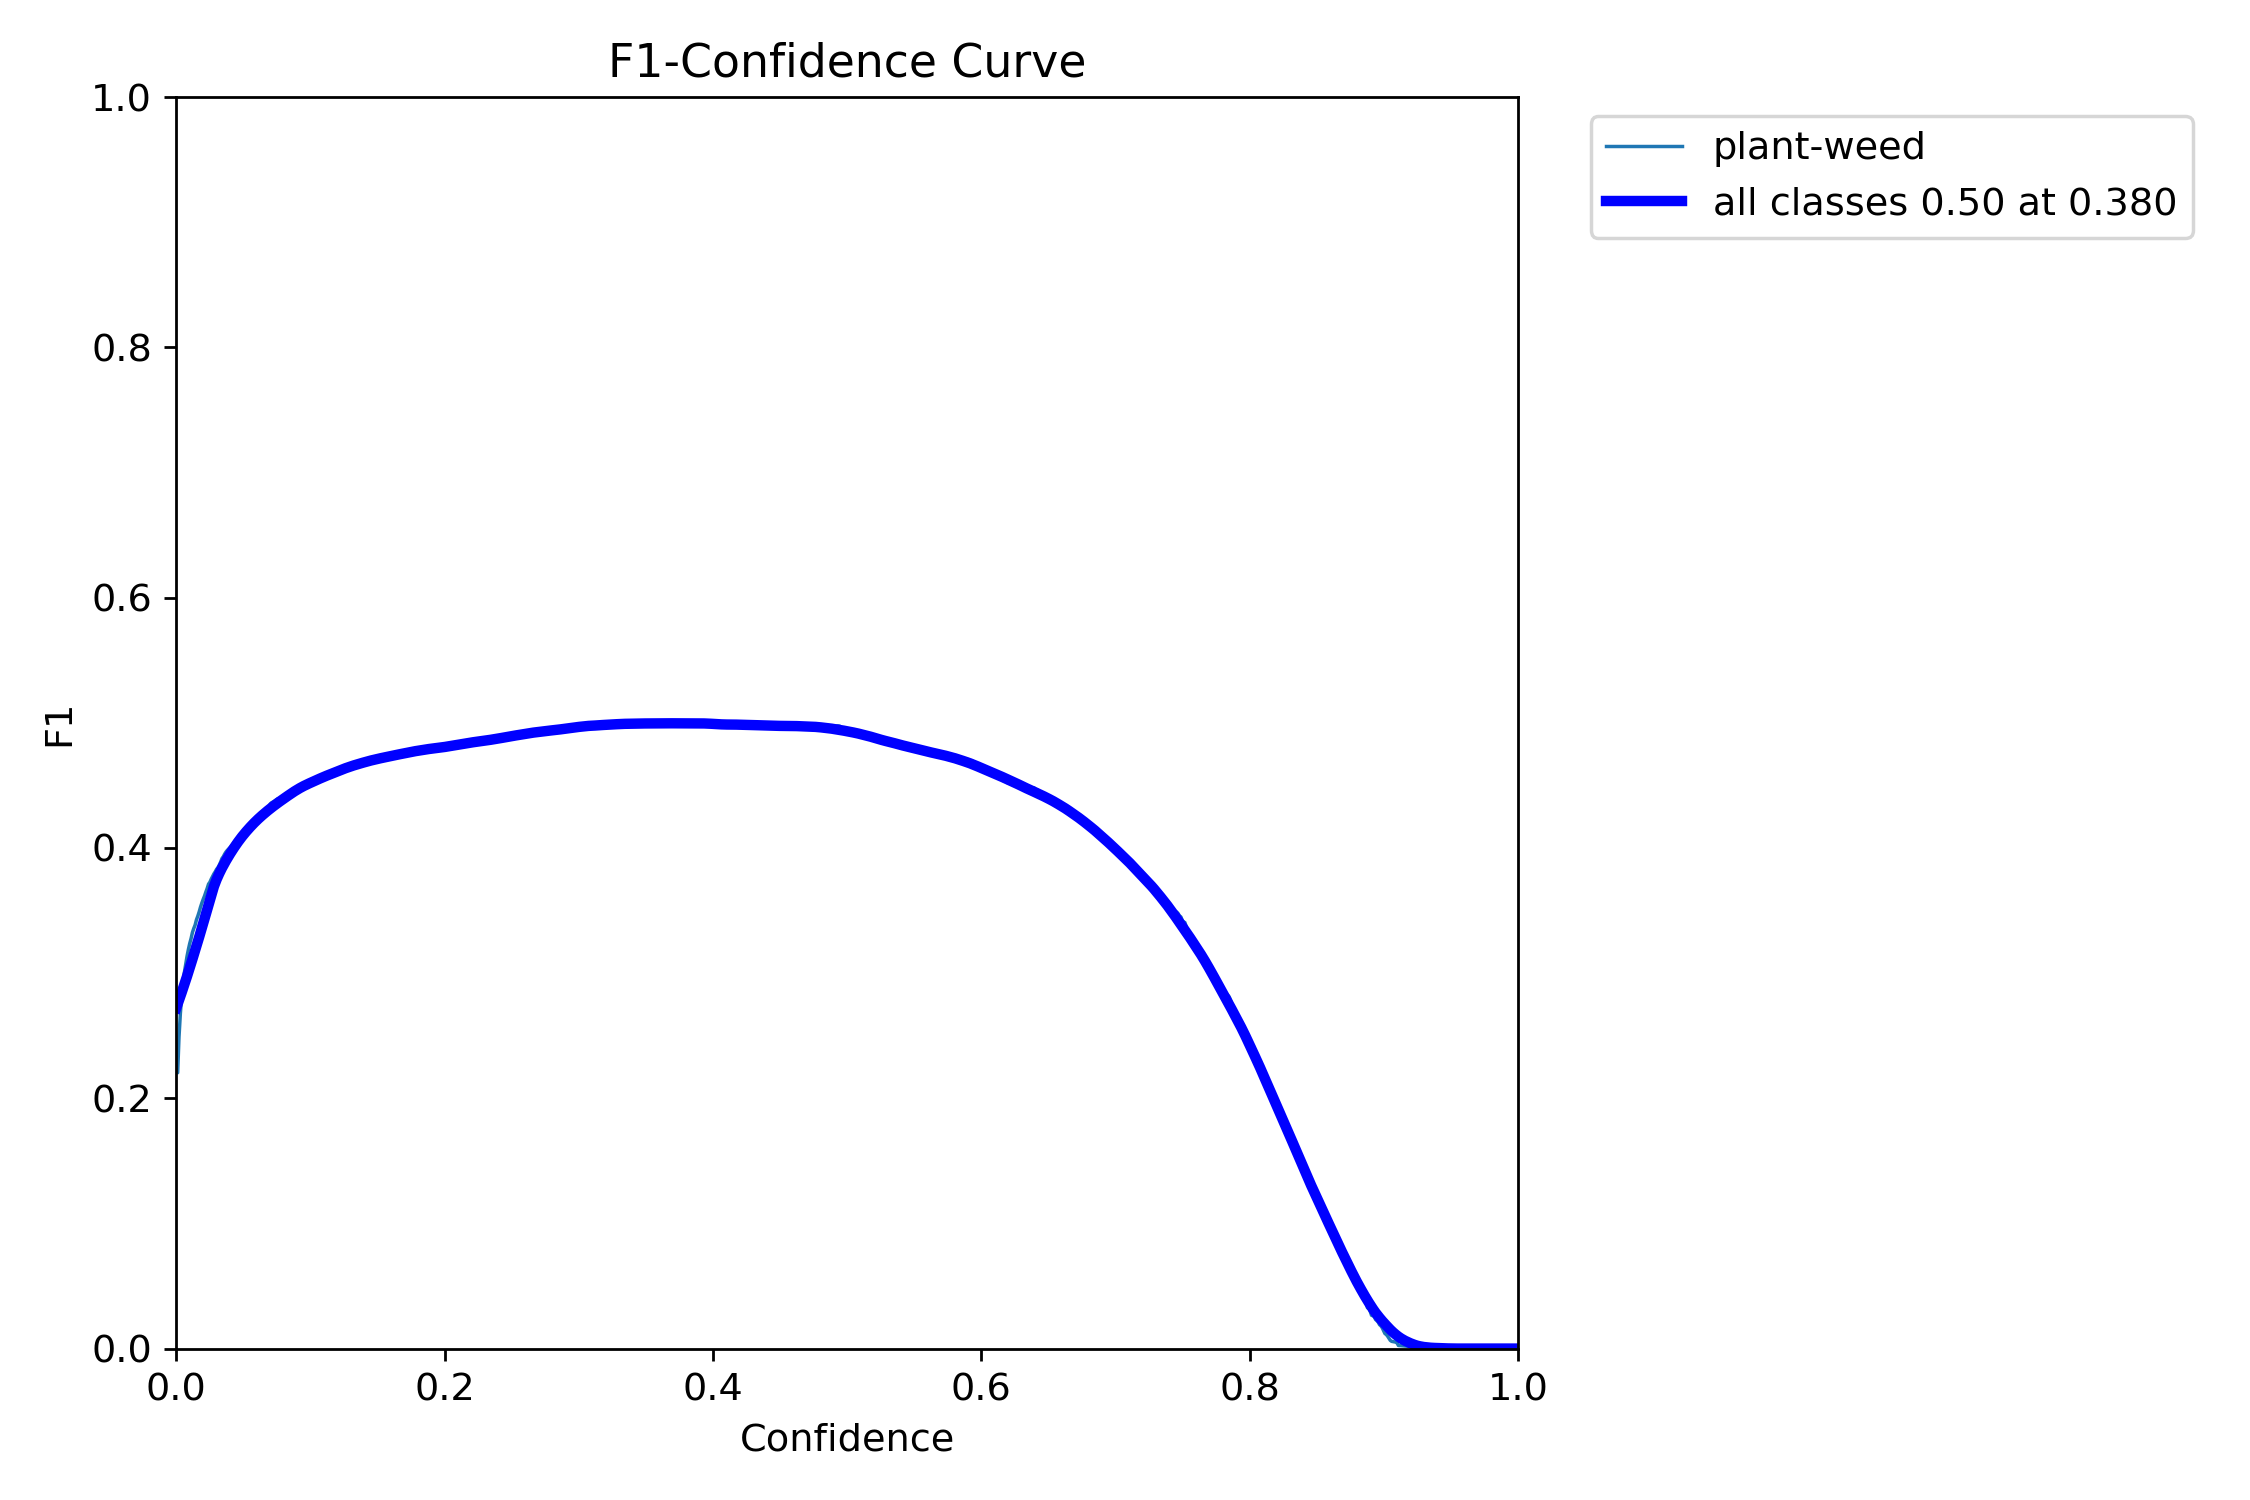

In [70]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# References

## Experiment 19
### *10 layers freezing | ~1000 epochs*
Every layer was initialized with pre-trained YOLOv8 weights and then freezed up to 10th layer and re-trained for ~1000 epochs

In [71]:
target_folder = f"docs/Experimentos/5 Model version/1 set/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/5 Model version/1 set


In [72]:
folder = "v8/detect/train/"

In [73]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df5 = pd.read_csv(file_path)
df = df5.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
385,386,2985.60,1.16564,0.64824,1.00079,0.51783,0.44915,0.42026,0.13158,2.71083,1.35703,1.74103,0.001238,0.001238,0.001238
386,387,2993.32,1.16003,0.64194,1.00164,0.49944,0.45828,0.41433,0.13166,2.68775,1.35982,1.71300,0.001236,0.001236,0.001236
387,388,3001.15,1.20936,0.66569,1.00235,0.51585,0.48194,0.43181,0.13696,2.64976,1.37377,1.70644,0.001234,0.001234,0.001234
388,389,3008.95,1.19211,0.66791,1.00913,0.51908,0.48609,0.42939,0.13653,2.62402,1.36774,1.70599,0.001232,0.001232,0.001232
389,390,3016.91,1.16665,0.65433,1.00045,0.52793,0.48187,0.43890,0.13979,2.61230,1.35686,1.70114,0.001230,0.001230,0.001230


In [74]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 50.282 min


#### Best epoch

In [75]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
360,361,2792.5,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


In [76]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 361 con mAP50 de 0.451


In [77]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [171]:
TP = 1374
FP = 1184
FN = 1035
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3593


In [172]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3824102421374896, 0.32952964096855, 0.2880601168939605)

### Graphs

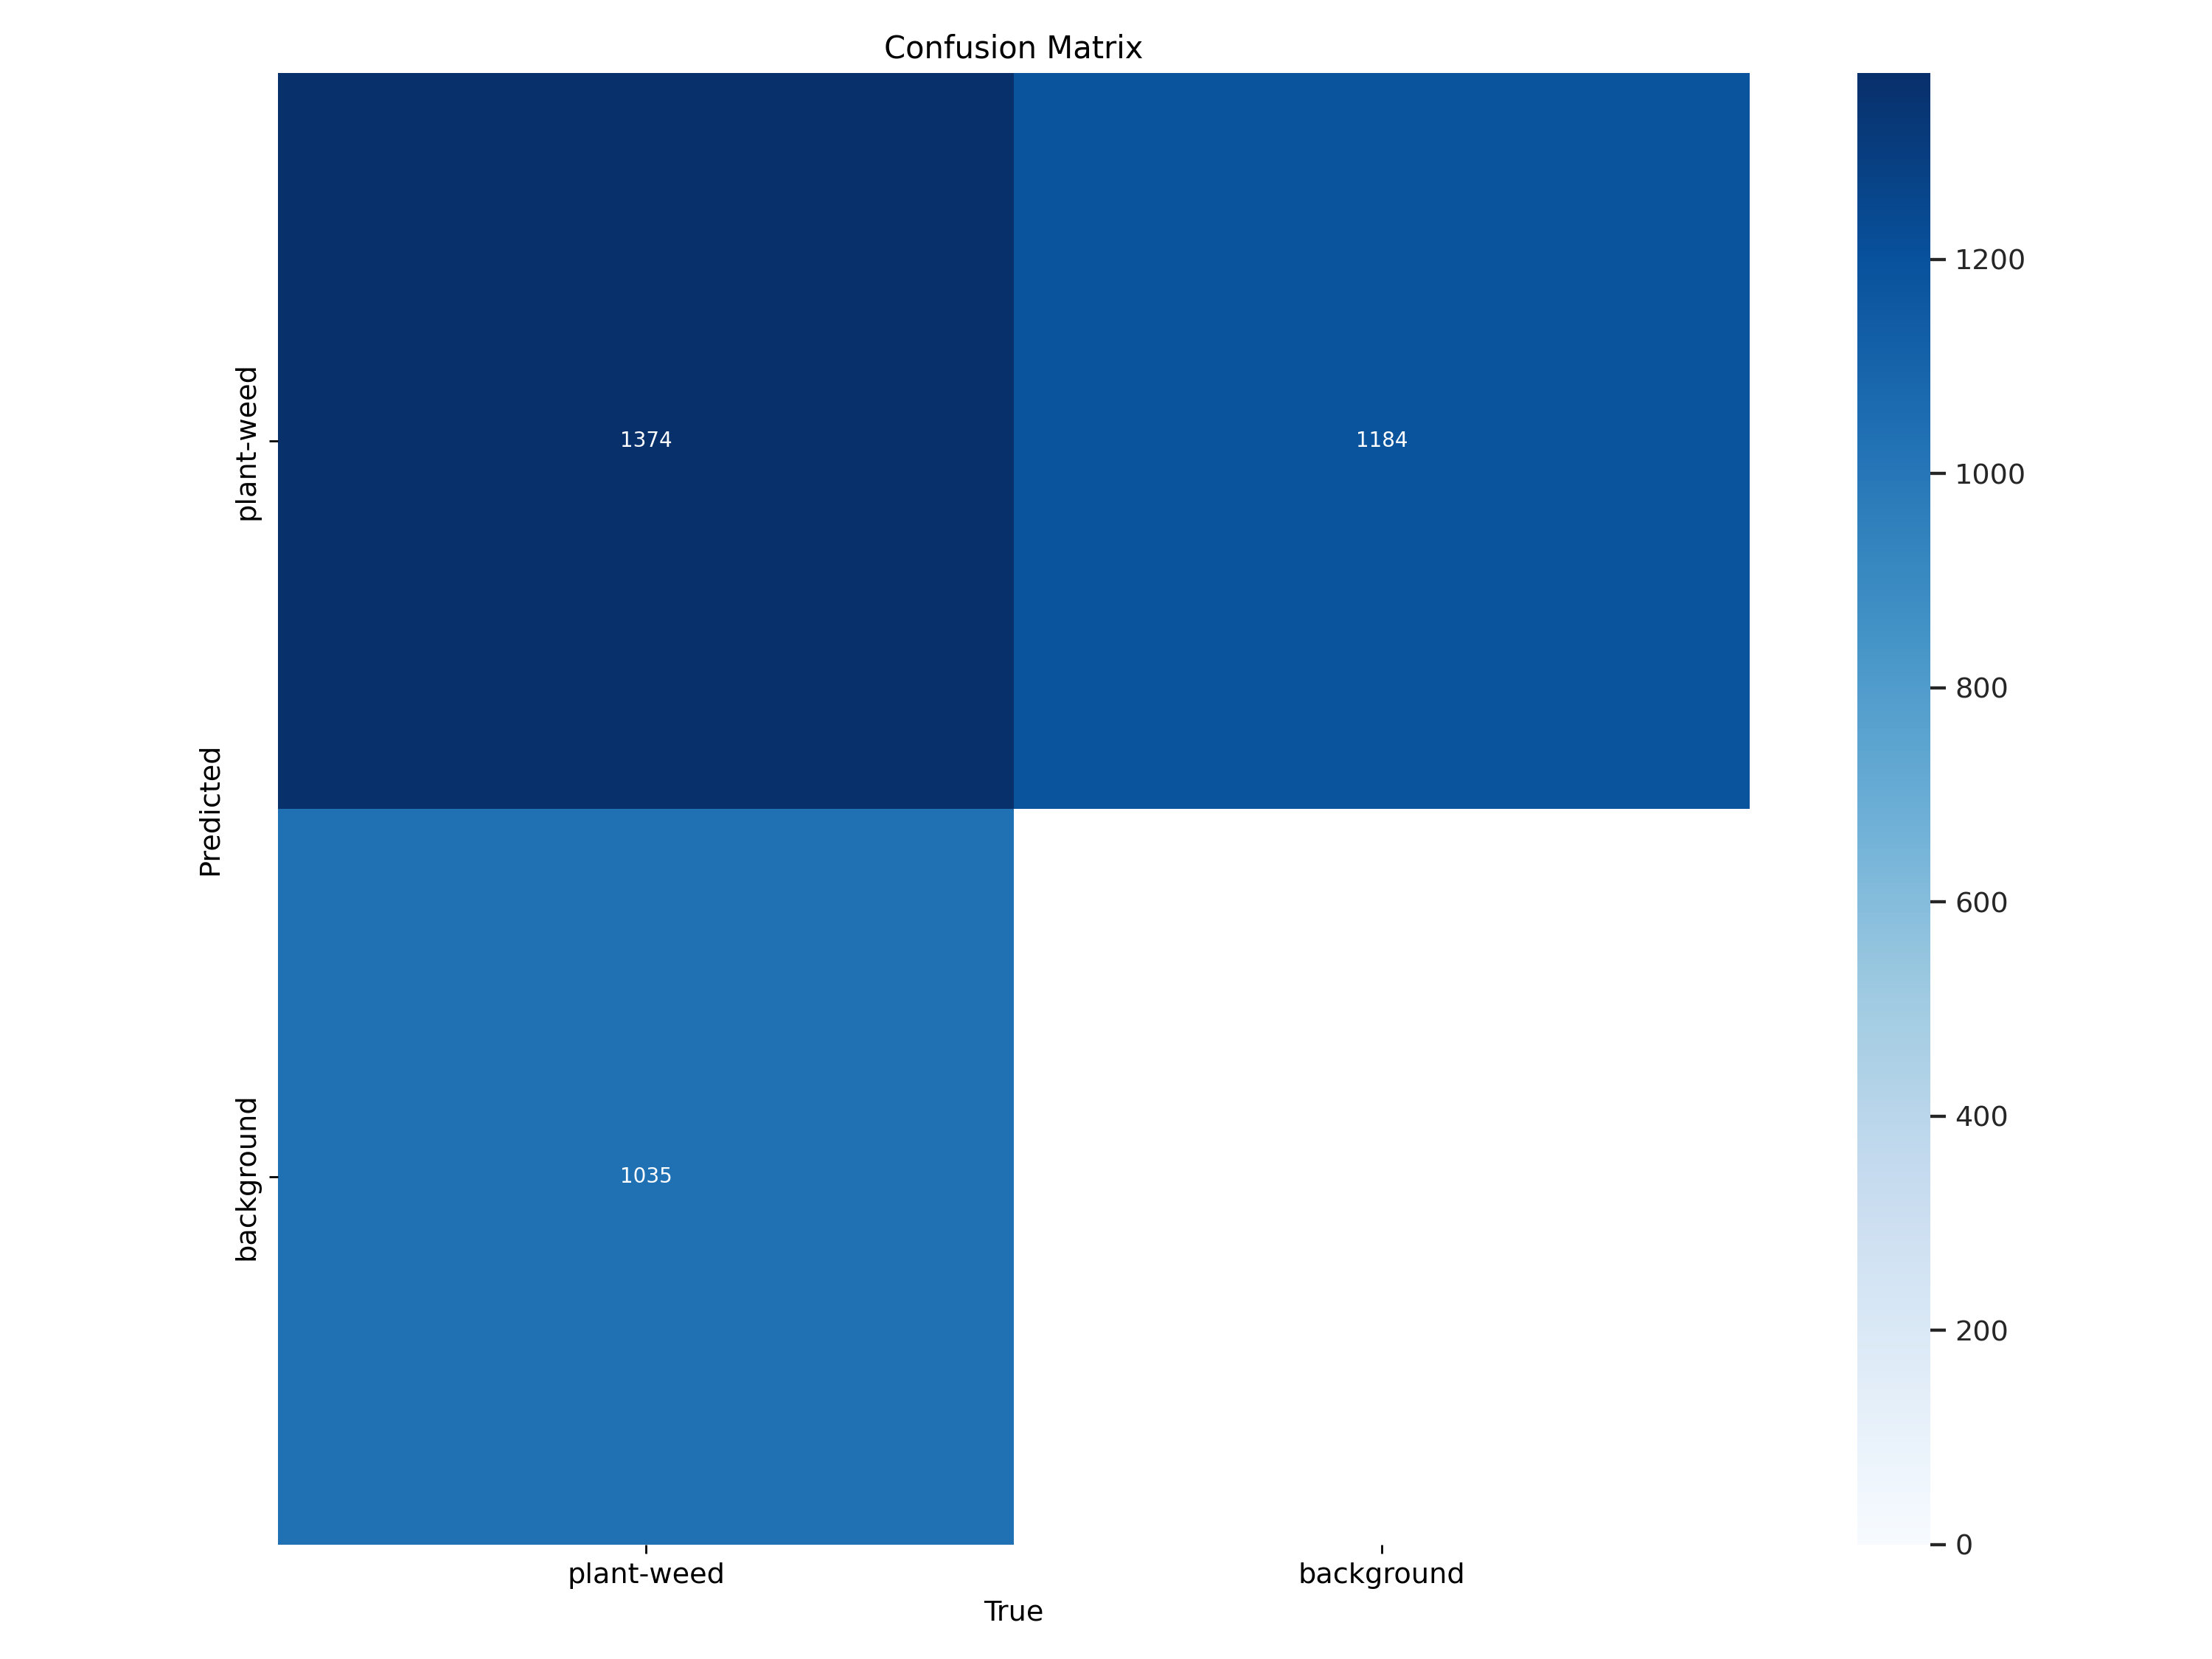

In [80]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

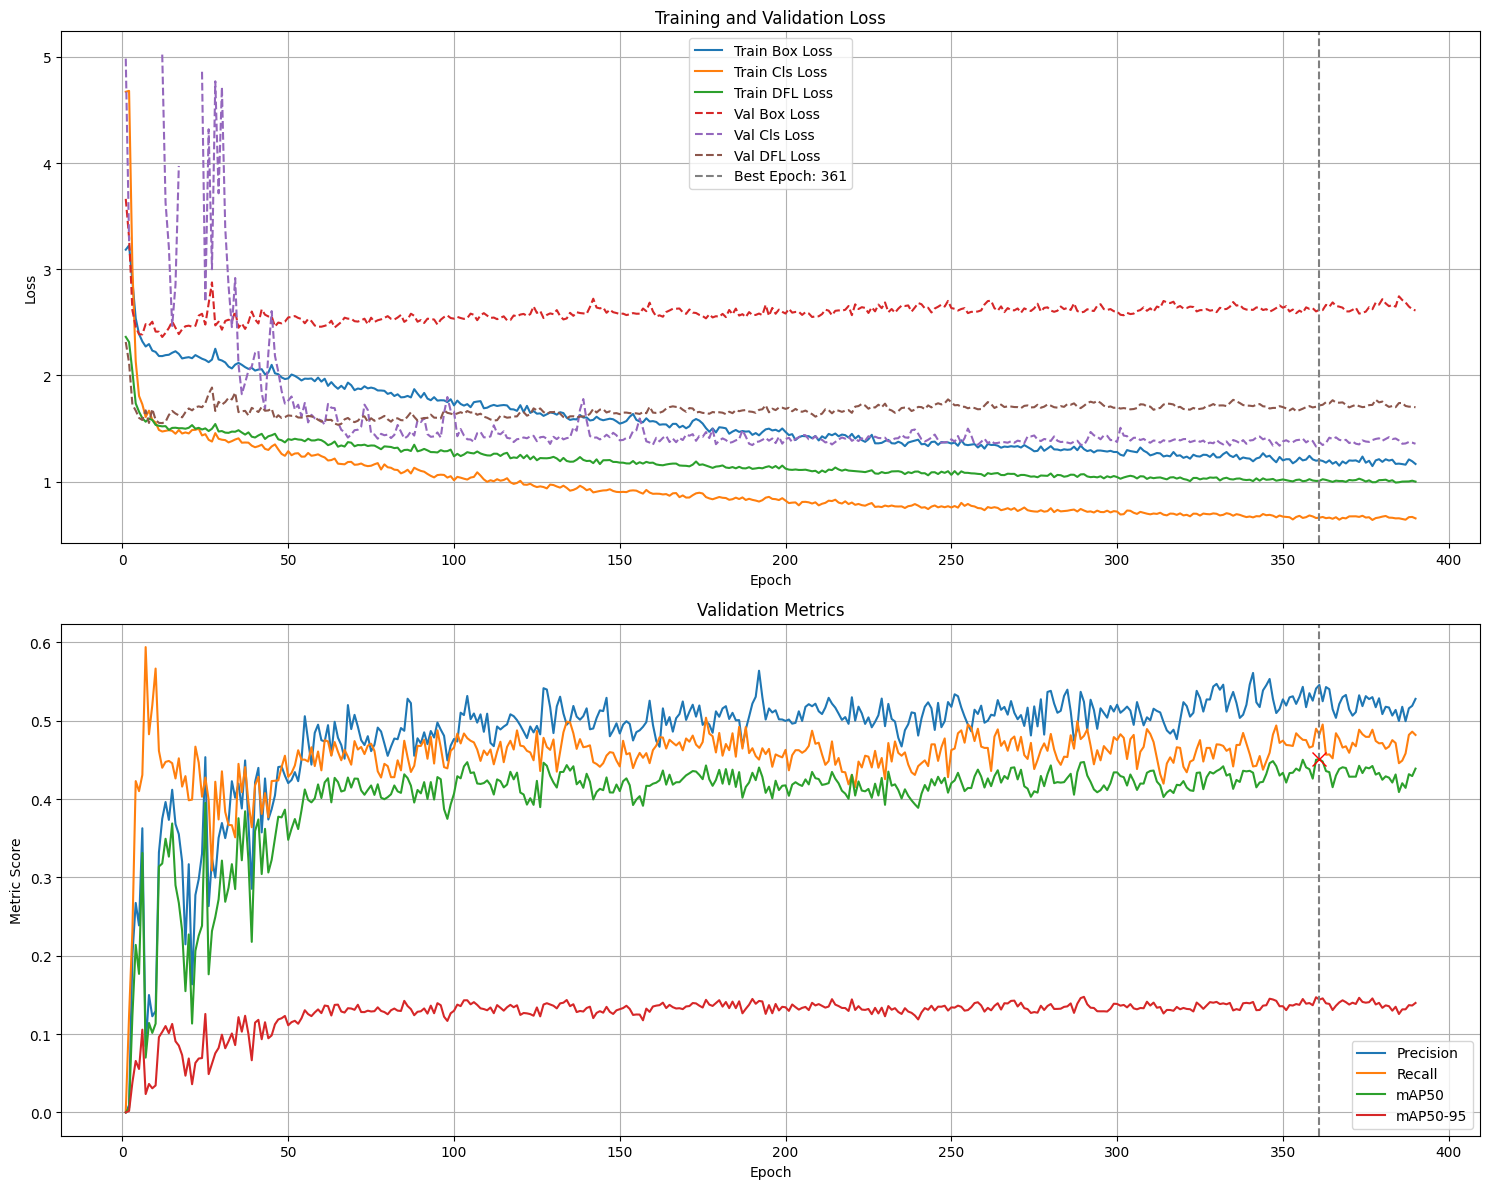

In [81]:
graph_training_metrics(df, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [82]:
graph_LrLoss_3D(df)

Validation set


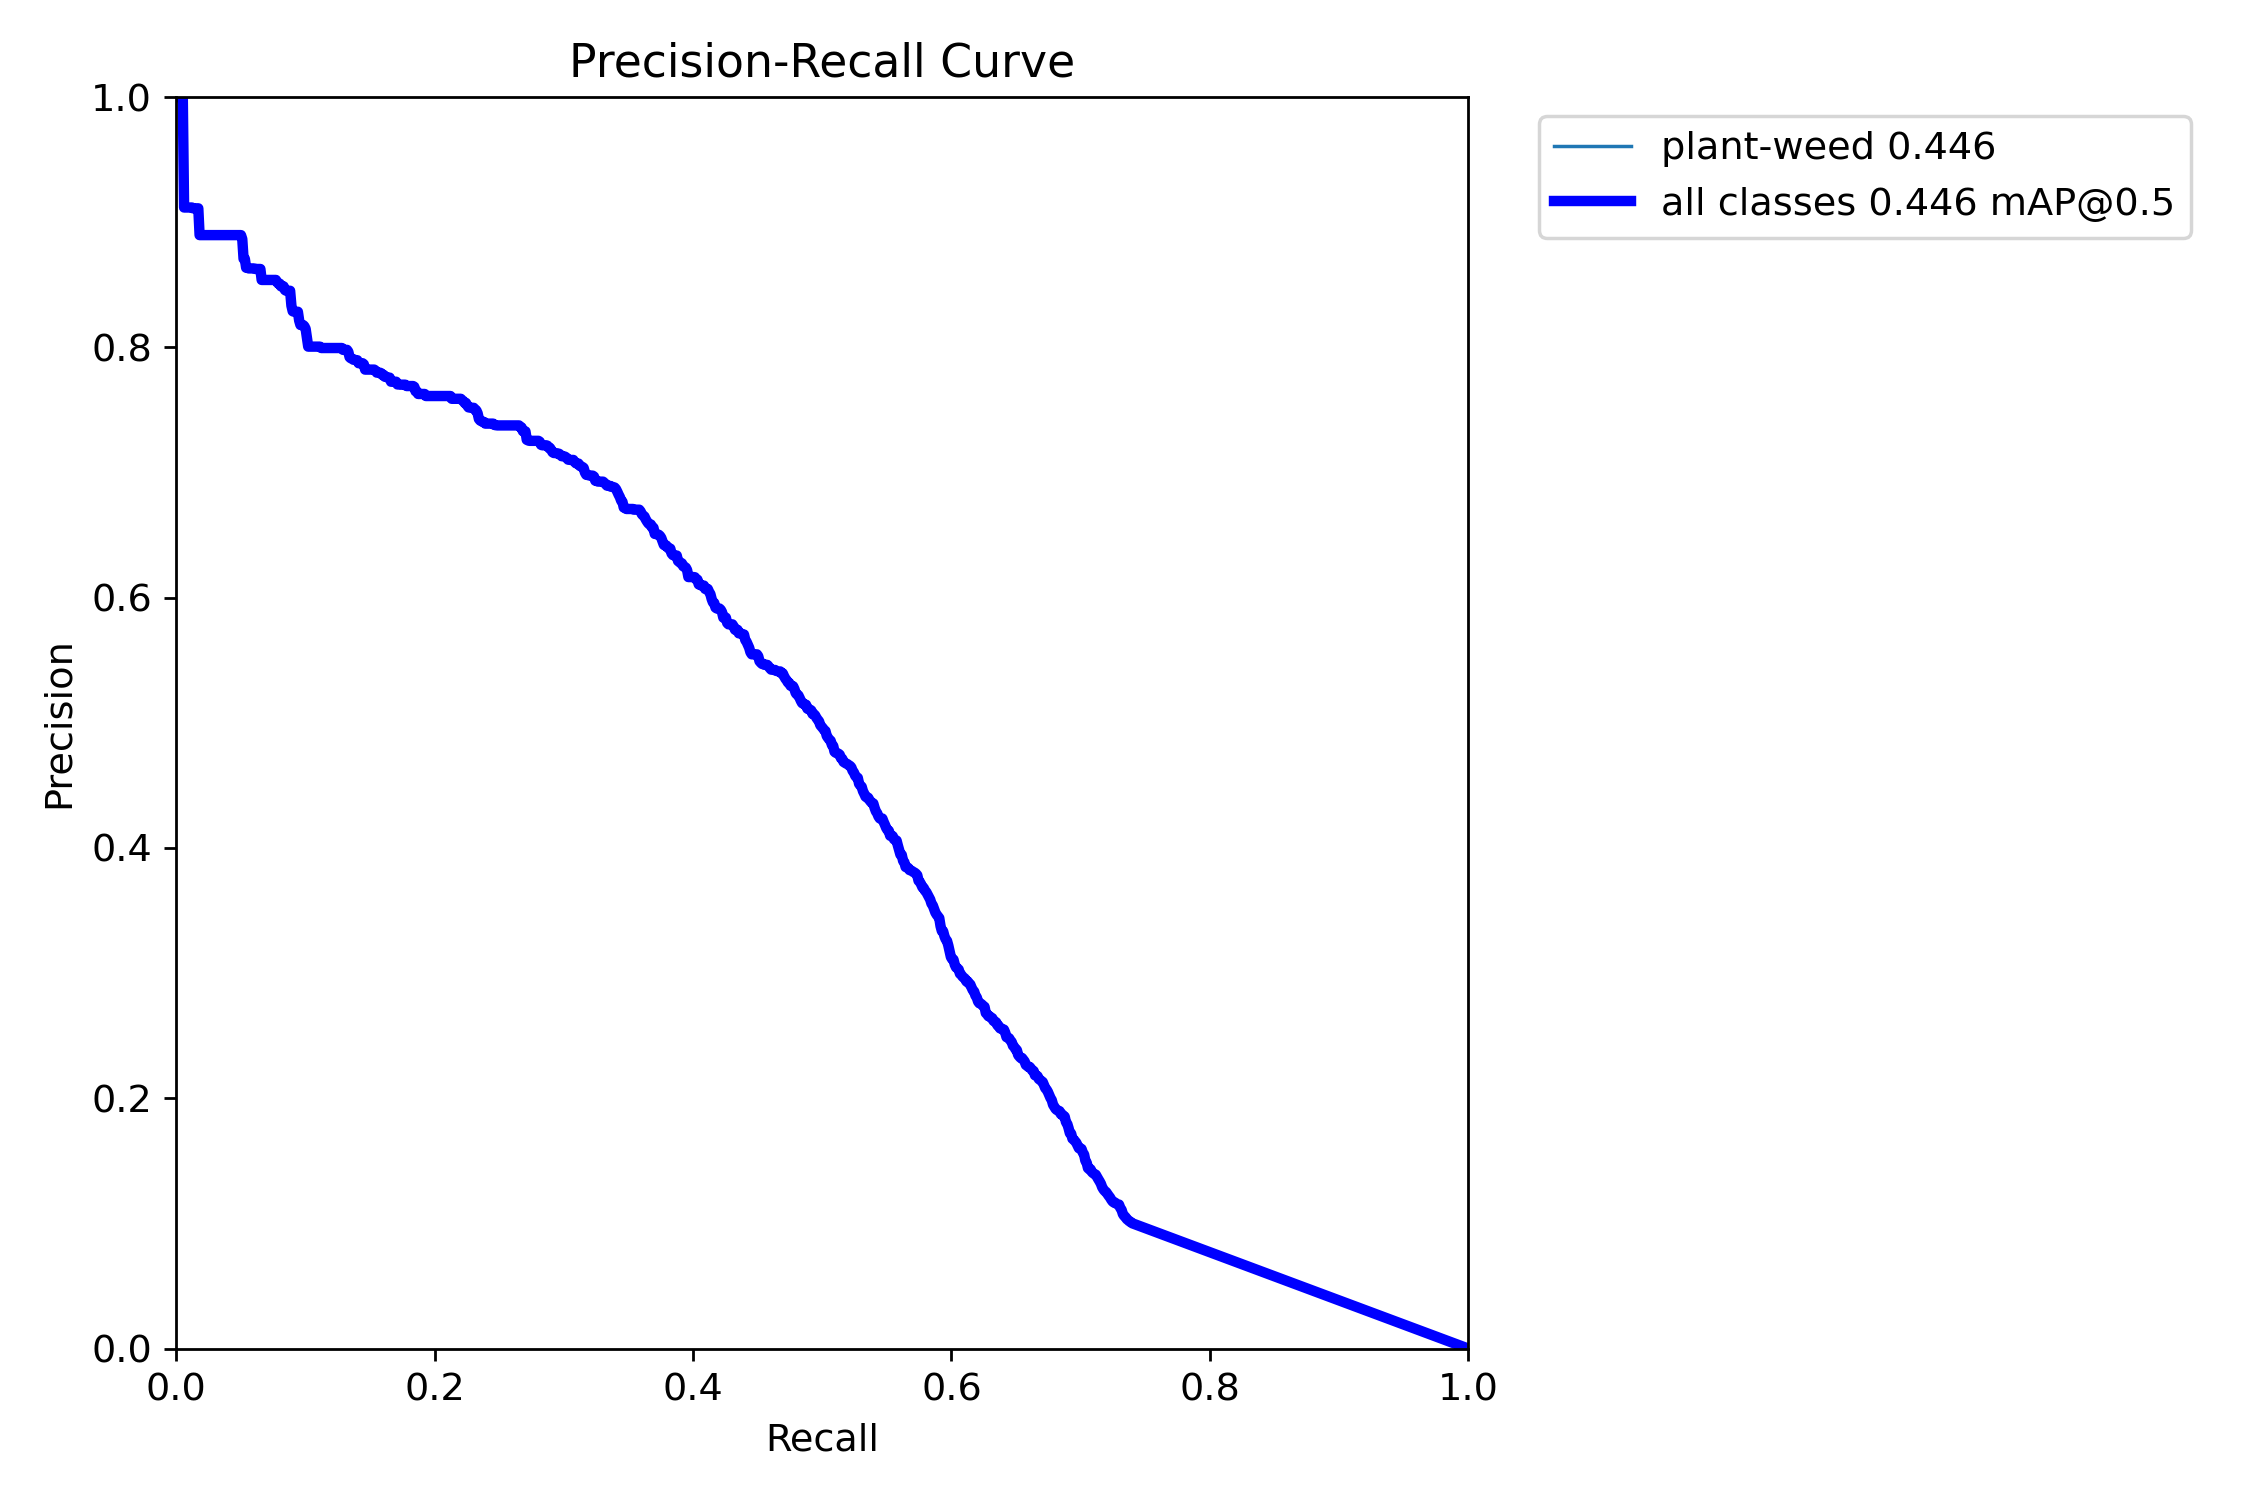

In [83]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

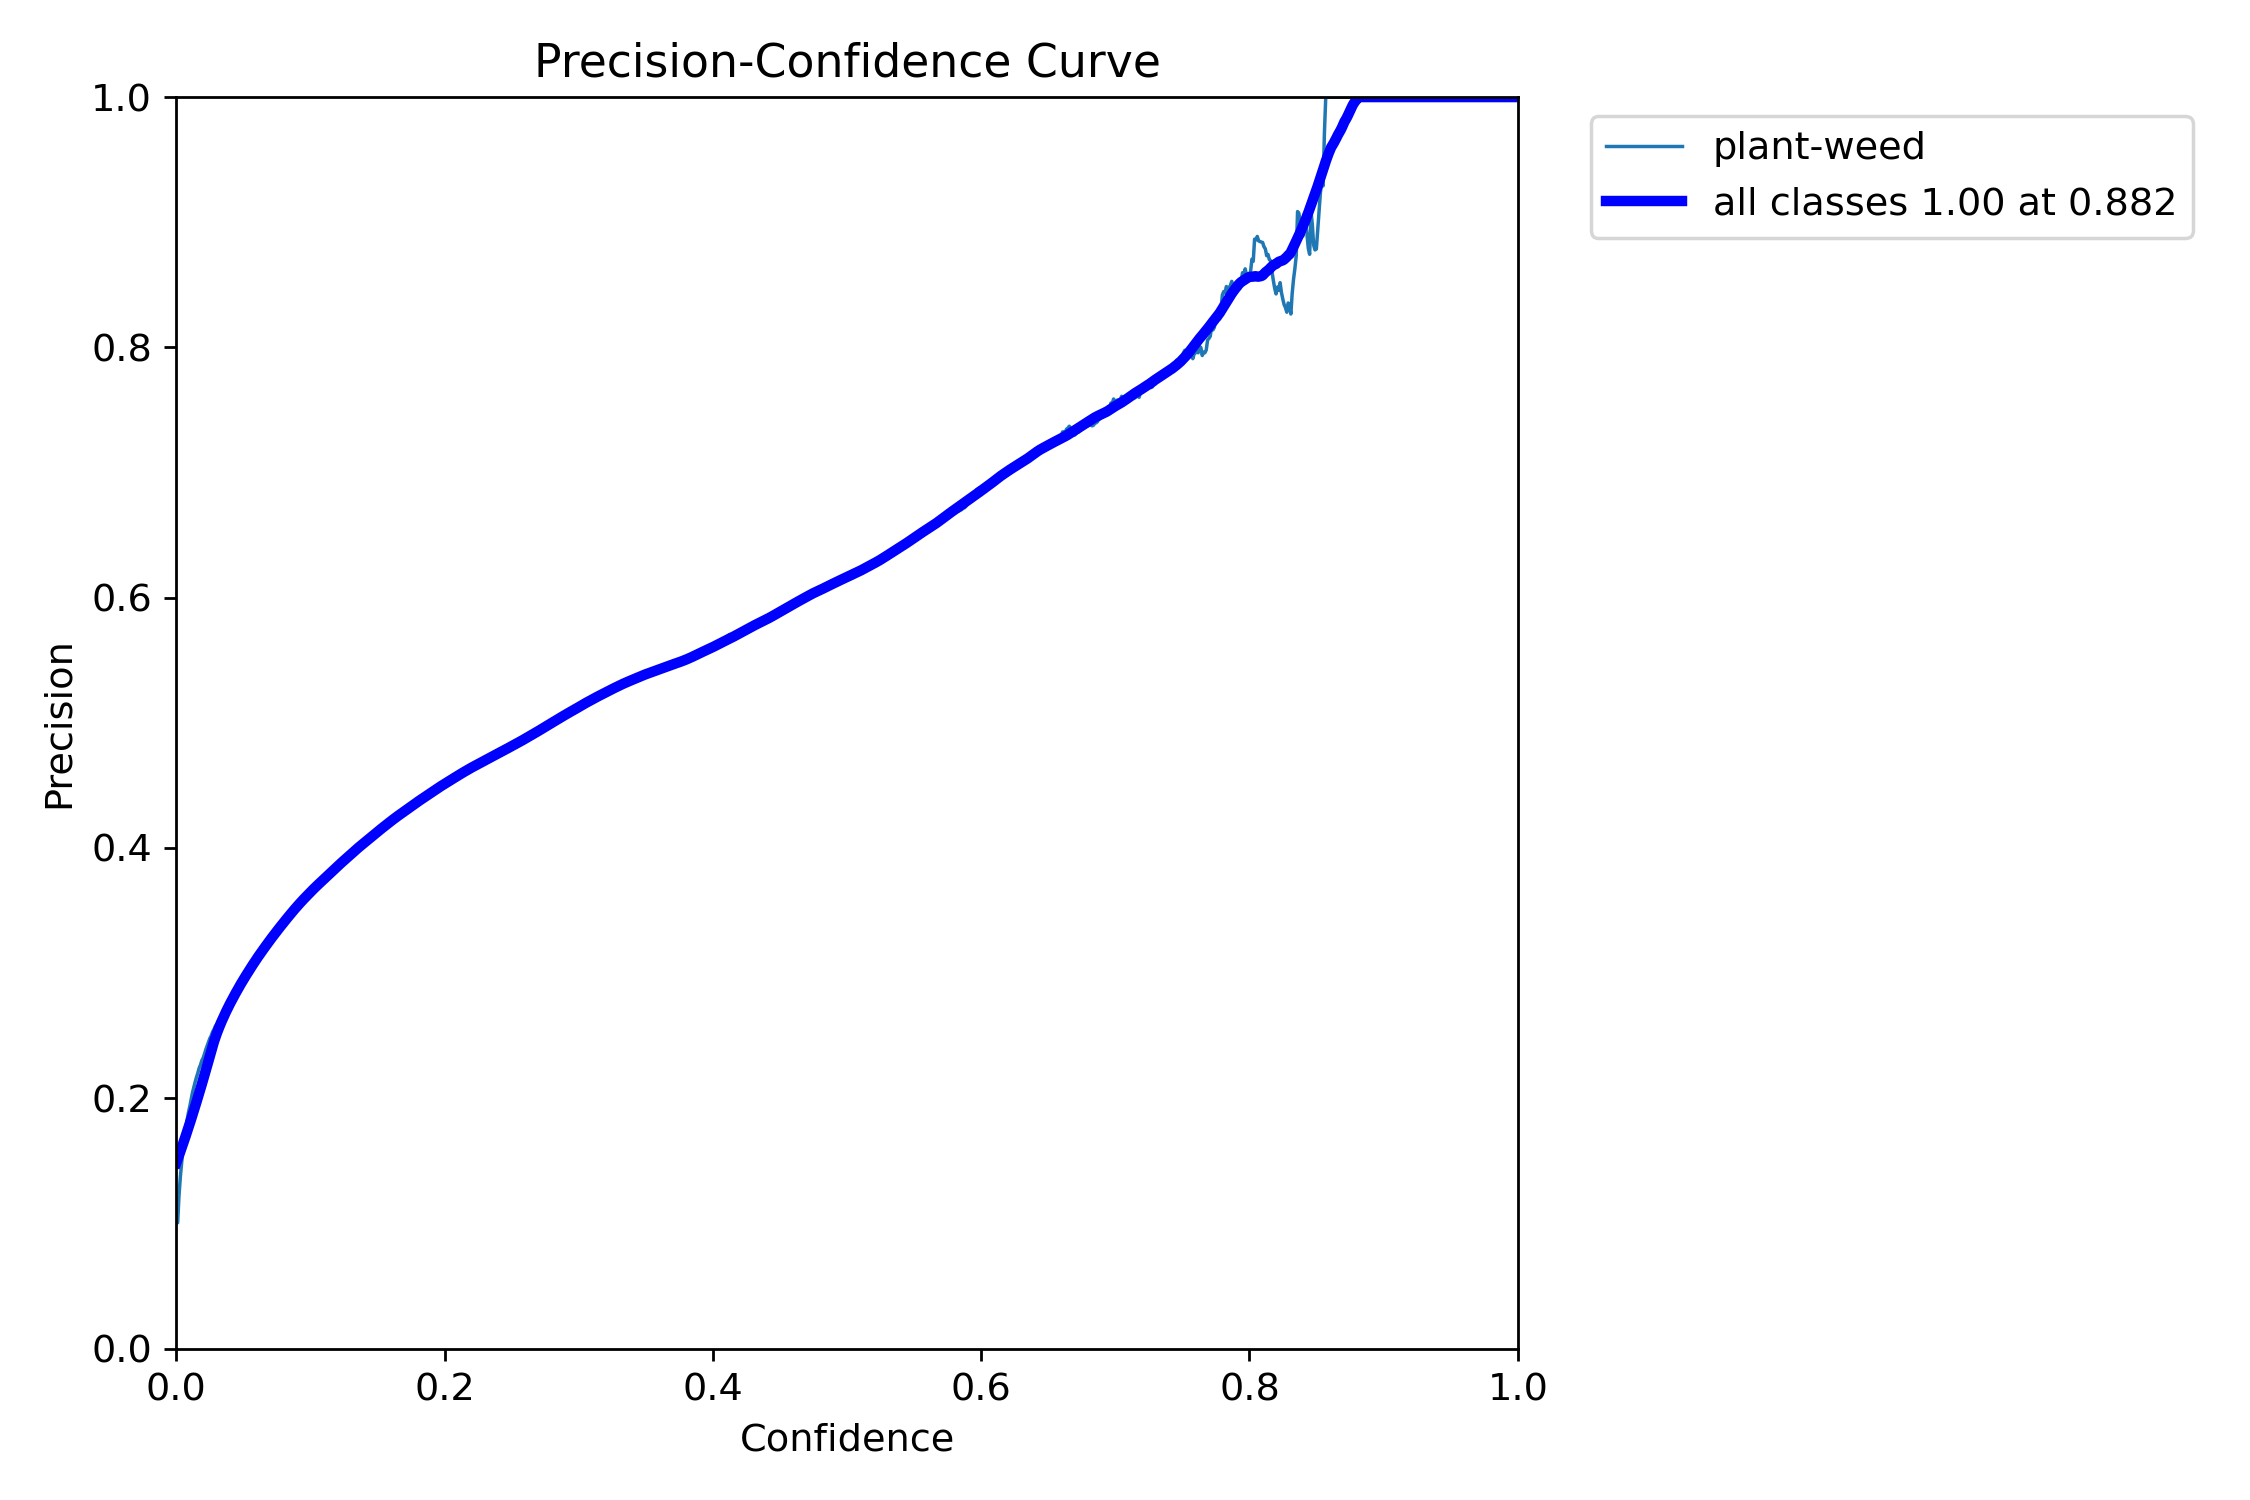

In [84]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

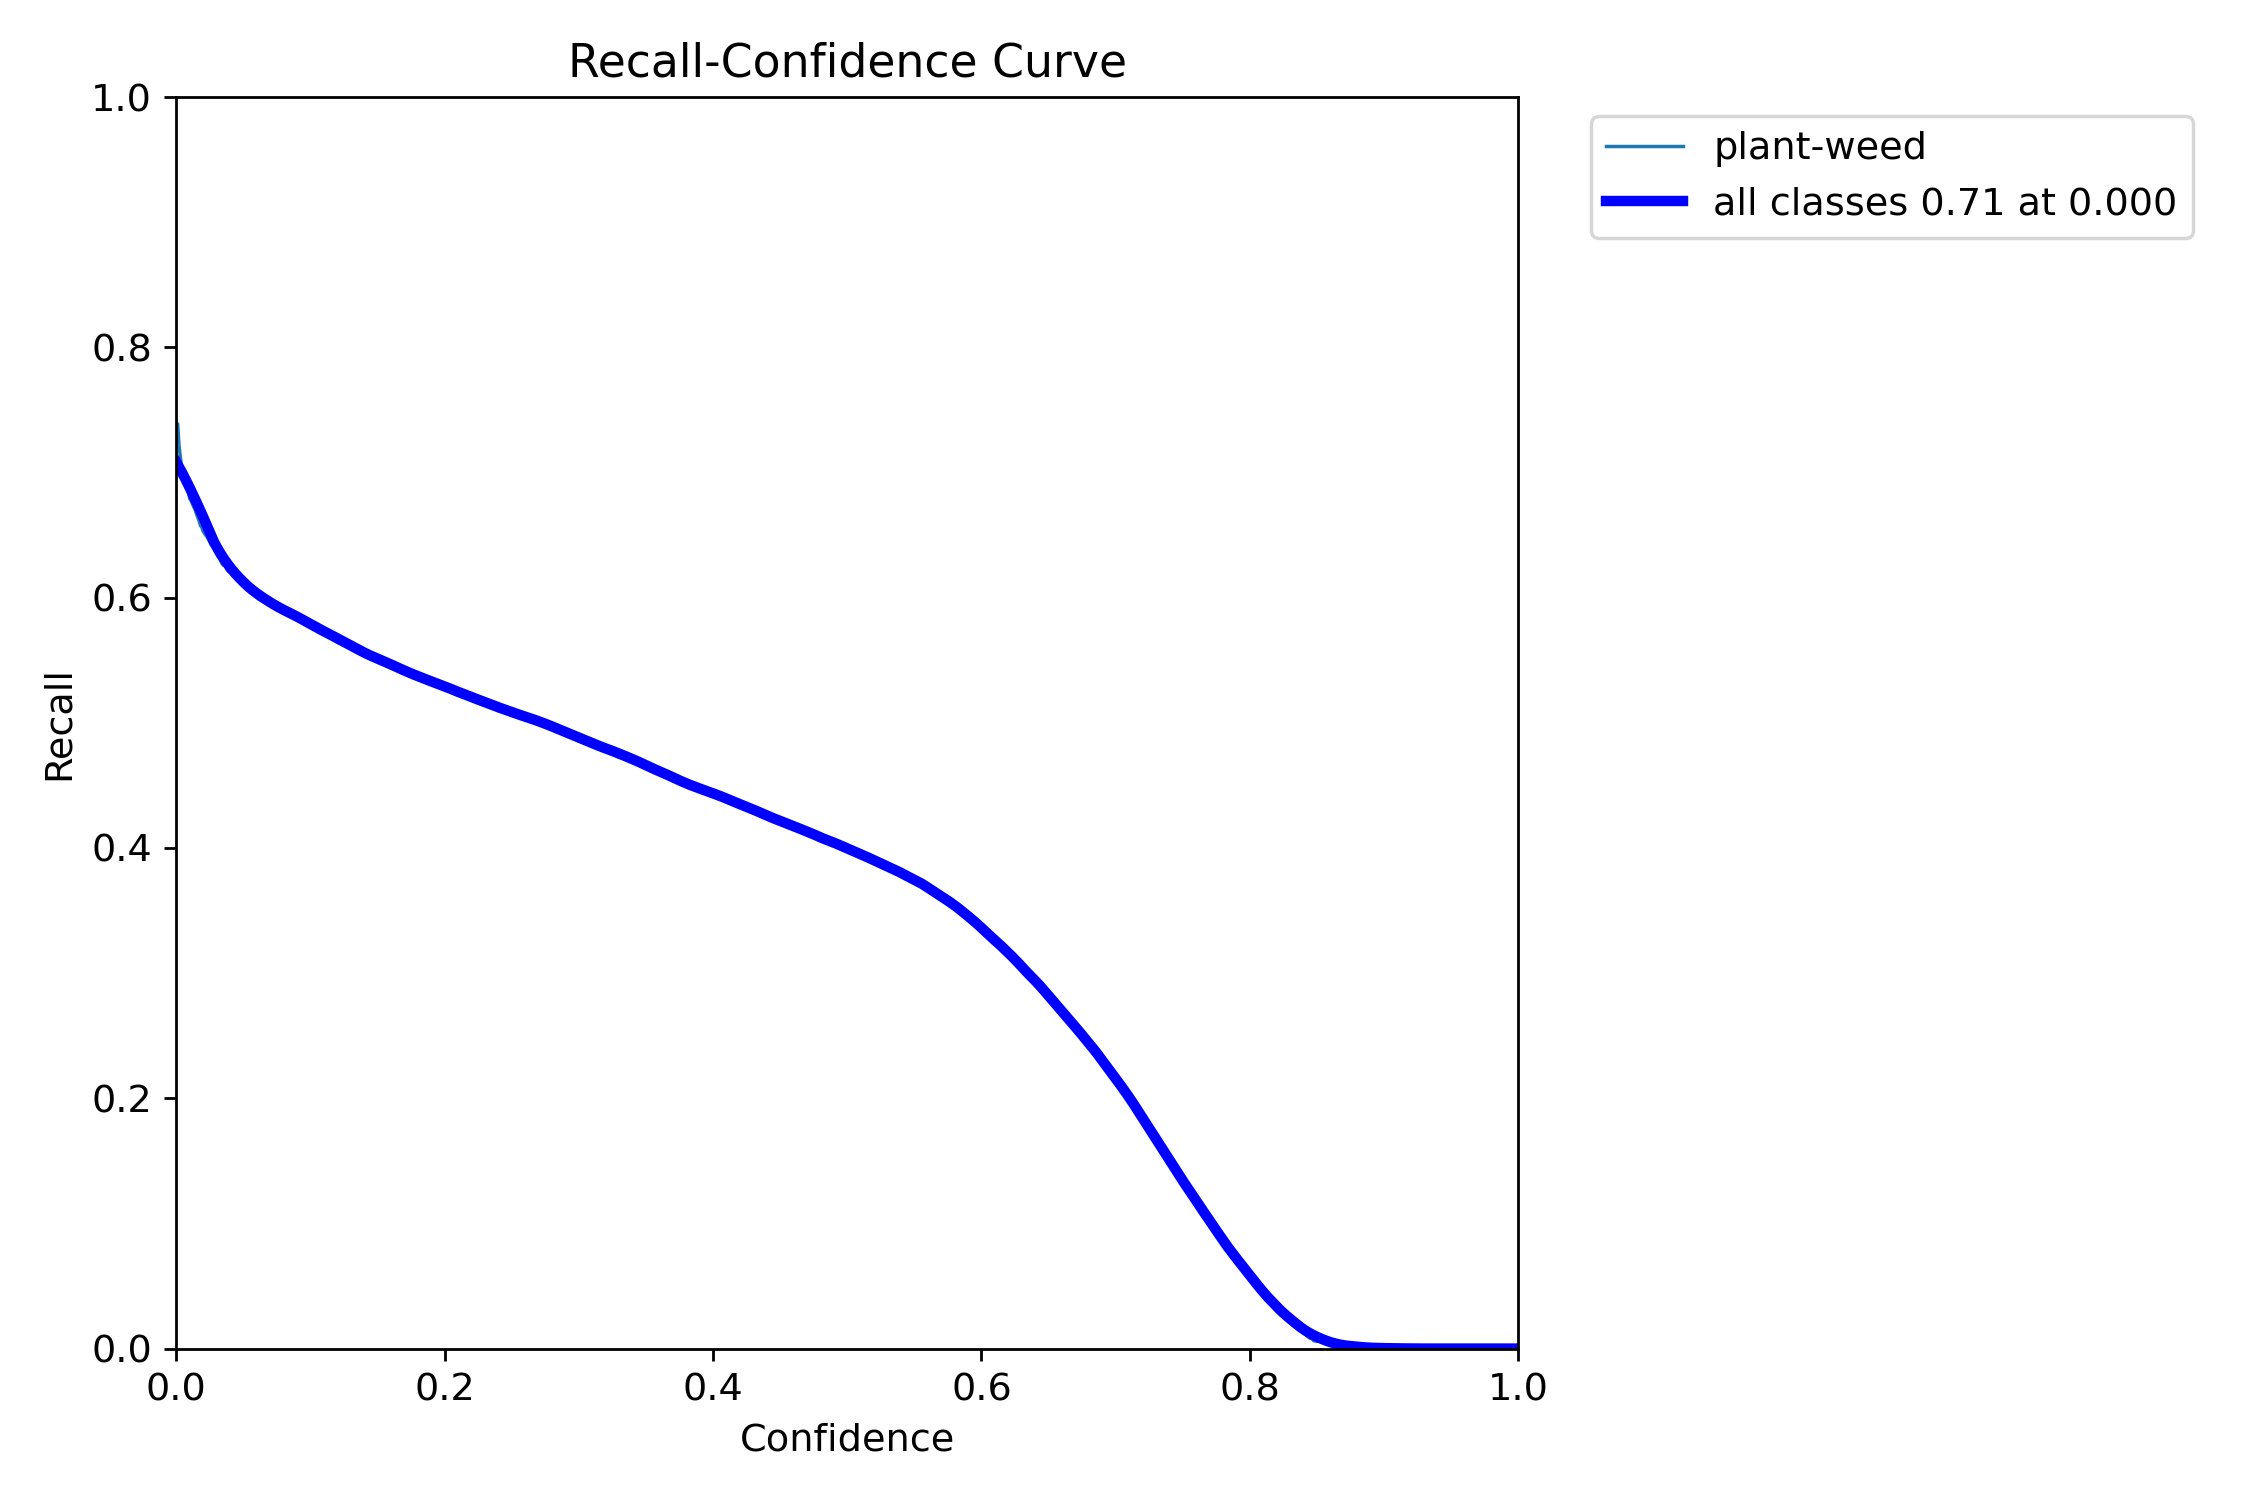

In [85]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

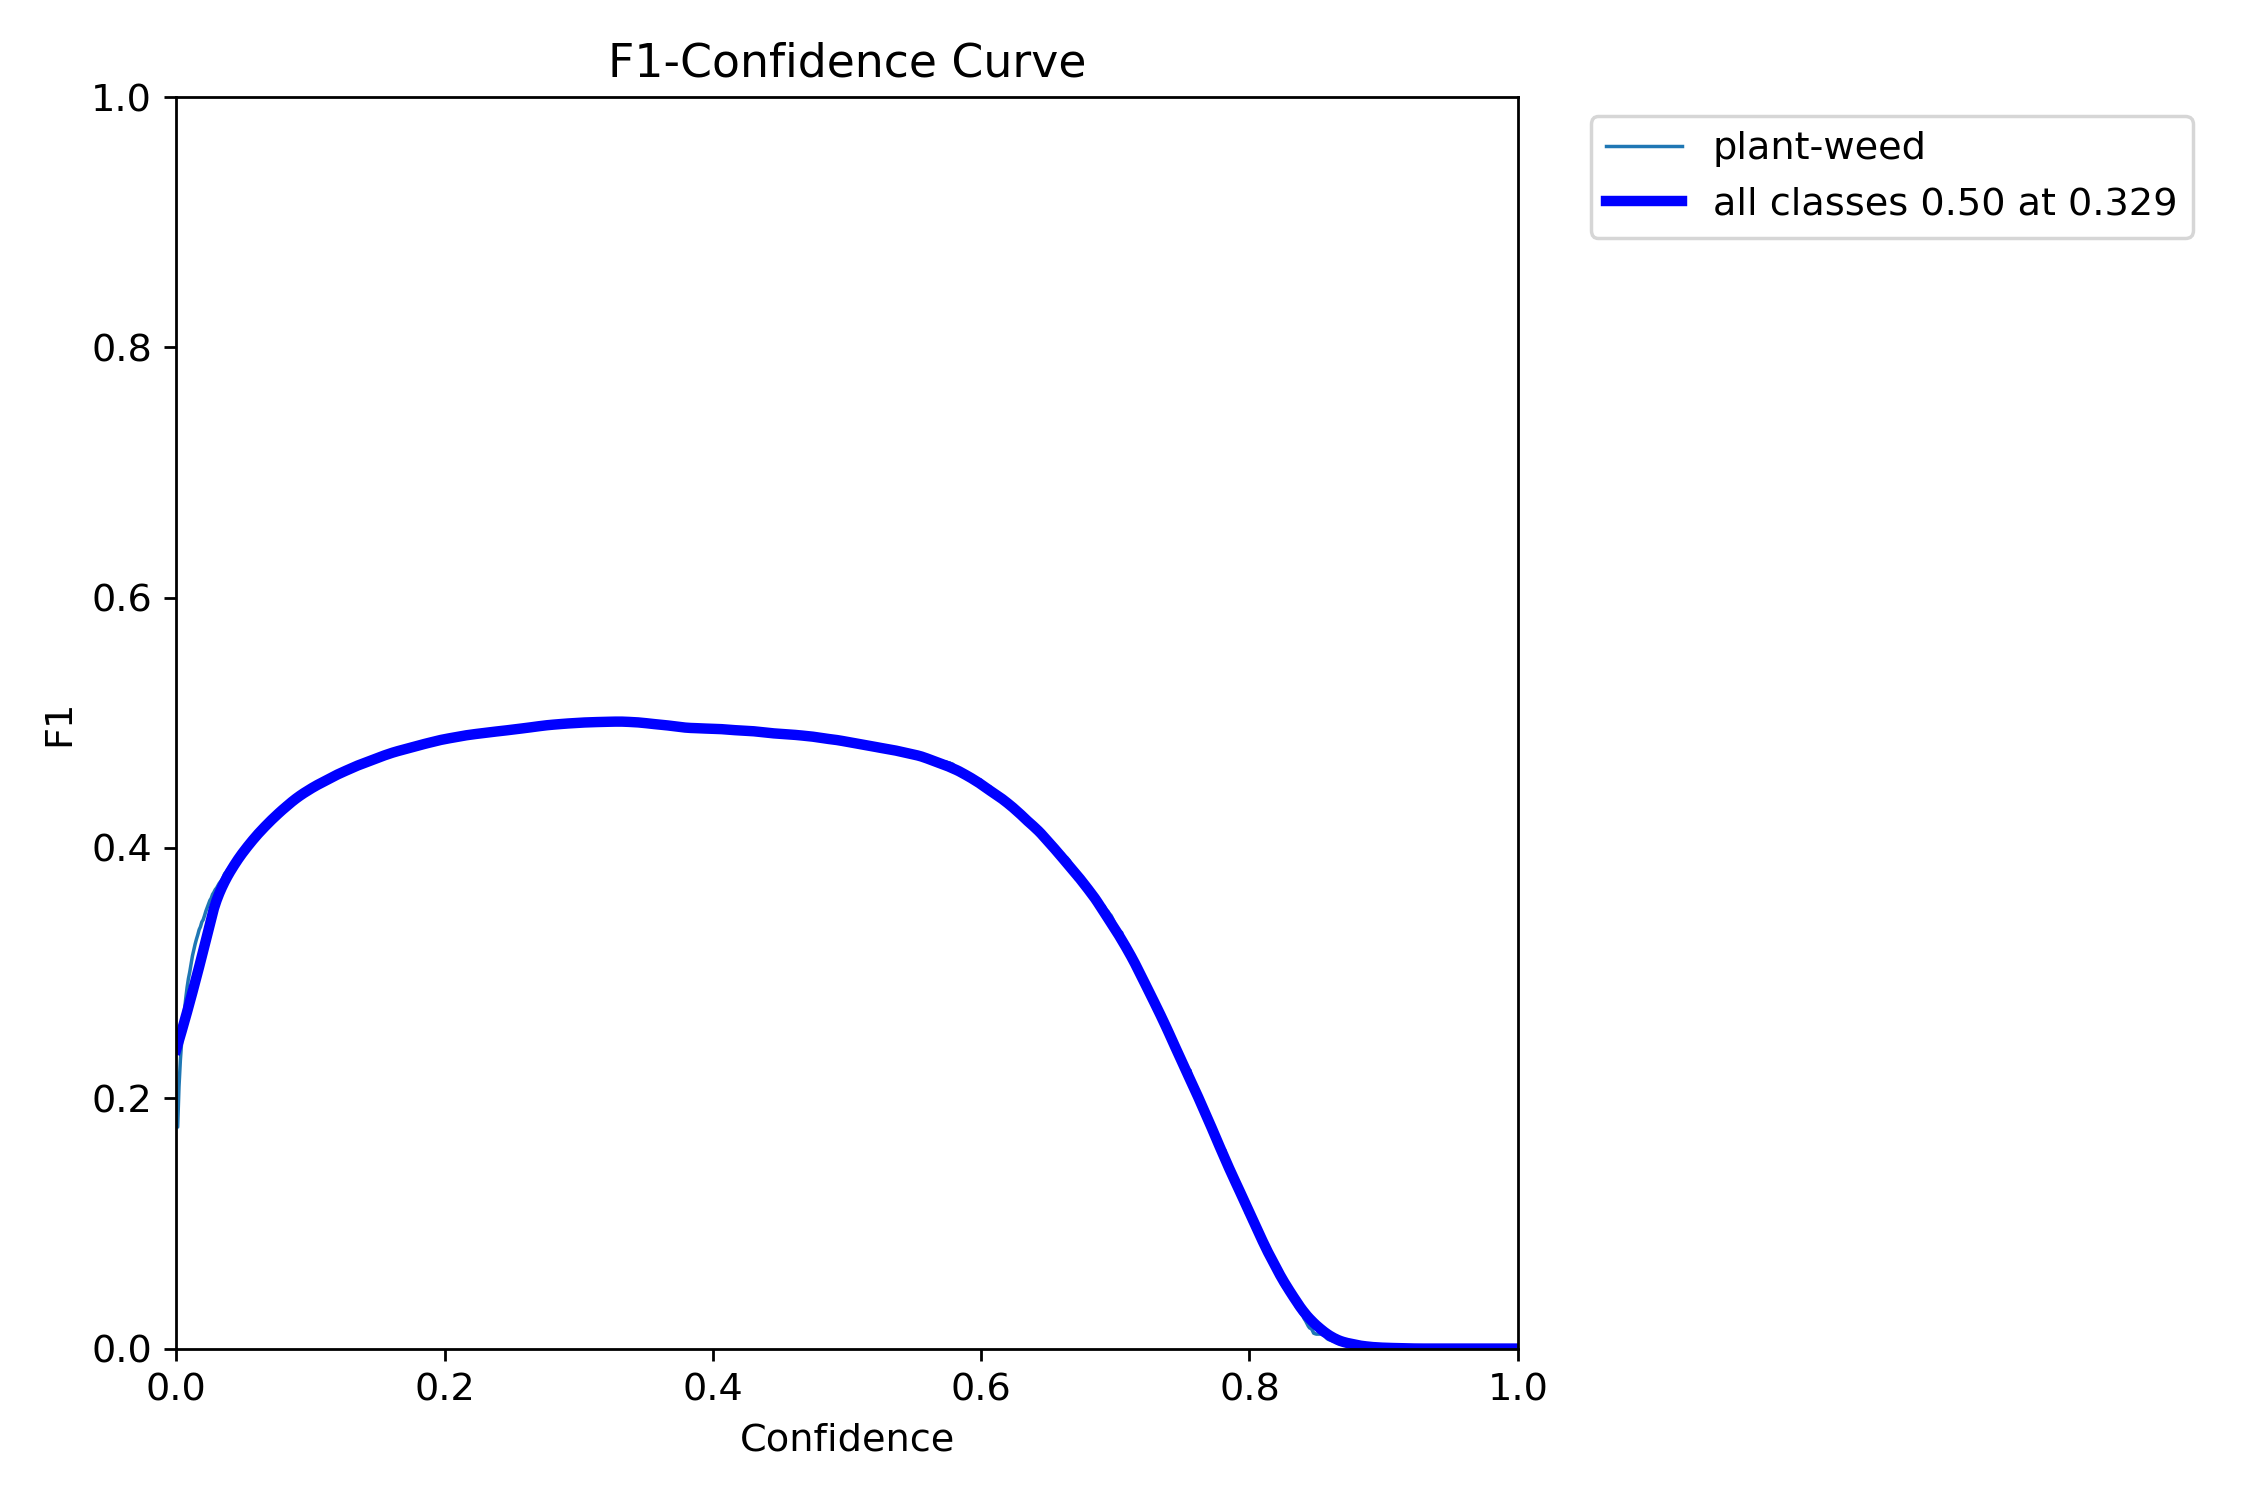

In [86]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [87]:
best_models.index = [f"{i}º TRAIN" for i in range(1, len(best_models)+1)]

In [88]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
2º TRAIN,1,15.0336,3.22651,4.68570,2.34480,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000120,0.000120,0.000120,208.361667
3º TRAIN,1252,14410.3000,0.58034,0.34377,0.83817,0.53887,0.45114,0.43299,0.14432,2.70694,1.49658,1.94813,0.000022,0.000022,0.000022,240.171667
1º TRAIN,1191,10805.8000,0.61439,0.37418,0.89136,0.56591,0.46824,0.44883,0.14883,2.67244,1.39438,1.98676,0.000020,0.000020,0.000020,319.898167
4º TRAIN,1445,14409.1000,0.87407,0.51323,0.90462,0.52267,0.47696,0.45023,0.14495,2.58570,1.36671,1.73956,0.000021,0.000021,0.000021,240.151667
5º TRAIN,361,2792.5000,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


In [94]:
best_models

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1º TRAIN,1191,10805.8000,0.61439,0.37418,0.89136,0.56591,0.46824,0.44883,0.14883,2.67244,1.39438,1.98676,0.000020,0.000020,0.000020,319.898167
2º TRAIN,1,15.0336,3.22651,4.68570,2.34480,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000120,0.000120,0.000120,208.361667
3º TRAIN,1252,14410.3000,0.58034,0.34377,0.83817,0.53887,0.45114,0.43299,0.14432,2.70694,1.49658,1.94813,0.000022,0.000022,0.000022,240.171667
4º TRAIN,1445,14409.1000,0.87407,0.51323,0.90462,0.52267,0.47696,0.45023,0.14495,2.58570,1.36671,1.73956,0.000021,0.000021,0.000021,240.151667
5º TRAIN,361,2792.5000,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


## History Graphs

In [100]:
# Define function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(15, 5))
    plt.plot(df1["epoch"], df1[metric], label="Training 1", linestyle="--", marker="o", markersize=4) if len(best_models) >= 1 else None
    plt.plot(df2["epoch"], df2[metric], label="Training 2", linestyle="--", marker="s", markersize=4) if len(best_models) >= 2 else None
    plt.plot(df3["epoch"], df3[metric], label="Training 3", linestyle="--", marker="d", markersize=4) if len(best_models) >= 3 else None
    plt.plot(df4["epoch"], df4[metric], label="Training 4", linestyle="--", marker="^", markersize=4) if len(best_models) >= 4 else None
    plt.plot(df5["epoch"], df5[metric], label="Training 5", linestyle="--", marker="v", markersize=4) if len(best_models) >= 5 else None
    plt.plot(df6["epoch"], df6[metric], label="Training 6", linestyle="--", marker="p", markersize=4) if len(best_models) >= 6 else None
    print("La cantidad de modelos entrenados supera la configuración del gráfico, por favor ajustar la función 'plot_metric()'") if len(best_models) >= 7 else None
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

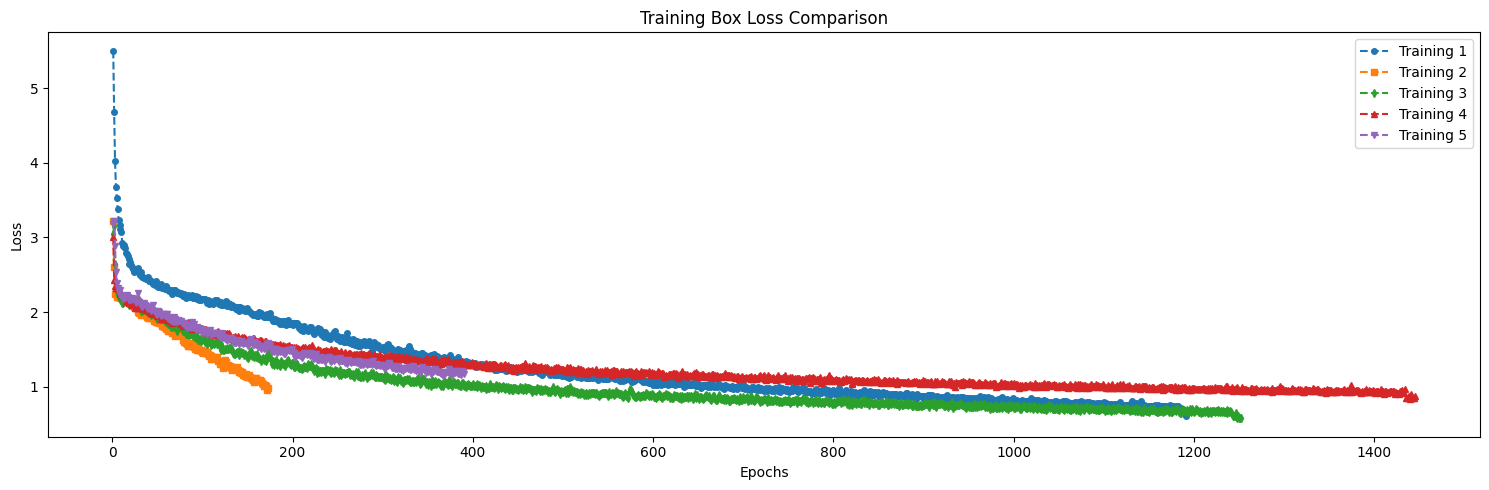

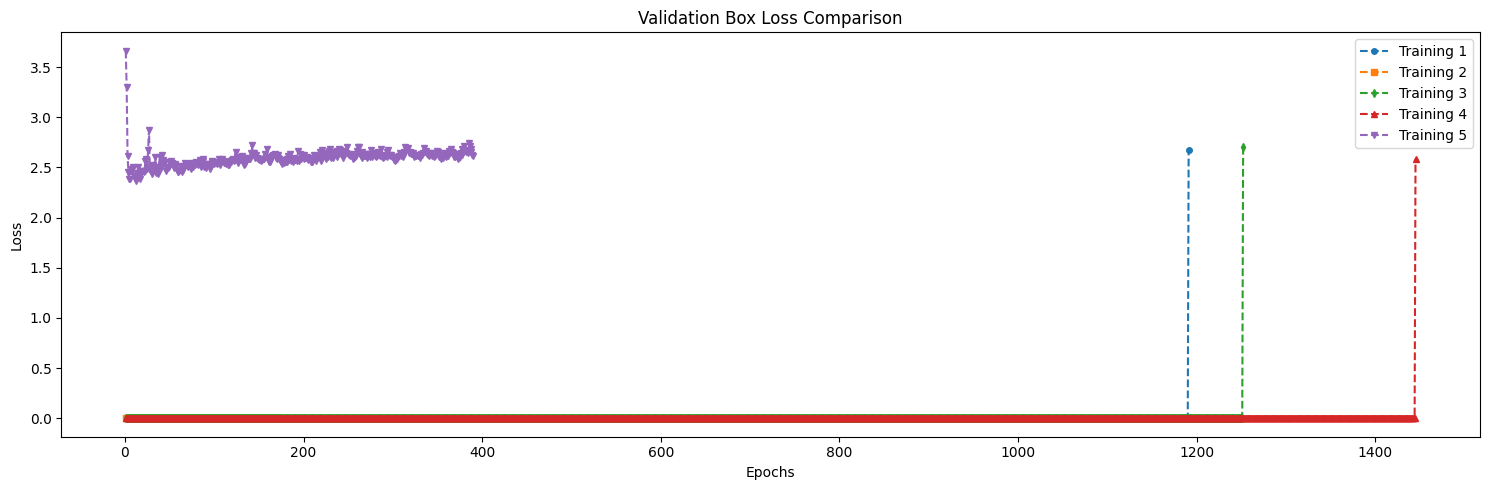

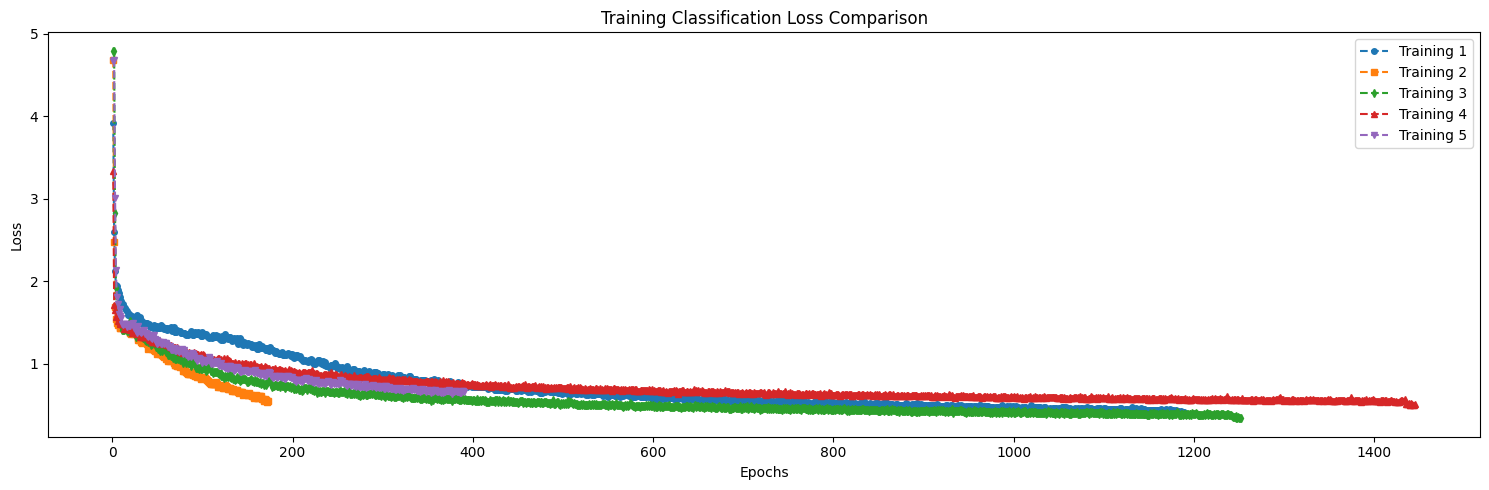

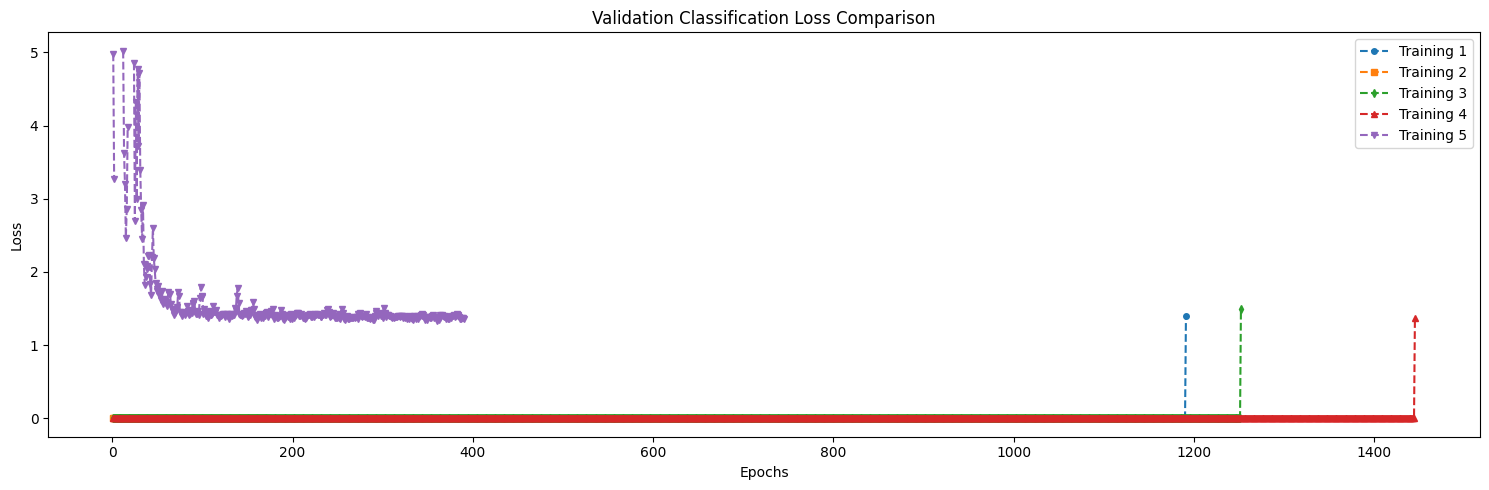

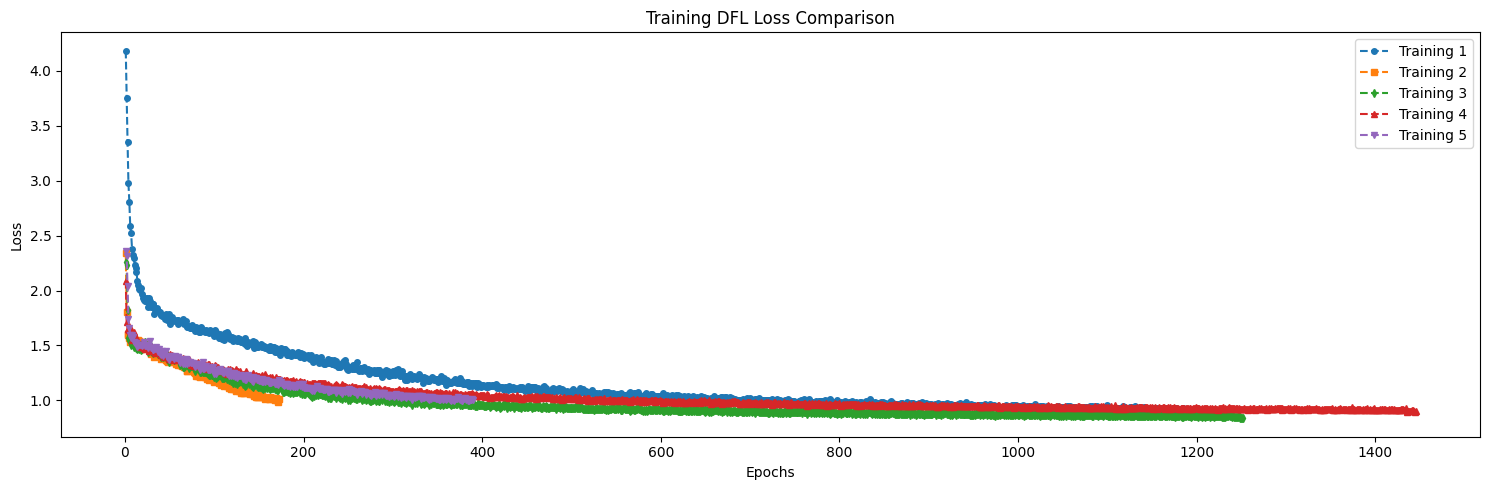

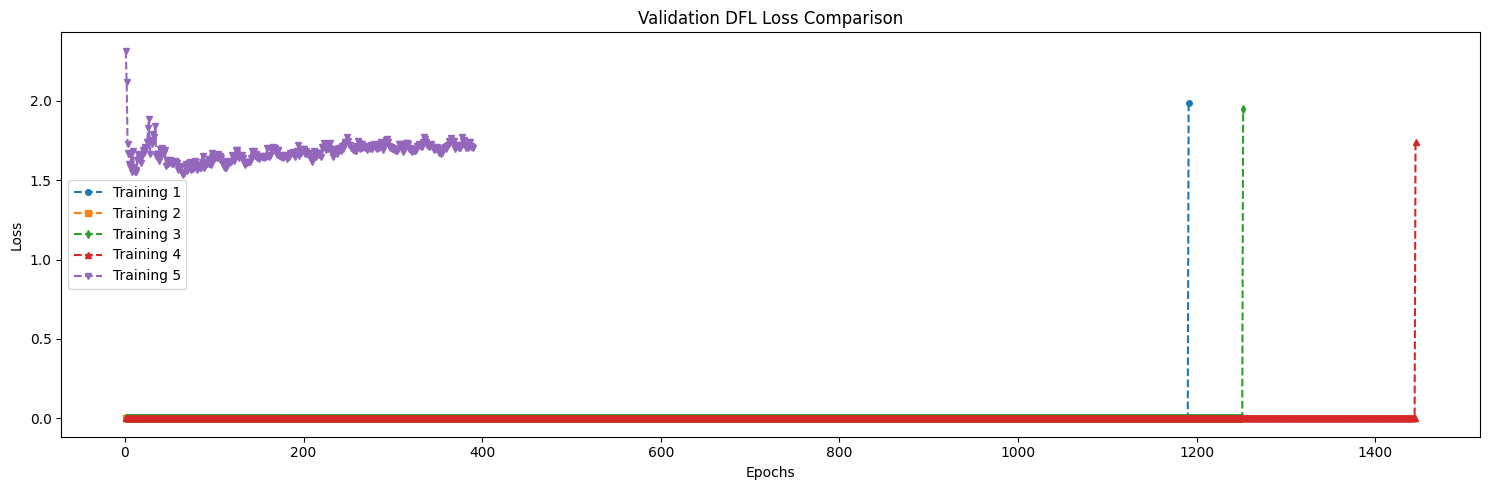

In [96]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

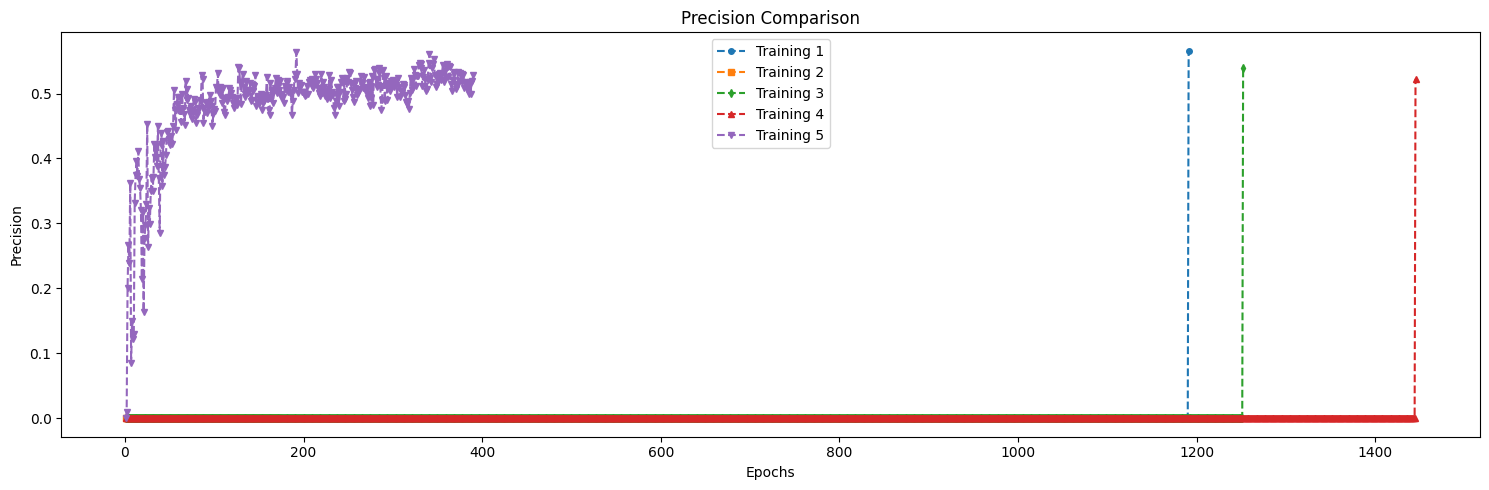

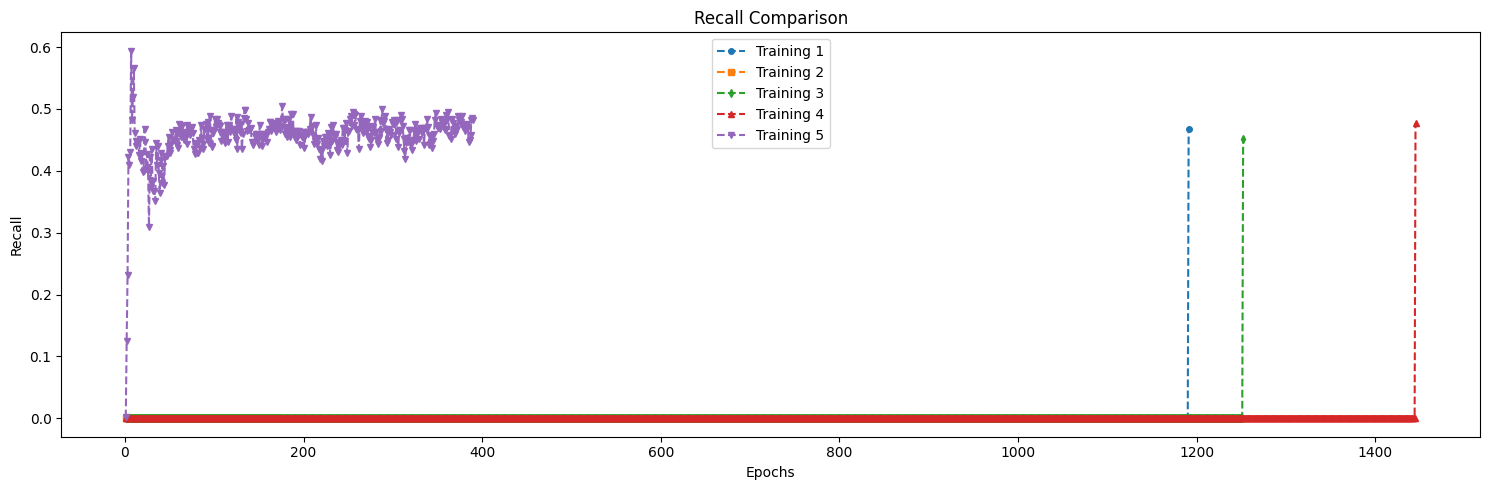

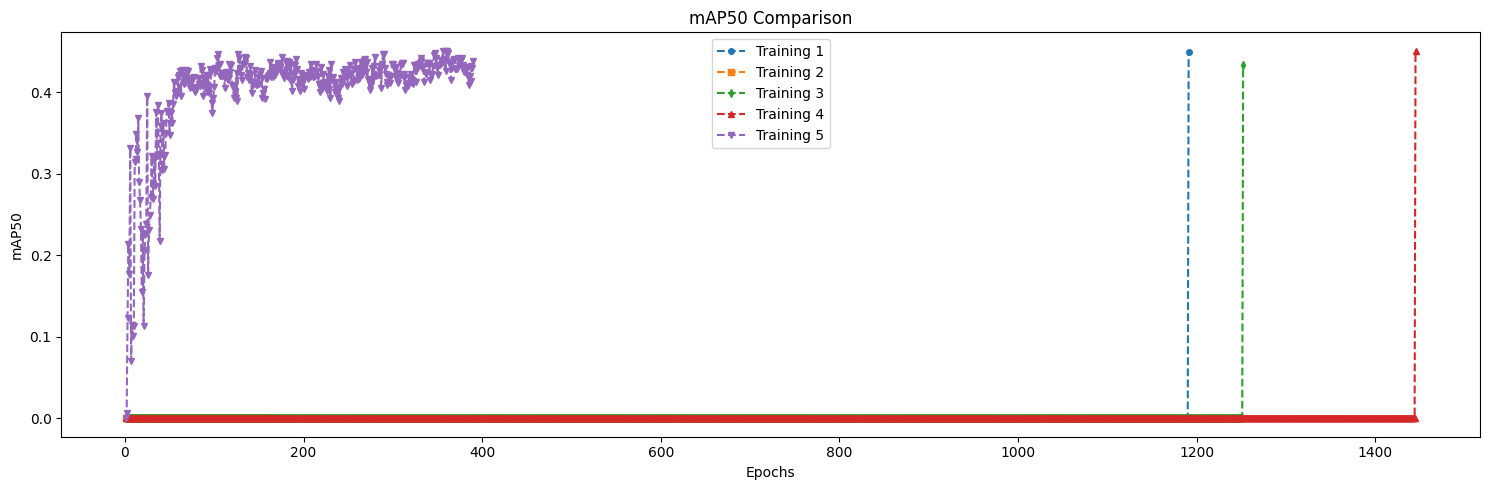

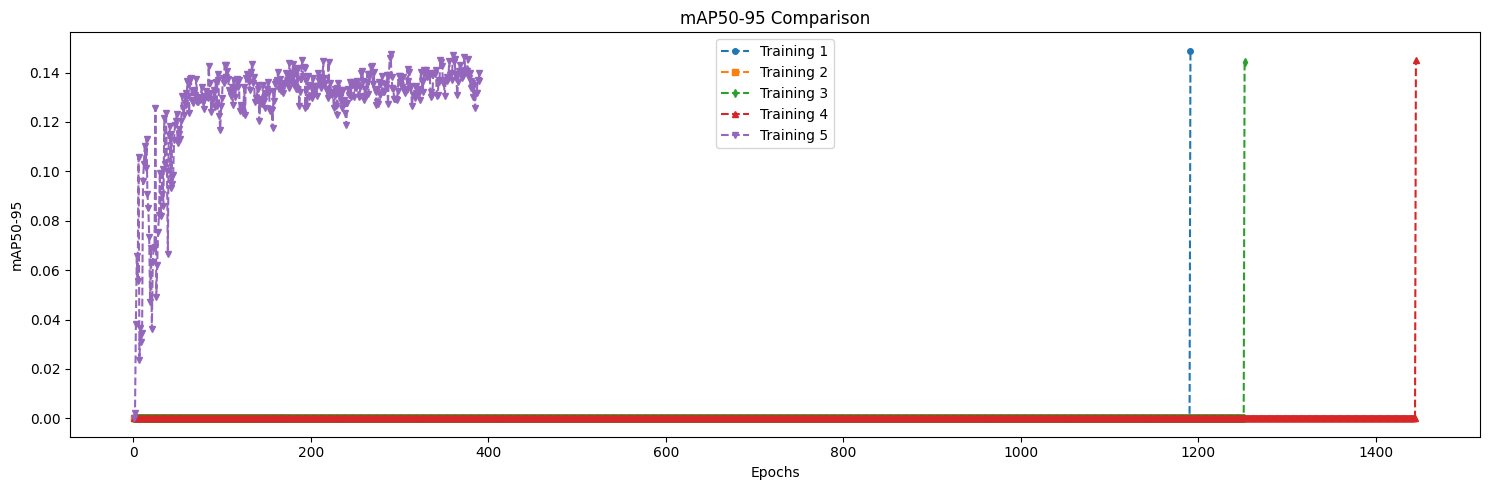

In [97]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

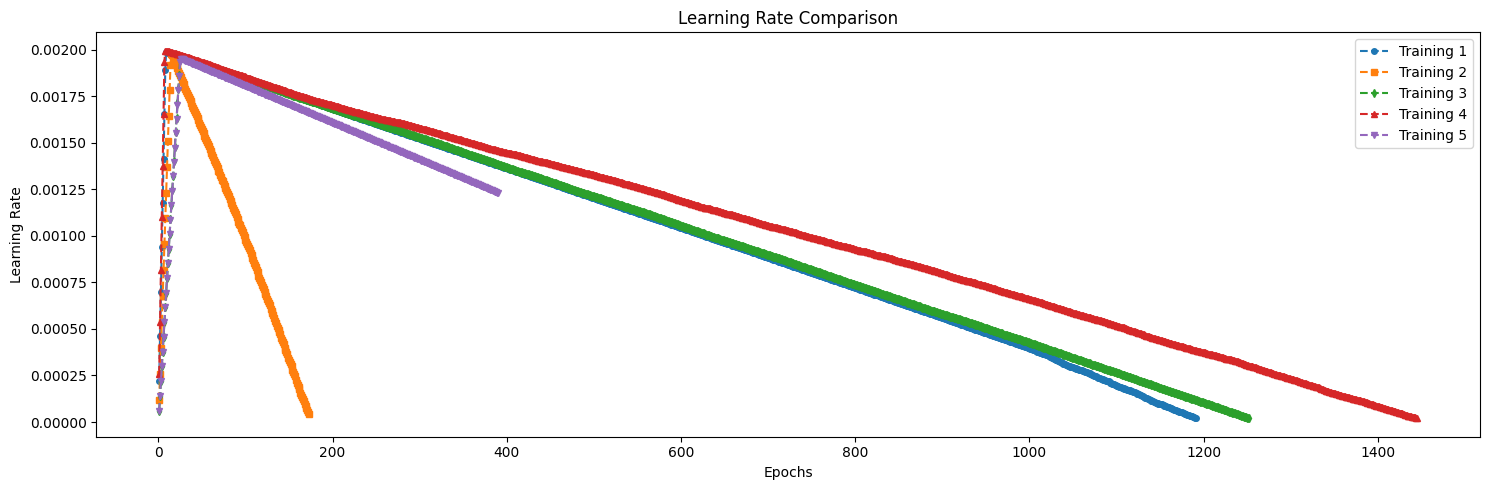

In [98]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Comparative Graphs

In [ ]:
#SETUP:
log_scale = False # Apply log scale to the y-axis

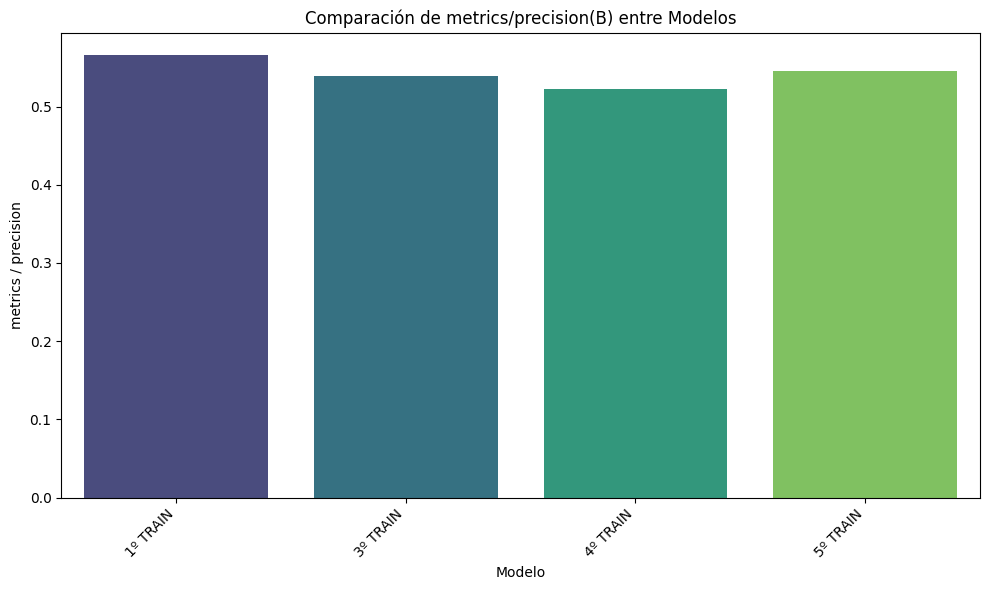

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/precision(B)' (tiene valores NaN o 0).




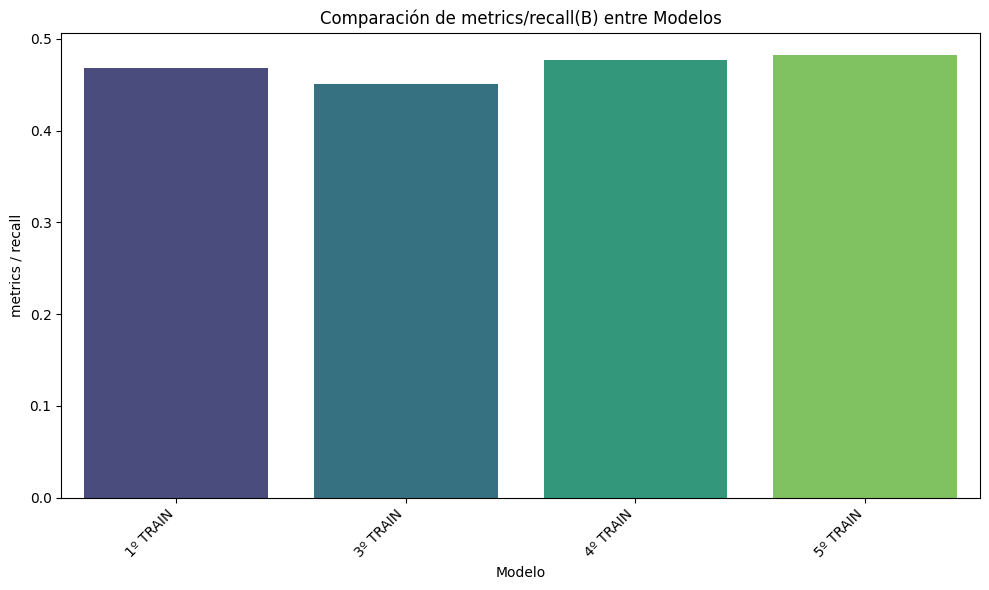

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/recall(B)' (tiene valores NaN o 0).




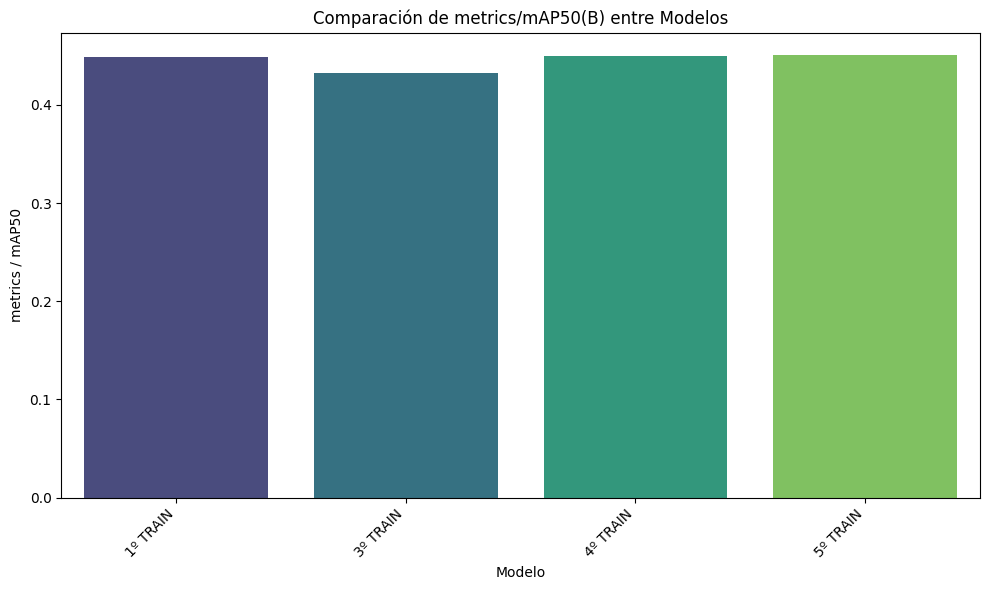

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/mAP50(B)' (tiene valores NaN o 0).




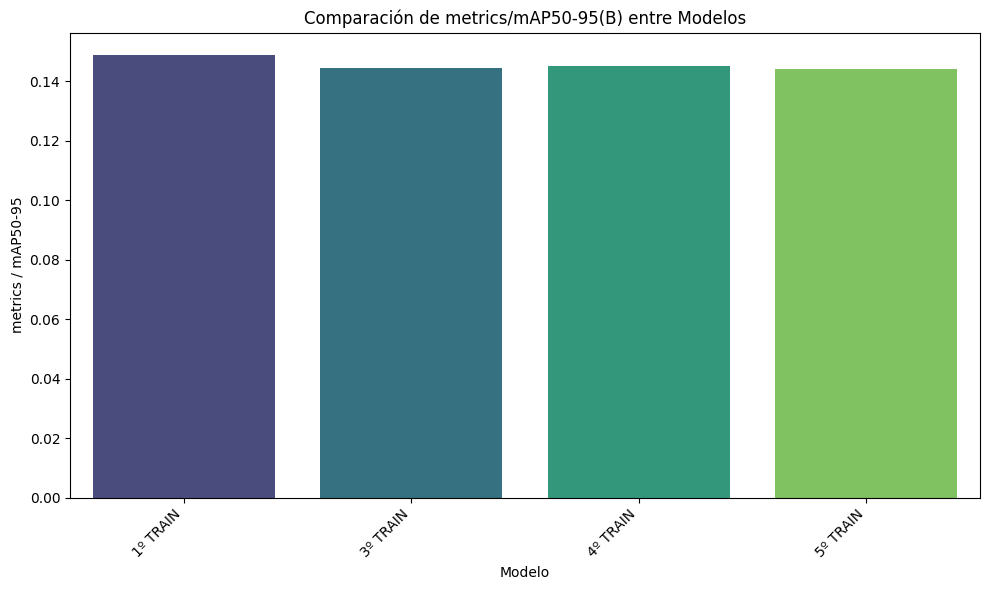

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/mAP50-95(B)' (tiene valores NaN o 0).




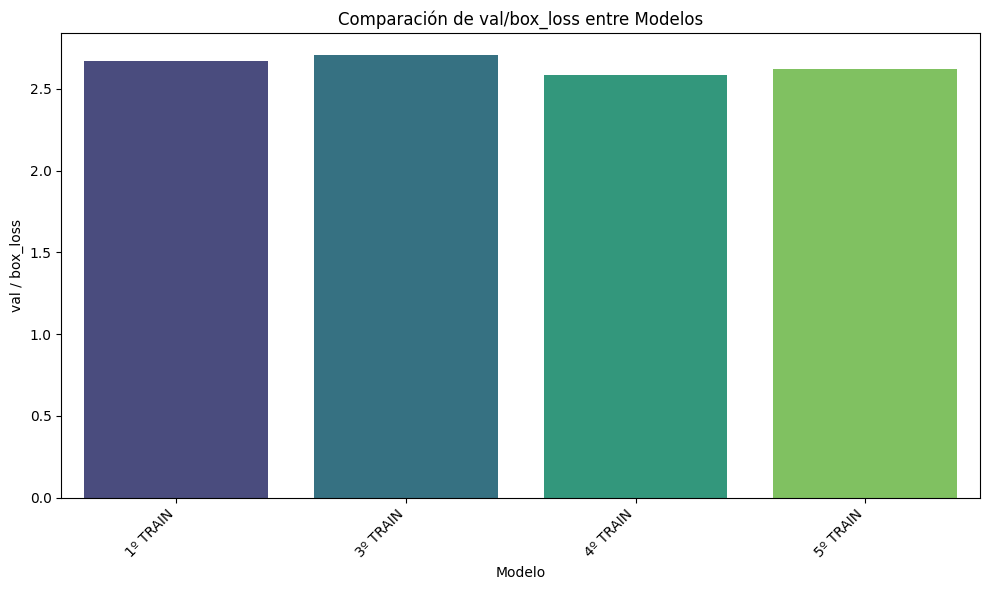

- El modelo 2º TRAIN fue omitido para la métrica 'val/box_loss' (tiene valores NaN o 0).




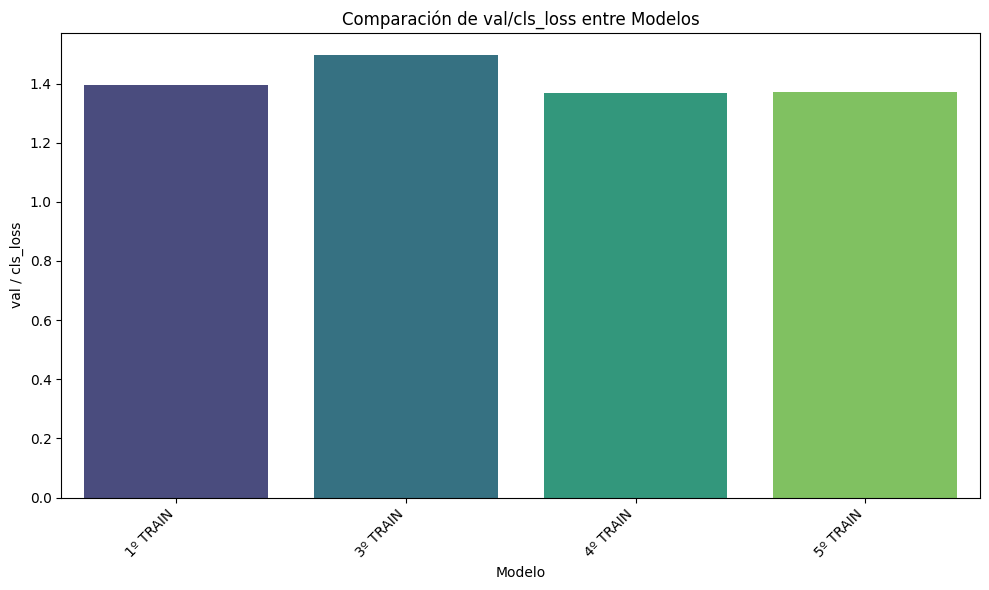

- El modelo 2º TRAIN fue omitido para la métrica 'val/cls_loss' (tiene valores NaN o 0).




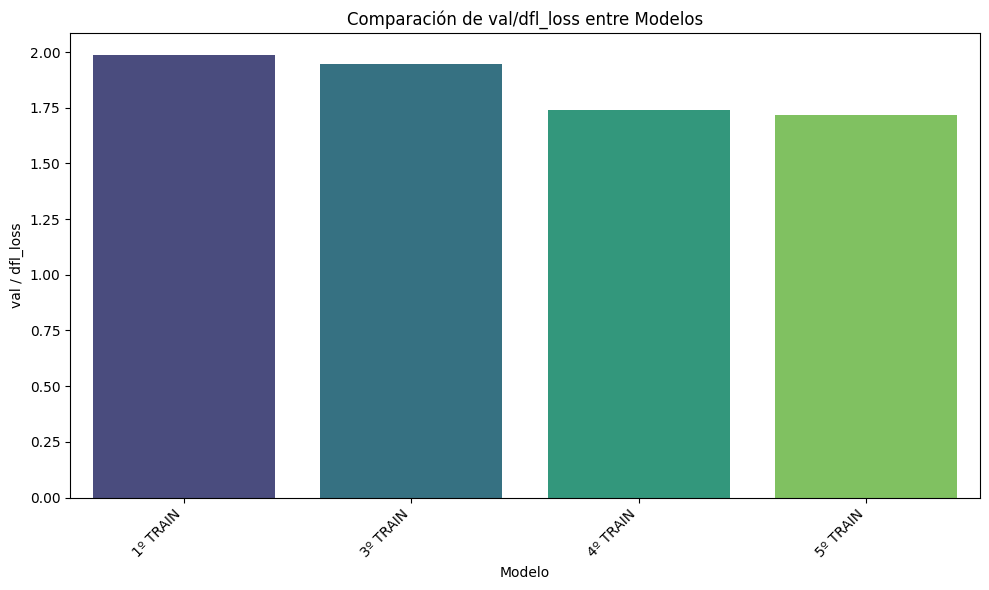

- El modelo 2º TRAIN fue omitido para la métrica 'val/dfl_loss' (tiene valores NaN o 0).




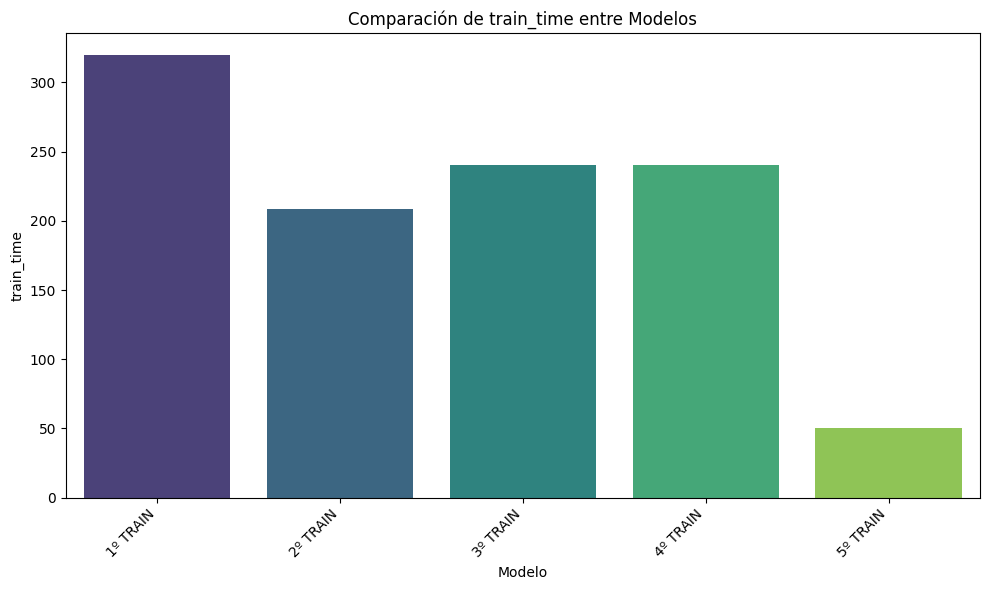

In [161]:
import seaborn as sns

metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
# print(f"Generando gráficos para las métricas: {metrics_to_plot}")

for metric in metrics_to_plot:

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.barplot(x='Model', y=metric, data=df_plot, hue='Model', palette='viridis', dodge=False, legend=False)

    plt.yscale('log') if log_scale else None 
    plt.title(f'Comparación de {metric} entre Modelos')
    plt.xlabel('Modelo')
    plt.ylabel(metric.replace('(B)', '').replace('/', ' / '))  # Clean up the y-axis label
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if they are long
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")

## Lollipop Graphs

In [146]:
#SETUP:
horizontal = False # Set to True for horizontal lollipop chart
log_scale = False # Apply log scale to the y-axis
sort = True # Sort values for better visual flow
sort_type = 'ascending' # Options: 'ascending', 'descending'

Orenamiento: ascending


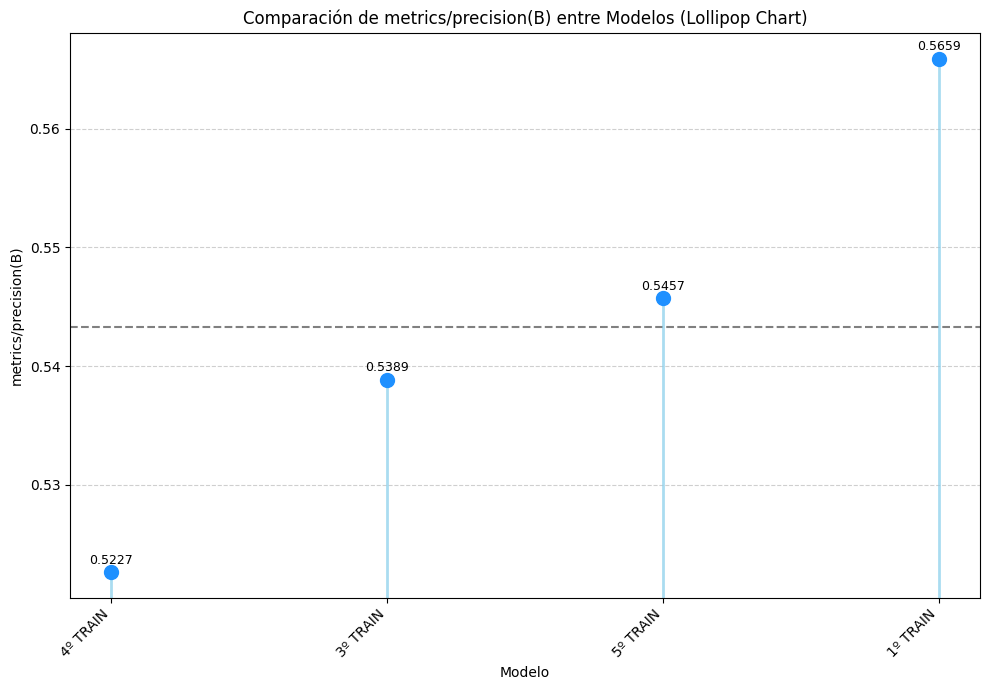

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/precision(B)' (tiene valores NaN o 0).




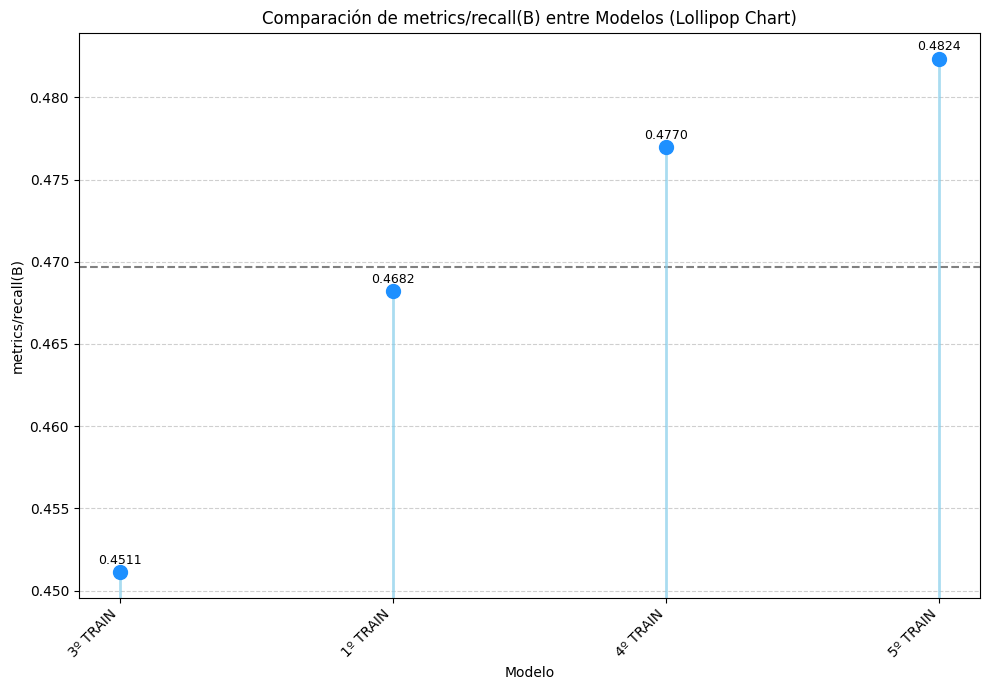

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/recall(B)' (tiene valores NaN o 0).




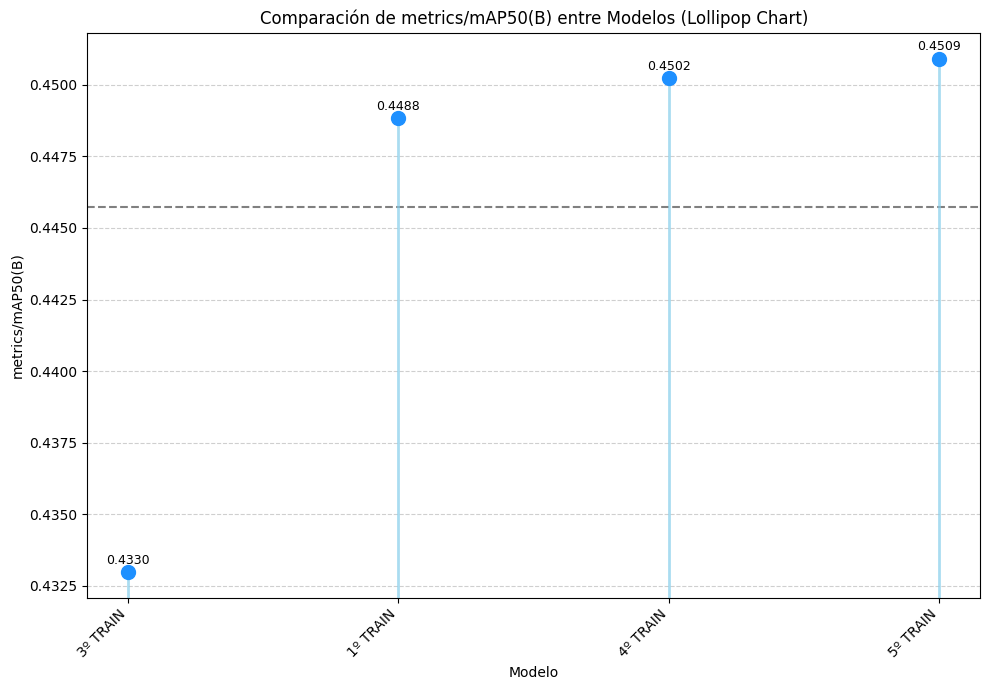

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/mAP50(B)' (tiene valores NaN o 0).




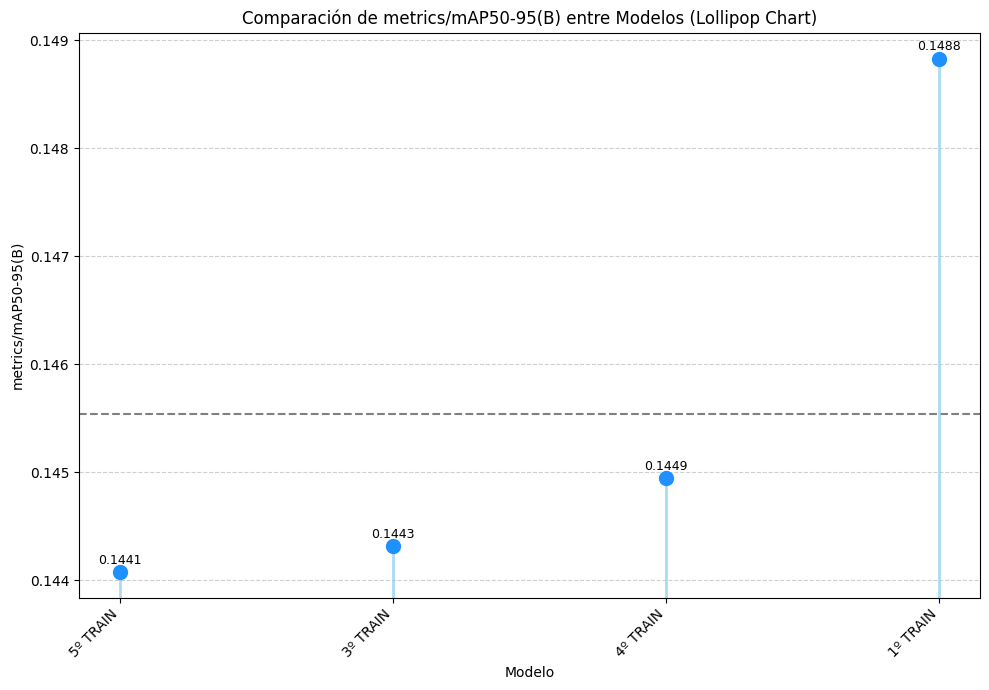

- El modelo 2º TRAIN fue omitido para la métrica 'metrics/mAP50-95(B)' (tiene valores NaN o 0).




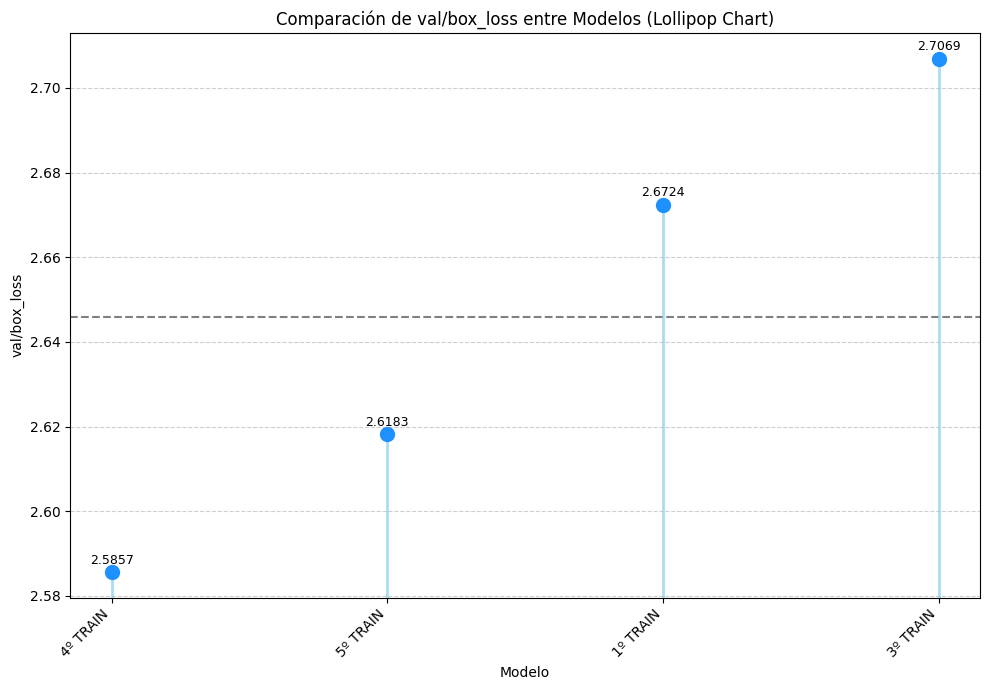

- El modelo 2º TRAIN fue omitido para la métrica 'val/box_loss' (tiene valores NaN o 0).




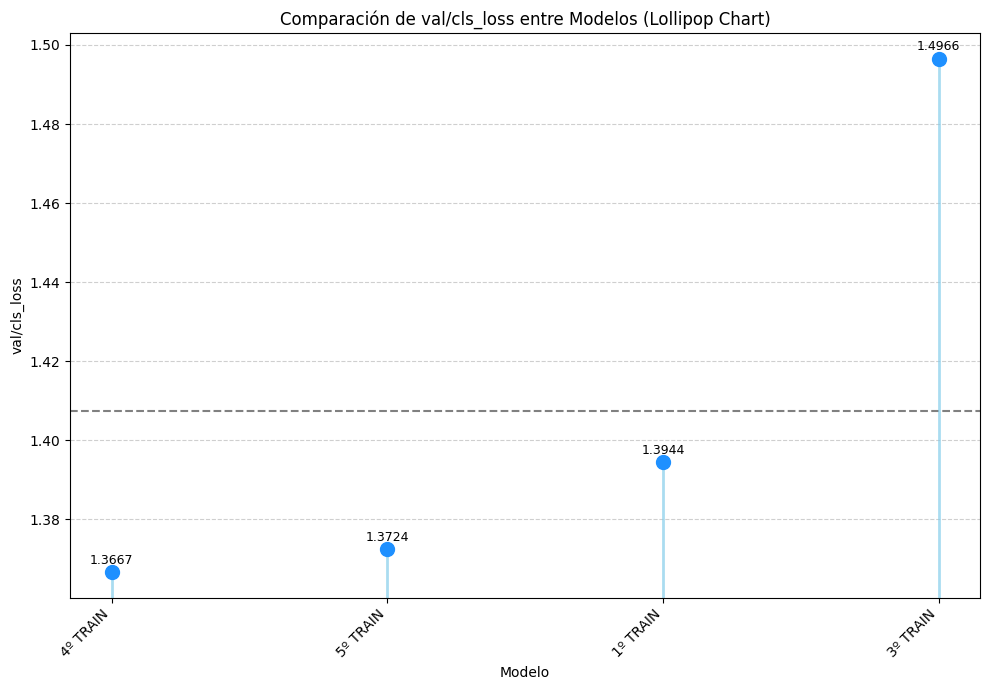

- El modelo 2º TRAIN fue omitido para la métrica 'val/cls_loss' (tiene valores NaN o 0).




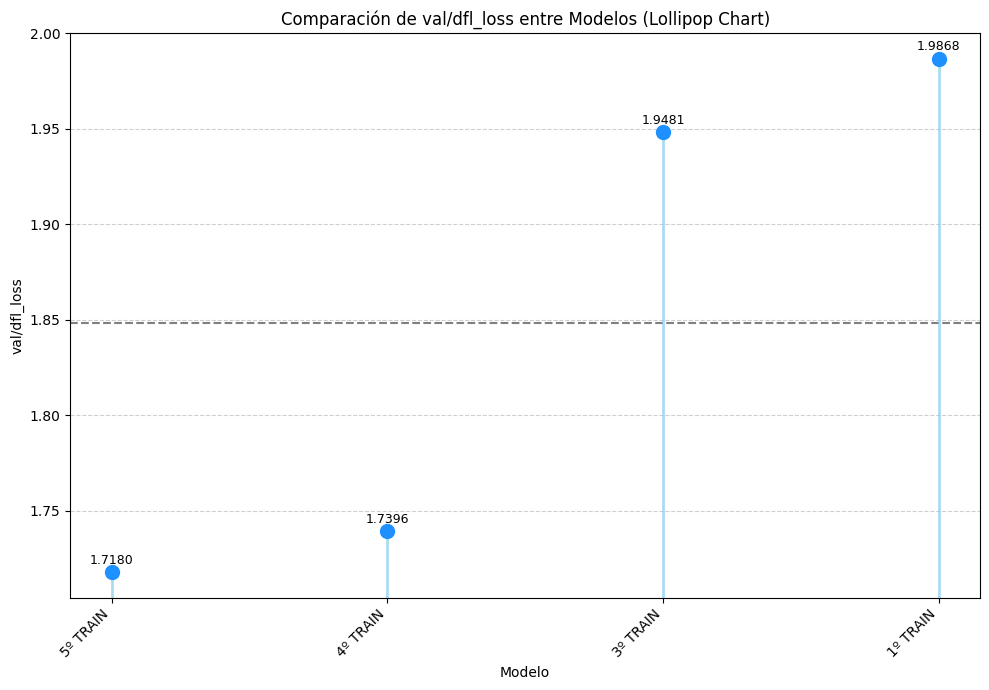

- El modelo 2º TRAIN fue omitido para la métrica 'val/dfl_loss' (tiene valores NaN o 0).




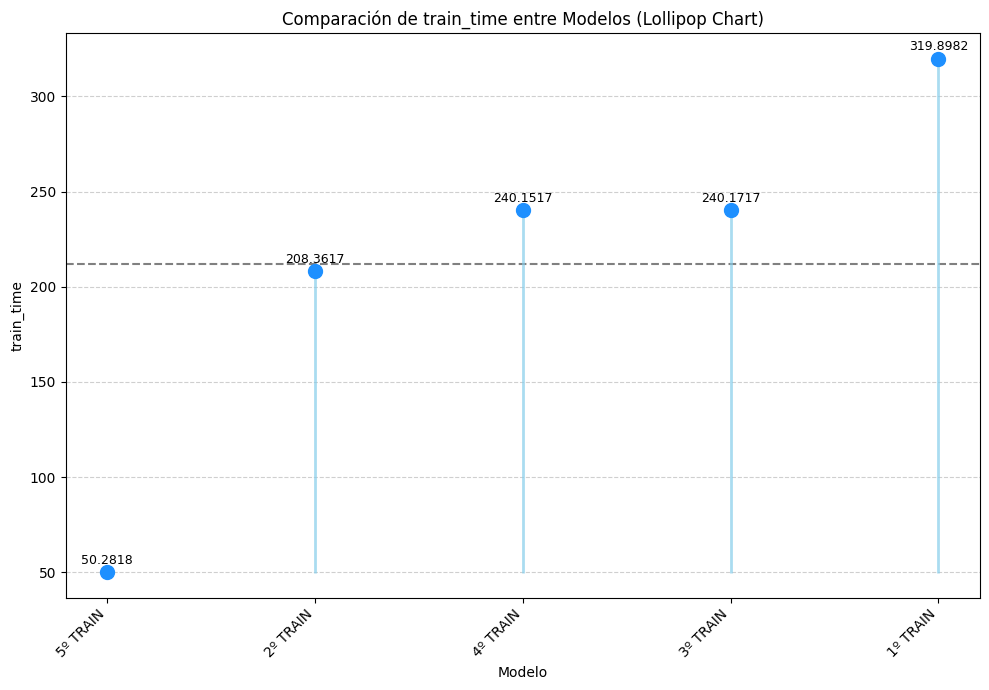

In [160]:
metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
#print(f"Generando gráficos para las métricas: {metrics_to_plot}")
print(f"Orenamiento: {sort_type}") if sort else None

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for  metric in metrics_to_plot:

    # Preparamos el DataFrame para seaborn (opcional pero a veces útil)
    # Usaremos el índice directamente en este caso.
    df_plot = best_models.dropna(subset=[metric]).copy()
    df_plot['Model'] = df_plot.index

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    # Calculate the average value
    average_value = df_plot[metric].mean()

    # Sort values for potentially better visual flow (optional)
    if sort:
        match sort_type:
            case 'ascending':
                df_plot = df_plot.sort_values(by=metric, ascending=True)
            case 'descending':
                df_plot = df_plot.sort_values(by=metric, ascending=False)
            case _:
                print(f"Invalid sort type '{sort_type}'. No sorting applied.")

    plt.figure(figsize=(10, 7)) # Slightly taller figure might be nice

    # Define the y-values (the metric) and x-values (numerical index for models)
    values = df_plot[metric]
    axis = np.arange(len(df_plot)) # 0, 1, 2, ...

    # Determine the baseline for the stems (lines)
    # Start from slightly below the minimum value to emphasize differences
    plot_min_val = values.min()
    plot_max_val = values.max()
    stem_baseline = plot_min_val * 0.99 # Start stems just below the minimum point
    margin = (plot_max_val - plot_min_val) * 0.05 # Adjust y-axis limits for zoom, adding a margin

    if not horizontal:
        # --- Create the Lollipop Plot ---
        plt.yscale('log') if log_scale else None # Apply log scale to y-axis for vertical plot
        plt.ylim(max(0, plot_min_val - margin), plot_max_val + margin) # Ensure y_min not negative if data positive
    
        # Add average line
        plt.axhline(y=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create the 'stems' (vertical lines)
        plt.vlines(x=axis, ymin=stem_baseline, ymax=values, color='skyblue', alpha=0.7, linewidth=2)

        # Create the 'lollipops' (the dots at the top)
        plt.scatter(x=axis, y=values, color='dodgerblue', s=100, alpha=1, zorder=3) # zorder=3 makes dots appear on top

        # Add value labels next to the dots
        for i, txt in enumerate(values):
            plt.text(axis[i], values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly above dot
                    f'{txt:.4f}', # Format the number
                    ha='center', # Horizontal alignment
                    va='bottom', # Vertical alignment
                    fontsize=9)

        # Customize the plot
        plt.xlabel('Modelo')
        plt.ylabel(metric)

        # Set the x-axis ticks to be the model names
        plt.xticks(axis, df_plot['Model'], rotation=45, ha='right')

        # Add a light grid for easier comparison
        plt.grid(axis='y', linestyle='--', alpha=0.6)


    if horizontal:
        # --- Horizontal Lollipop (Alternative) ---
        plt.xscale('log') if log_scale else None # Apply log scale to x-axis for horizontal plot
        plt.xlim(max(0, plot_min_val - margin), plot_max_val + margin)

        # Add average line
        plt.axvline(x=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create horizontal lines (stems)
        plt.hlines(y=axis, xmin=stem_baseline, xmax=values, color='lightcoral', alpha=0.7, linewidth=2)

        # Create the dots
        plt.scatter(x=values, y=axis, color='firebrick', s=100, alpha=1, zorder=3)

        # Add value labels next to dots
        for i, txt in enumerate(values):
            plt.text(values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly right of dot
                    axis[i],
                    f'{txt:.4f}',
                    ha='left',
                    va='center',
                    fontsize=9)

        # Customize
        plt.xlabel(metric)
        plt.ylabel('Modelo')

        # Set the y-axis ticks to be the model names
        plt.yticks(axis, df_plot['Model']) # Set model names on y-axis ticks
        # Add a light grid for easier comparison
        plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on x-axis now
        

    plt.title(f'Comparación de {metric} entre Modelos (Lollipop Chart)')
    plt.tight_layout()
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")
    

## Resumen de los Experimentos

| Experiment | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | Train Time (min) | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | mAP@0.5 |
|------------|------|------|--------------|---------|------|------|----------------|---------------|---------------|---------------|---------------|--------|
| **1º TRAIN (25)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 320 | **0** | 3283 | **39,66%** | 26,62% | 33,72% | **0.449** |
| **2º TRAIN (26)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 208 | **0** | 3458 | **42,02%** | 30,34% | 27,65% | **0.495** |
| **3º TRAIN (27)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 240 | **0** | 3276 | **37,70%** | 26,47% | 35,84% | **0.433** |
| **4º TRAIN (28)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | 240 | **0** | 3371 | **37,35%** | 28,54% | 34,12% | **0.450** |
| |
| **5º TRAIN (19)** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | *50* | **25,7** | 3593 | **38,24%** | 32,95% | 28,81% | **0.451** |

1. No pre-train
1. Full Fine-Tuning
1. Freezing Backbone *(8 layers)*
1. Freezing Backbone *(12 layers)*
1. Freezing Backbone *(10 layers)* **(Reference)** 

## Comparación de los Entrenamientos

### Análisis del Dataset
- **Cantidad de imágenes y etiquetas**:  
  -  

- **Distribución de Train/Valid**:  
  -  

- **Tamaño de imágenes (small vs mid)**:  
  -  

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
- **Precisión (Precision) y Recall**:  
  -  

- **mAP50**:  
  - 
  
- **Confusión entre clases (False Positives y False Negatives)**:  
  - 
  
### Conclusiones Generales
1. 

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- 

2. **Hiperparámetros**
-  

3. **Optimización del Modelo**
- 

4. **Evaluación y Métricas**
-  